In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import matplotlib.lines as mlines


plt.rcParams['legend.title_fontsize'] = 'large'

import altair as alt
from altair import datum


In [2]:
### a quick note about this repo: sometimes you will find references to an "FoI" which is the previous name of the 
### Infectivity Scalar α parameter we used in this paper. We changed the name to avoid confusing nomenclature but they are equivalent in this notebook

## main fig 5

In [21]:
## all the microsimulation results with uncertainty intervals are in seperate folders and files. This function combines all those results
## into a single dataframe. Of note, this specific code snippet was created with help of ChatGPT and 
## edited by Miguel Paredes. The rest of this notebook was written by Miguel. 

# Define the parent folder containing the subfolders
parent_folder = "../data/MonteCarloResults/"

# Initialize an empty list to store the processed DataFrames
dataframes = []

# Loop through each subfolder in the parent folder
for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    # Check if the current path is a folder and matches the pattern "SX" where X is a number
    if os.path.isdir(subfolder_path) and subfolder.startswith("new"):
        file_path = os.path.join(subfolder_path, "ToAware_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)
            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}",
                "UpperBound": f"UpperBound_{folder_name}",
                "LowerBound": f"LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
    
    if os.path.isdir(subfolder_path) and subfolder.startswith("new"):
        file_path = os.path.join(subfolder_path, "ToAwareCum_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Cum_Mean_{folder_name}",
                "UpperBound": f"Cum_UpperBound_{folder_name}",
                "LowerBound": f"Cum_LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)

# Merge all DataFrames on the "Week" column
merged_df = dataframes[0]
for df in dataframes[1:]:
    merged_df = pd.merge(merged_df, df, on="Week")
    
empirical_df = pd.read_csv("../data/microsimulation_results/scenarios_aware.csv")

merged_df = pd.merge(merged_df, empirical_df, left_on = "Week", right_on = "week" )
merged_df.head()

,Week,Mean_S12,LowerBound_S12,UpperBound_S12,Cum_Mean_S12,Cum_LowerBound_S12,Cum_UpperBound_S12,Mean_S15,LowerBound_S15,UpperBound_S15,...,To.Aware_S10,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19
0,0,0.0000,0.00,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,0
1,1,1.7553,1.45,2.05,1.7553,1.45,2.05,1.4440,1.10,1.80,...,2,1,2,2,2,2,2,2,2,2
2,2,0.7071,0.40,1.10,2.4624,1.95,2.95,0.8466,0.35,1.35,...,1,2,0,0,1,1,1,1,1,1
3,3,0.2023,0.05,0.40,2.6647,2.15,3.20,1.2633,0.75,1.80,...,2,1,0,0,1,1,1,0,2,1
4,4,0.3968,0.20,0.60,3.0615,2.55,3.60,1.0847,0.60,1.60,...,3,1,1,0,1,1,1,1,3,1


In [22]:
merged_df.columns.to_list()

['Week',
 'Mean_S12',
 'LowerBound_S12',
 'UpperBound_S12',
 'Cum_Mean_S12',
 'Cum_LowerBound_S12',
 'Cum_UpperBound_S12',
 'Mean_S15',
 'LowerBound_S15',
 'UpperBound_S15',
 'Cum_Mean_S15',
 'Cum_LowerBound_S15',
 'Cum_UpperBound_S15',
 'Mean_S23',
 'LowerBound_S23',
 'UpperBound_S23',
 'Cum_Mean_S23',
 'Cum_LowerBound_S23',
 'Cum_UpperBound_S23',
 'Mean_S24',
 'LowerBound_S24',
 'UpperBound_S24',
 'Cum_Mean_S24',
 'Cum_LowerBound_S24',
 'Cum_UpperBound_S24',
 'Mean_S25',
 'LowerBound_S25',
 'UpperBound_S25',
 'Cum_Mean_S25',
 'Cum_LowerBound_S25',
 'Cum_UpperBound_S25',
 'Mean_S22',
 'LowerBound_S22',
 'UpperBound_S22',
 'Cum_Mean_S22',
 'Cum_LowerBound_S22',
 'Cum_UpperBound_S22',
 'Mean_S14',
 'LowerBound_S14',
 'UpperBound_S14',
 'Cum_Mean_S14',
 'Cum_LowerBound_S14',
 'Cum_UpperBound_S14',
 'Mean_S13',
 'LowerBound_S13',
 'UpperBound_S13',
 'Cum_Mean_S13',
 'Cum_LowerBound_S13',
 'Cum_UpperBound_S13',
 'Mean_S4',
 'LowerBound_S4',
 'UpperBound_S4',
 'Cum_Mean_S4',
 'Cum_LowerBoun

In [23]:
start_date = datetime(2023, 3, 1)
modeling_df = merged_df.copy()
modeling_df['week_date'] = modeling_df['Week'].apply(lambda x: (start_date + timedelta(weeks=x)).strftime('%Y-%m-%d'))
modeling_df = modeling_df.dropna()
modeling_df.head()

,Week,Mean_S12,LowerBound_S12,UpperBound_S12,Cum_Mean_S12,Cum_LowerBound_S12,Cum_UpperBound_S12,Mean_S15,LowerBound_S15,UpperBound_S15,...,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19,week_date
0,0,0.0000,0.00,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,2023-03-01
1,1,1.7553,1.45,2.05,1.7553,1.45,2.05,1.4440,1.10,1.80,...,1,2,2,2,2,2,2,2,2,2023-03-08
2,2,0.7071,0.40,1.10,2.4624,1.95,2.95,0.8466,0.35,1.35,...,2,0,0,1,1,1,1,1,1,2023-03-15
3,3,0.2023,0.05,0.40,2.6647,2.15,3.20,1.2633,0.75,1.80,...,1,0,0,1,1,1,0,2,1,2023-03-22
4,4,0.3968,0.20,0.60,3.0615,2.55,3.60,1.0847,0.60,1.60,...,1,1,0,1,1,1,1,3,1,2023-03-29


/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/3289066972.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/3289066972.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower FoI Apr-Jun & Sept-Oct 2023"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/3289066972.py:57: SettingWithCopyWarning: 
A value is trying to be s

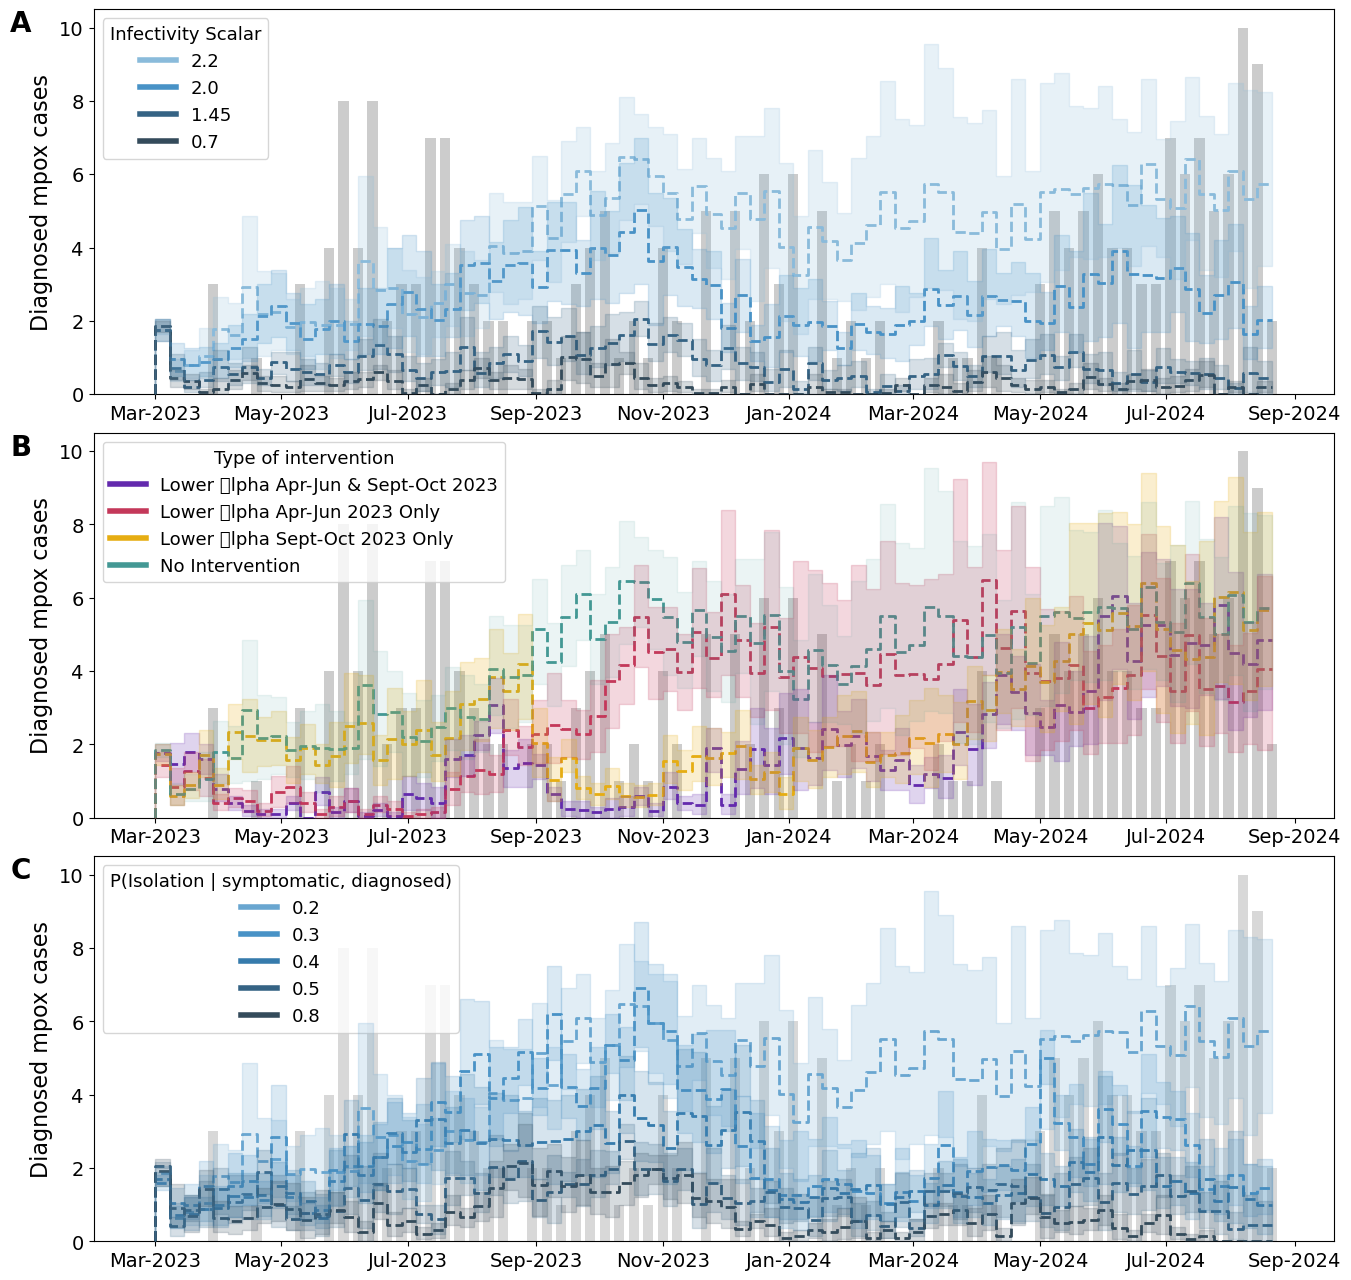

In [24]:
# Plotting α with phylo imports
fig = plt.figure(figsize=(16,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 1,  hspace=0.1)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0])

blues = sns.color_palette("Blues_d").as_hex()

sexual_behavior_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','Mean_S13', 'Mean_S12', 'Mean_S6','LowerBound_S13', 'LowerBound_S12', 'LowerBound_S6','UpperBound_S13', 'UpperBound_S12', 'UpperBound_S6', ])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
modeling_df.week_date = pd.to_datetime(modeling_df.week_date)

#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.4, width = 5)

#plot estimates with uncertainty intervals
ax1.step(modeling_df.week_date, modeling_df["Mean_S6"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)

ax1.step(modeling_df.week_date, modeling_df["Mean_S22"], color=blues[2],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S22"], modeling_df["UpperBound_S22"],alpha=0.2, step = "pre",  facecolor=blues[2],edgecolor=blues[2],zorder=1000)

# ax1.step(modeling_df.week_date, modeling_df["Mean_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S21"], modeling_df["UpperBound_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)

ax1.step(modeling_df.week_date, modeling_df["Mean_S12"], color=blues[4],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S12"], modeling_df["UpperBound_S12"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)

ax1.step(modeling_df.week_date, modeling_df["Mean_S13"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S13"], modeling_df["UpperBound_S13"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)


legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='upper left')



# Add the second subplot for the potential public health interventions based on phylo results
ax2 = fig.add_subplot(gs[1])

colors = sns.color_palette("CMRmap").as_hex()

PH_import_intervention_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S11', 'To.Aware_S15', 'To.Aware_S16','To.Aware_S17', 'To.Aware_S18', 'To.Aware_S19', 'To.Aware_S6'])
PH_import_intervention_long.week_date = pd.to_datetime(PH_import_intervention_long.week_date)

PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower FoI Apr-Jun & Sept-Oct 2023"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S15"] = "Lower FoI Apr-Jun 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S16"] = "Lower FoI Sept-Oct 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S17"] = "Randomly Selected 22 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S18"] = "Randomly Selected 13 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S19"] = "Randomly Selected 9 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S6"] = "No Intervention"


#plot empirical cases
ax2.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.4, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_df.week_date, modeling_df["Mean_S11"], color=colors[1],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S11"], modeling_df["UpperBound_S11"],alpha=0.2, step = "pre", facecolor=colors[1],edgecolor=colors[1],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S15"], color=colors[2],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S15"], modeling_df["UpperBound_S15"],alpha=0.2, step = "pre", facecolor=colors[2],edgecolor=colors[2],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S16"], color=colors[4],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S16"], modeling_df["UpperBound_S16"],alpha=0.2, step = "pre", facecolor=colors[4],edgecolor=colors[4],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=colors[1], lw=4, label='Lower \alpha Apr-Jun & Sept-Oct 2023'),
                mlines.Line2D([0], [0], color=colors[2], lw=4, label='Lower \alpha Apr-Jun 2023 Only'),
                mlines.Line2D([0], [0], color=colors[4], lw=4, label='Lower \alpha Sept-Oct 2023 Only'),
               mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax2.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')


# Add the third subplot 
ax3 = fig.add_subplot(gs[2])

long_prop_iso_df = pd.melt(modeling_df, id_vars='week_date', value_vars=["Empirical", 'To.Aware_S6', 'To.Aware_S5', "To.Aware_S4", "To.Aware_S3", "To.Aware_S14"])
long_prop_iso_df.week_date = pd.to_datetime(long_prop_iso_df.week_date)


#plot empirical cases
ax3.bar(long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].week_date ,long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax3.step(modeling_df.week_date, modeling_df["Mean_S6"], color=blues[1],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre", facecolor=blues[1],edgecolor=blues[1],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S5"], color=blues[2],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S5"], modeling_df["UpperBound_S5"],alpha=0.2, step = "pre", facecolor=blues[2],edgecolor=blues[2],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S4"], color=blues[3],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S4"], modeling_df["UpperBound_S4"],alpha=0.20, step = "pre", facecolor=blues[3],edgecolor=blues[3],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S3"], color=blues[4],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S3"], modeling_df["UpperBound_S3"],alpha=0.20, step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S14"], color=blues[5],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S14"], modeling_df["UpperBound_S14"],alpha=0.20, step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)


legend_list = [mlines.Line2D([0], [0], color=blues[1], lw=4, label='0.2'),
                mlines.Line2D([0], [0], color=blues[2], lw=4, label='0.3'),
                mlines.Line2D([0], [0], color=blues[3], lw=4, label='0.4'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='0.5'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.8'),]
ax3.legend(handles=legend_list, title='P(Isolation | symptomatic, diagnosed)', fontsize=13, title_fontsize=13, loc='upper left')


# Format the x-axis for dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_xlabel('')
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.tick_params(axis='both', which='minor', labelsize=14)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_xlabel('')
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.05, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.05, 1, "B", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3.text(-0.05, 1, "C", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  


# Show the plot
plt.tight_layout()
#plt.savefig('../figures/microsim_results_with_uncertainty_2.png',dpi=300,bbox_inches='tight')
plt.show()

In [25]:
print(sns.color_palette("CMRmap").as_hex())

['#2b2688', '#632aad', '#c4385a', '#f06510', '#e6ad12', '#e6e172']


/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/1549213603.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/1549213603.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower α Apr-Jun & Sept-Oct 2023"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/1549213603.py:98: SettingWithCopyWarning: 
A value is trying to be set

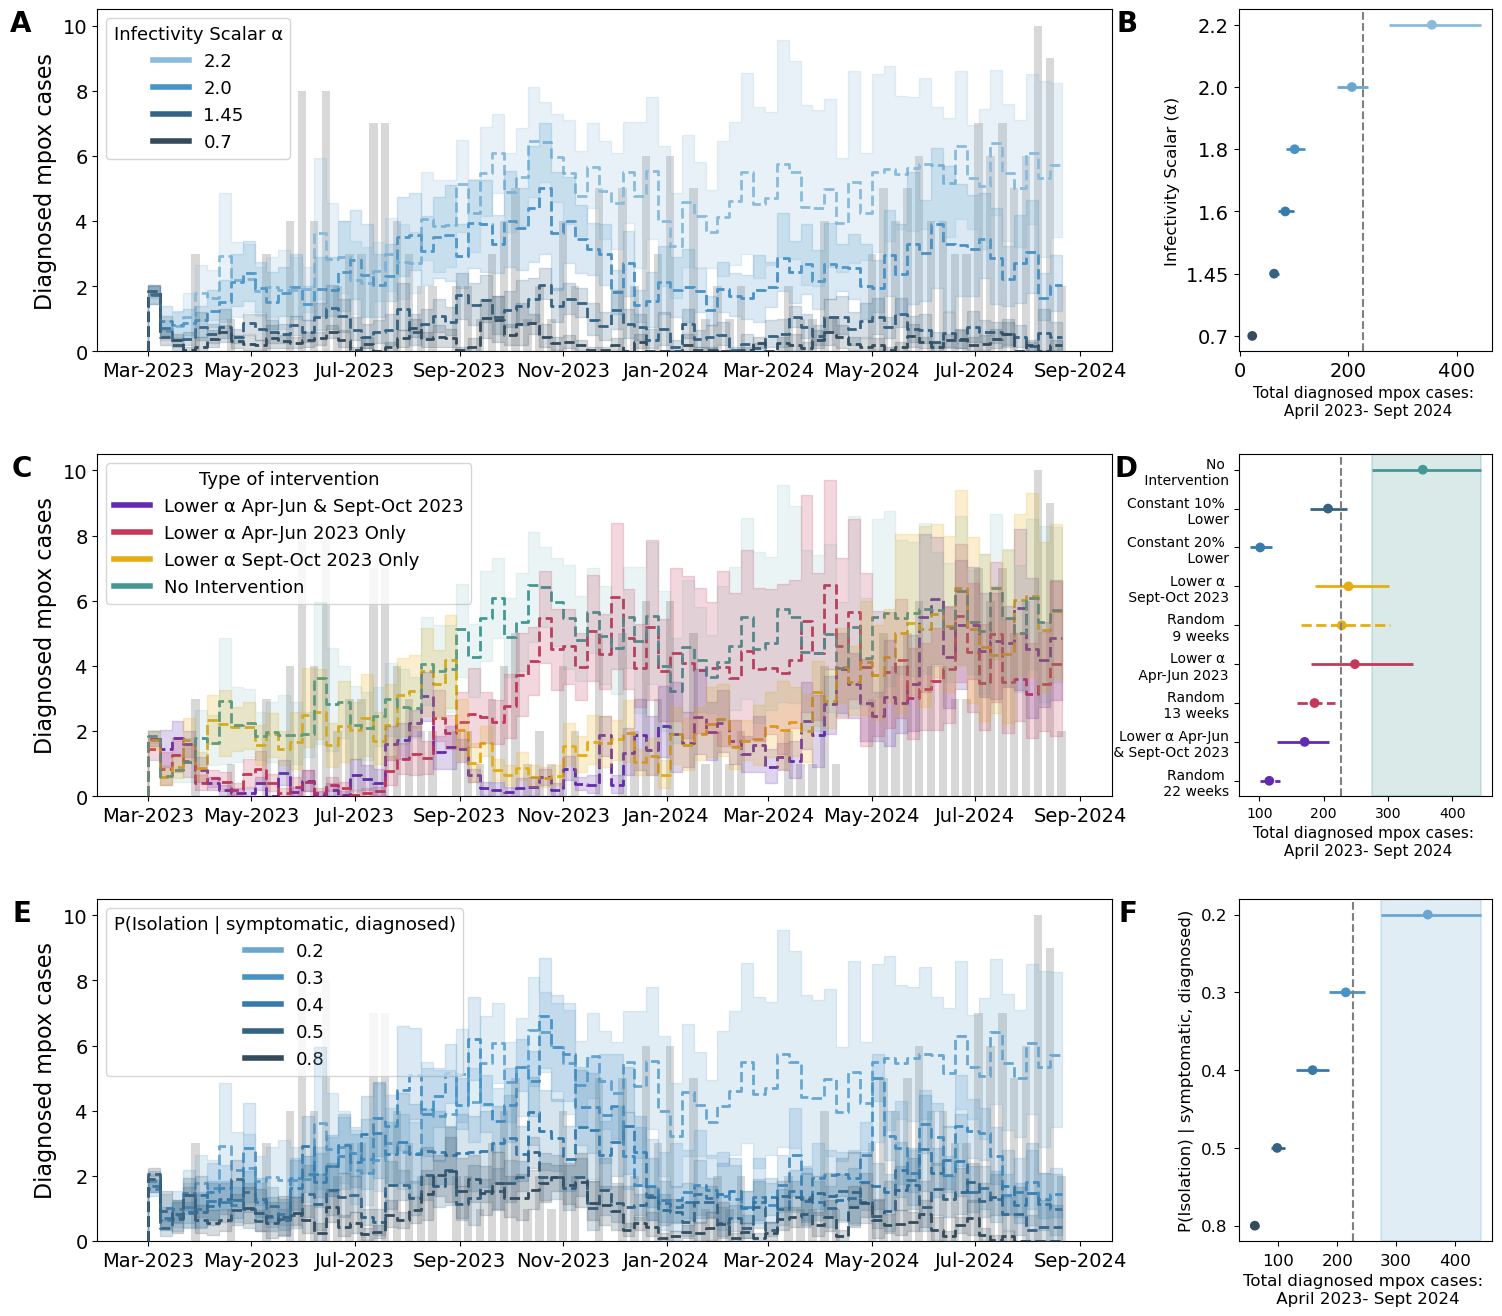

In [45]:
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()

sexual_behavior_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','Mean_S13', 'Mean_S12', 'Mean_S6','LowerBound_S13', 'LowerBound_S12', 'LowerBound_S6','UpperBound_S13', 'UpperBound_S12', 'UpperBound_S6', ])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
modeling_df.week_date = pd.to_datetime(modeling_df.week_date)

#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty interval
ax1.step(modeling_df.week_date, modeling_df["Mean_S6"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_S22"], color=blues[2],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S22"], modeling_df["UpperBound_S22"],alpha=0.2, step = "pre",  facecolor=blues[2],edgecolor=blues[2],zorder=1000)


# ax1.step(modeling_df.week_date, modeling_df["Mean_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S21"], modeling_df["UpperBound_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_S12"], color=blues[4],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S12"], modeling_df["UpperBound_S12"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_S13"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S13"], modeling_df["UpperBound_S13"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

### add subplot for intervention

ax1_1 = fig.add_subplot(gs[0, 1])

blues = sns.color_palette("Blues_d").as_hex()

infection_scalar_cats = ["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S22"].iloc[-1], merged_df["Cum_Mean_S21"].iloc[-1], merged_df["Cum_Mean_S20"].iloc[-1] , merged_df["Cum_Mean_S12"].iloc[-1], merged_df["Cum_Mean_S13"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S22"].iloc[-1], merged_df["Cum_LowerBound_S21"].iloc[-1], merged_df["Cum_LowerBound_S20"].iloc[-1] , merged_df["Cum_LowerBound_S12"].iloc[-1], merged_df["Cum_LowerBound_S13"].iloc[-1] ]
values_ub = [ merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S22"].iloc[-1], merged_df["Cum_UpperBound_S21"].iloc[-1], merged_df["Cum_UpperBound_S20"].iloc[-1] , merged_df["Cum_UpperBound_S12"].iloc[-1], merged_df["Cum_UpperBound_S13"].iloc[-1] ]
colors = [blues[0], blues[1], blues[2], blues[3],blues[4], blues[5]]

ax1_1.scatter( values, infection_scalar_cats, color = colors)

ax1_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

ax1_1.axvline(x=(merged_df["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax1_1.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

#ax1_1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='lower right')


ax1_1.tick_params(axis='both', which='major', labelsize=14)
ax1_1.tick_params(axis='both', which='minor', labelsize=14)
ax1_1.set_ylabel('Infectivity Scalar (α)', size = 12)
ax1_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)


####
# Add the second subplot for the potential public health interventions based on phylo results
####
ax2 = fig.add_subplot(gs[1, 0])

colors = sns.color_palette("CMRmap").as_hex()

PH_import_intervention_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S11', 'To.Aware_S15', 'To.Aware_S16','To.Aware_S17', 'To.Aware_S18', 'To.Aware_S19', 'To.Aware_S6'])
PH_import_intervention_long.week_date = pd.to_datetime(PH_import_intervention_long.week_date)

PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower α Apr-Jun & Sept-Oct 2023"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S15"] = "Lower α Apr-Jun 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S16"] = "Lower α Sept-Oct 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S17"] = "Randomly Selected 22 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S18"] = "Randomly Selected 13 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S19"] = "Randomly Selected 9 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S6"] = "No Intervention"


#plot empirical cases
ax2.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_df.week_date, modeling_df["Mean_S11"], color=colors[1],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S11"], modeling_df["UpperBound_S11"],alpha=0.2, step = "pre", facecolor=colors[1],edgecolor=colors[1],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S15"], color=colors[2],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S15"], modeling_df["UpperBound_S15"],alpha=0.2, step = "pre", facecolor=colors[2],edgecolor=colors[2],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S16"], color=colors[4],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S16"], modeling_df["UpperBound_S16"],alpha=0.2, step = "pre", facecolor=colors[4],edgecolor=colors[4],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)

#plot legend
legend_list = [mlines.Line2D([0], [0], color=colors[1], lw=4, label='Lower α Apr-Jun & Sept-Oct 2023'),
               mlines.Line2D([0], [0], color=colors[2], lw=4, label='Lower α Apr-Jun 2023 Only'),
               mlines.Line2D([0], [0], color=colors[4], lw=4, label='Lower α Sept-Oct 2023 Only'),
               mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax2.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')

###
# add in overall dx cases subplot
###

ax2_1 = fig.add_subplot(gs[1, 1])


c_ramp = sns.color_palette("CMRmap").as_hex()

infection_scalar_cats = ["No \n Intervention", "Constant 10% \n Lower", "Constant 20% \n Lower",  "Lower α \n Sept-Oct 2023", "Random \n 9 weeks", "Lower α \n Apr-Jun 2023", "Random \n 13 weeks", "Lower α Apr-Jun\n & Sept-Oct 2023", "Random \n 22 weeks"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S22"].iloc[-1], merged_df["Cum_Mean_S21"].iloc[-1], merged_df["Cum_Mean_S16"].iloc[-1], merged_df["Cum_Mean_S19"].iloc[-1], merged_df["Cum_Mean_S15"].iloc[-1], merged_df["Cum_Mean_S18"].iloc[-1] , merged_df["Cum_Mean_S11"].iloc[-1], merged_df["Cum_Mean_S17"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S22"].iloc[-1], merged_df["Cum_LowerBound_S21"].iloc[-1], merged_df["Cum_LowerBound_S16"].iloc[-1], merged_df["Cum_LowerBound_S19"].iloc[-1], merged_df["Cum_LowerBound_S15"].iloc[-1], merged_df["Cum_LowerBound_S18"].iloc[-1] , merged_df["Cum_LowerBound_S11"].iloc[-1], merged_df["Cum_LowerBound_S17"].iloc[-1] ]
values_ub = [merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S22"].iloc[-1], merged_df["Cum_UpperBound_S21"].iloc[-1], merged_df["Cum_UpperBound_S16"].iloc[-1], merged_df["Cum_UpperBound_S19"].iloc[-1], merged_df["Cum_UpperBound_S15"].iloc[-1], merged_df["Cum_UpperBound_S18"].iloc[-1] , merged_df["Cum_UpperBound_S11"].iloc[-1], merged_df["Cum_UpperBound_S17"].iloc[-1] ]
colors = ["#439894", blues[4], blues[3], c_ramp[4], c_ramp[4], c_ramp[2], c_ramp[2],c_ramp[1], c_ramp[1]]
styles = ["solid", "solid","solid", "solid",  '--', "solid", '--', "solid", '--']
ax2_1.scatter( values, infection_scalar_cats, color = colors)

ax2_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

ax2_1.axvline(x=(merged_df["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax2_1.axvspan(merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S6"].iloc[-1], color="#439894", alpha = 0.2, linewidth=1.5)

ax2_1.invert_yaxis()
ax2_1.tick_params(axis='both', which='major', labelsize=10)
ax2_1.tick_params(axis='both', which='minor', labelsize=10)
ax2_1.set_ylabel('')
ax2_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)


###
# Add the third main plot regarding P(isolation | symptomatic, diagnosed)
###
ax3 = fig.add_subplot(gs[2, 0])

long_prop_iso_df = pd.melt(modeling_df, id_vars='week_date', value_vars=["Empirical", 'To.Aware_S6', 'To.Aware_S5', "To.Aware_S4", "To.Aware_S3", "To.Aware_S14"])
long_prop_iso_df.week_date = pd.to_datetime(long_prop_iso_df.week_date)

#plot empirical cases
ax3.bar(long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].week_date ,long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax3.step(modeling_df.week_date, modeling_df["Mean_S6"], color=blues[1],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre", facecolor=blues[1],edgecolor=blues[1],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S5"], color=blues[2],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S5"], modeling_df["UpperBound_S5"],alpha=0.2, step = "pre", facecolor=blues[2],edgecolor=blues[2],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S4"], color=blues[3],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S4"], modeling_df["UpperBound_S4"],alpha=0.20, step = "pre", facecolor=blues[3],edgecolor=blues[3],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S3"], color=blues[4],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S3"], modeling_df["UpperBound_S3"],alpha=0.20, step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S14"], color=blues[5],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S14"], modeling_df["UpperBound_S14"],alpha=0.20, step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

## add legend
legend_list = [mlines.Line2D([0], [0], color=blues[1], lw=4, label='0.2'),
                mlines.Line2D([0], [0], color=blues[2], lw=4, label='0.3'),
                mlines.Line2D([0], [0], color=blues[3], lw=4, label='0.4'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='0.5'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.8'),]
ax3.legend(handles=legend_list, title='P(Isolation | symptomatic, diagnosed)', fontsize=13, title_fontsize=13, loc='upper left')

###
# add third subplot
###

ax3_1 = fig.add_subplot(gs[2, 1])

# define colors
blues = sns.color_palette("Blues_d").as_hex()

# definte data to plot
infection_scalar_cats = ["0.2", "0.3", "0.4", "0.5", "0.8"]

# values = [ merged_df["Mean_S6"].iloc[-1], merged_df["Mean_S5"].iloc[-1], merged_df["Mean_S4"].iloc[-1], merged_df["Mean_S3"].iloc[-1] , merged_df["Mean_S14"].iloc[-1] ]
# values_lb = [ merged_df["LowerBound_S6"].iloc[-1], merged_df["LowerBound_S5"].iloc[-1], merged_df["LowerBound_S4"].iloc[-1], merged_df["LowerBound_S3"].iloc[-1] , merged_df["LowerBound_S14"].iloc[-1] ]
# values_ub = [ merged_df["UpperBound_S6"].iloc[-1], merged_df["UpperBound_S5"].iloc[-1], merged_df["UpperBound_S4"].iloc[-1], merged_df["UpperBound_S3"].iloc[-1] , merged_df["UpperBound_S14"].iloc[-1]]

values = [merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S5"].iloc[-1], merged_df["Cum_Mean_S4"].iloc[-1], merged_df["Cum_Mean_S3"].iloc[-1], merged_df["Cum_Mean_S14"].iloc[-1]]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S5"].iloc[-1], merged_df["Cum_LowerBound_S4"].iloc[-1], merged_df["Cum_LowerBound_S3"].iloc[-1] , merged_df["Cum_LowerBound_S14"].iloc[-1]]
values_ub = [ merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S5"].iloc[-1], merged_df["Cum_UpperBound_S4"].iloc[-1], merged_df["Cum_UpperBound_S3"].iloc[-1] , merged_df["Cum_UpperBound_S14"].iloc[-1]]
colors = [blues[1], blues[2], blues[3], blues[4],blues[5]]

# plot!
ax3_1.scatter(values, infection_scalar_cats, color = colors)

ax3_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

ax3_1.axvline(x=(merged_df["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax3_1.axvspan(merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S6"].iloc[-1], color=blues[1], alpha = 0.2, linewidth=1.5)


ax3_1.invert_yaxis()
ax3_1.tick_params(axis='both', which='major', labelsize=12, pad =5)
ax3_1.tick_params(axis='both', which='minor', labelsize=12)
ax3_1.set_ylabel('P(Isolation) | symptomatic, diagnosed)', size = 12)
ax3_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 12)


##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_xlabel('')
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.tick_params(axis='both', which='minor', labelsize=14)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_xlabel('')
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3.text(-0.065, 1, "E", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3_1.text(-0.4, 1, "F", transform=ax3_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 

# Show the plot
plt.tight_layout()
#plt.savefig('../figures/microsim_results_with_uncertainty_combined.png',dpi=300,bbox_inches='tight')
plt.show()

5

/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_5523/3934707463.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


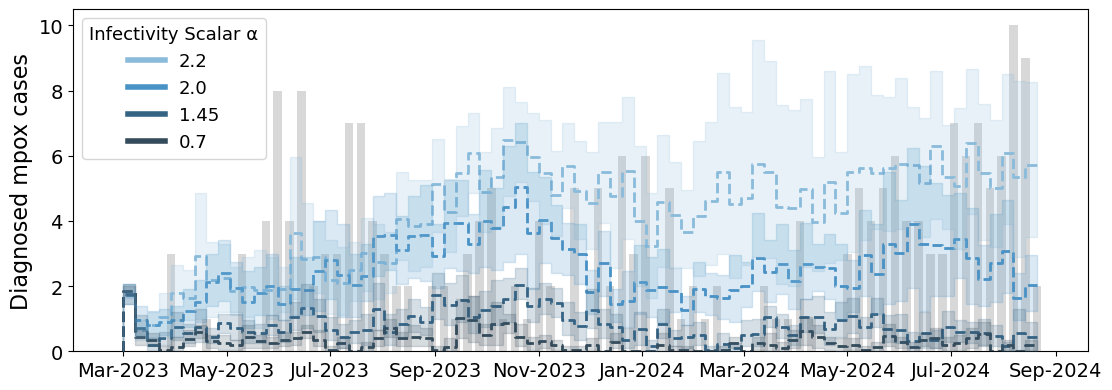

In [8]:
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
#gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()

sexual_behavior_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','Mean_S13', 'Mean_S12', 'Mean_S6','LowerBound_S13', 'LowerBound_S12', 'LowerBound_S6','UpperBound_S13', 'UpperBound_S12', 'UpperBound_S6', ])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
modeling_df.week_date = pd.to_datetime(modeling_df.week_date)

#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
#plot estimates with uncertainty intervals
ax1.step(modeling_df.week_date, modeling_df["Mean_S6"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_S22"], color=blues[2],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S22"], modeling_df["UpperBound_S22"],alpha=0.2, step = "pre",  facecolor=blues[2],edgecolor=blues[2],zorder=1000)


# ax1.step(modeling_df.week_date, modeling_df["Mean_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S21"], modeling_df["UpperBound_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_S12"], color=blues[4],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S12"], modeling_df["UpperBound_S12"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_S13"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S13"], modeling_df["UpperBound_S13"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')



##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_xlabel('')
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.tick_params(axis='both', which='minor', labelsize=14)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_xlabel('')
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
#ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
#ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
#ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
# ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
# ax3.text(-0.065, 1, "E", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
# ax3_1.text(-0.4, 1, "F", transform=ax3_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 

# Show the plot
plt.tight_layout()
plt.savefig('../figures/alpha_line_all.png',dpi=300,bbox_inches='tight')
plt.show()

## Supp Fig 14 - Rt comparisons 

In [9]:
## all the microsimulation results with uncertainty intervals are in seperate folders and files. This function combines all those results
## into a single dataframe. Of note, this specific code snippet was created with help of ChatGPT and 
## edited by Miguel Paredes. The rest of this notebook was written by Miguel. 

# Define the parent folder containing the subfolders
parent_folder = "../data/MonteCarloResults/"

# Initialize an empty list to store the processed DataFrames
dataframes = []

# Loop through each subfolder in the parent folder
for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    # Check if the current path is a folder and matches the pattern "S0" to "S9"
    if os.path.isdir(subfolder_path) and subfolder.startswith("new"):
        file_path = os.path.join(subfolder_path, "r_t_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}",
                "UpperBound": f"UpperBound_{folder_name}",
                "LowerBound": f"LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
    
    elif os.path.isdir(subfolder_path) and subfolder.startswith("S"):
        file_path = os.path.join(subfolder_path, "r_t_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[1]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}",
                "UpperBound": f"UpperBound_{folder_name}",
                "LowerBound": f"LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)

# Merge all DataFrames on the "Week" column
combined_df = dataframes[0]
for df in dataframes[1:]:
    combined_df = pd.merge(combined_df, df, on="Week")
    
empirical_df = pd.read_csv("../data/microsimulation_results/scenarios_aware.csv")
empirical_df = empirical_df[["week", "Empirical"]]


merged_rt_df = pd.merge(combined_df, empirical_df, left_on = "Week", right_on = "week" )
merged_rt_df.head()

,Week,Mean_S12,LowerBound_S12,UpperBound_S12,Mean_S15,LowerBound_S15,UpperBound_S15,Mean_S23,LowerBound_S23,UpperBound_S23,...,LowerBound_S6,UpperBound_S6,Mean_S1,LowerBound_S1,UpperBound_S1,Mean_S8,LowerBound_S8,UpperBound_S8,week,Empirical
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0,0.0
1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,1,0.0
2,2,0.106463,0.040179,0.194345,0.391897,0.203333,0.600000,0.133915,0.057500,0.210833,...,0.140000,0.450000,0.024150,0.000,0.075,0.050722,0.033657,0.069028,2,0.0
3,3,0.206150,0.115625,0.293750,0.231491,0.151785,0.297007,0.192091,0.068367,0.338350,...,0.155847,0.450963,0.149617,0.025,0.275,0.075924,0.052198,0.101129,3,0.0
4,4,0.283604,0.127778,0.458111,NaN,0.073875,0.212875,NaN,0.050000,0.331181,...,0.310530,0.953896,NaN,0.000,0.000,0.049259,0.025761,0.076207,4,3.0


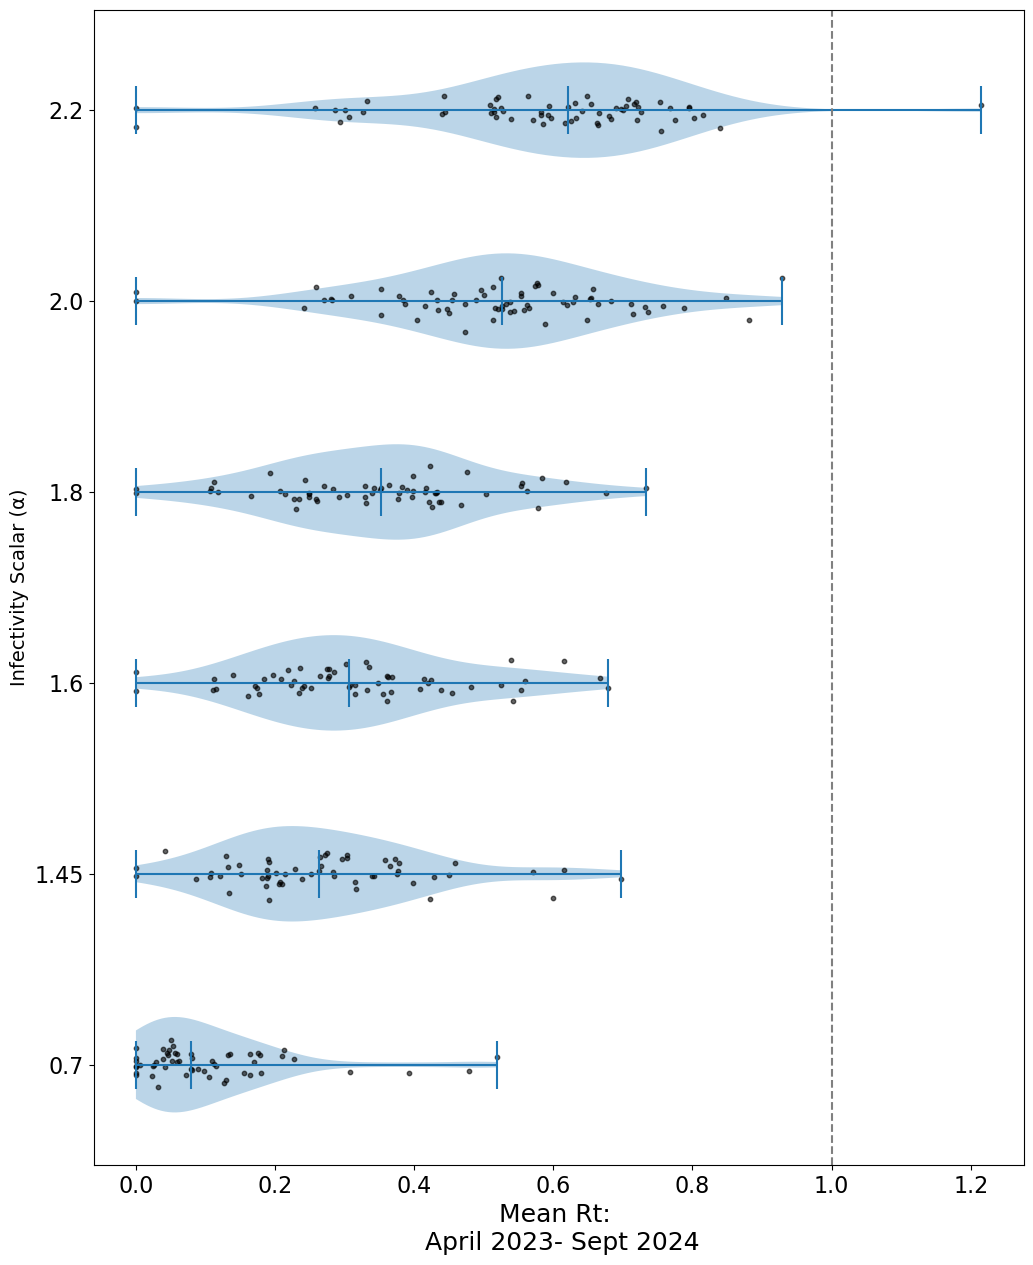

In [11]:
### add subplot for intervention
fig,ax = plt.subplots(figsize=(12,15),facecolor='w')

blues = sns.color_palette("Blues_d").as_hex()

# Create violin plots

positions = [1, 2, 3, 4, 5, 6]
means = [merged_rt_df["Mean_S6"].dropna(), merged_rt_df["Mean_S22"].dropna(), merged_rt_df["Mean_S21"].dropna(), merged_rt_df["Mean_S20"].dropna() , merged_rt_df["Mean_S12"].dropna(), merged_rt_df["Mean_S13"].dropna()]
parts = ax.violinplot(means, positions=positions, showmeans=False, showmedians=True, vert= False)

# Scatter plot individual data points
for i, data in enumerate(means, start=1):
    x = np.random.normal(i, 0.05, size=len(data))  # Add jitter for better visibility
    ax.scatter(data, x,  alpha=0.6, color='black', s=10)

colors = [blues[5], blues[4], blues[3], blues[2],blues[1], blues[0]]
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5)

# Set y-ticks and labels properly
ax.set_yticks(positions)
ax.set_yticklabels(["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"], size=18)
ax.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]


ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=16)
ax.set_ylabel('Infectivity Scalar (α)', size = 14)
ax.set_xlabel('Mean Rt: \n April 2023- Sept 2024', size = 18)

plt.savefig('../figures/rt_and_alpha.png',dpi=300,bbox_inches='tight')
plt.show()


In [12]:
merged_rt_df["Mean_S6"].dropna().median()

0.621708997452641

## supp Fig 12

/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/2447293438.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/2447293438.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower FoI Apr-Jun & Sept-Oct 2023"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/2447293438.py:22: SettingWithCopyWarning: 
A value is trying to be s

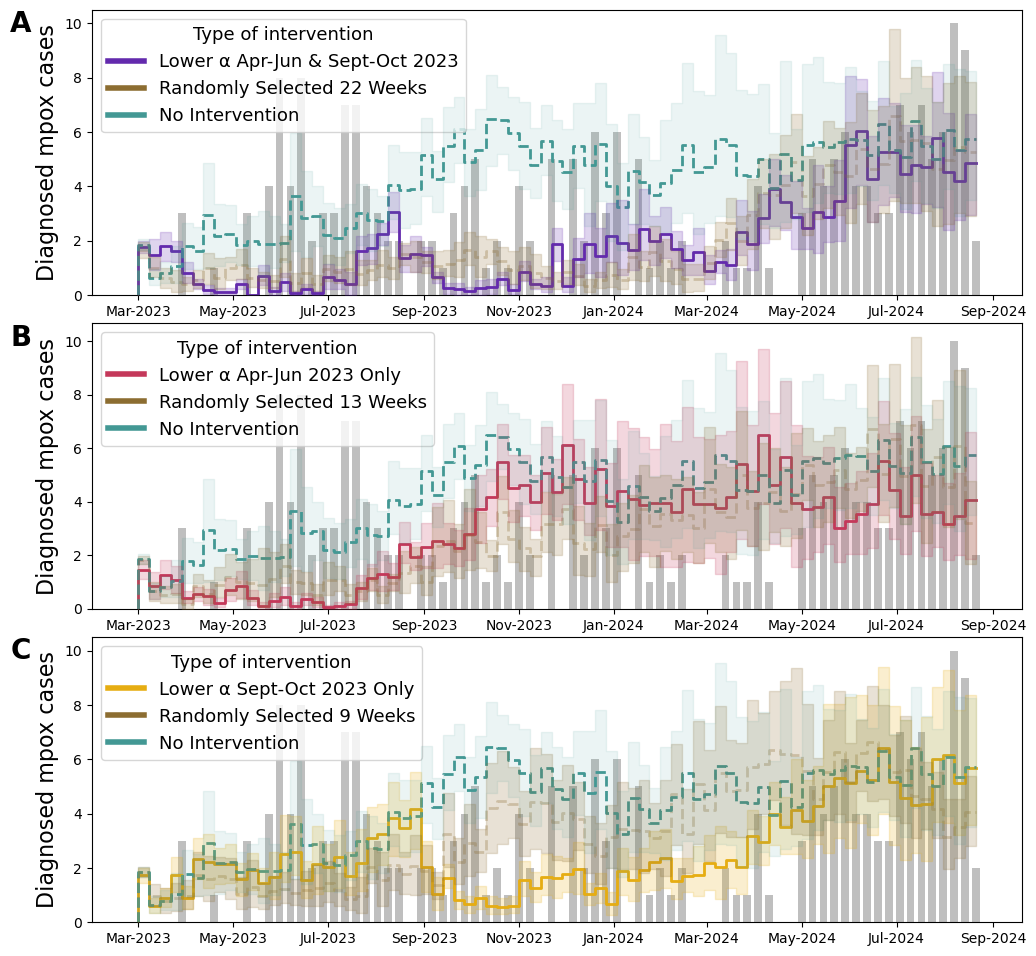

In [46]:
# Below is Figure S9 which highlights the statistical comparison for panel B in the mainfigure 5
fig = plt.figure(figsize=(12,20),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(5,1,  hspace=0.1)  # three rows, one column



# Add the second subplot for the potential public health interventions based on phylo results
ax2 = fig.add_subplot(gs[1])

#modeling_df = modeling_df[modeling_df.week_date < "2024-01-01" ]

colors = sns.color_palette("CMRmap").as_hex()

PH_import_intervention_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S11', 'To.Aware_S15', 'To.Aware_S16','To.Aware_S17', 'To.Aware_S18', 'To.Aware_S19', 'To.Aware_S6'])
PH_import_intervention_long.week_date = pd.to_datetime(PH_import_intervention_long.week_date)

PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower FoI Apr-Jun & Sept-Oct 2023"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S15"] = "Lower FoI Apr-Jun 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S16"] = "Lower FoI Sept-Oct 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S17"] = "Randomly Selected 22 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S18"] = "Randomly Selected 13 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S19"] = "Randomly Selected 9 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S6"] = "No Intervention"


#plot empirical cases
ax2.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_df.week_date, modeling_df["Mean_S11"], color=colors[1],lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S11"], modeling_df["UpperBound_S11"],alpha=0.2, step = "pre", facecolor=colors[1],edgecolor=colors[1],zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["LowerBound_S11"],color=colors[1],lw=1,zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["UpperBound_S11"],color=colors[1],lw=1,zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S23"], color="#8c6d31", alpha = 0.3, ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S23"], modeling_df["UpperBound_S23"],alpha=0.2, step = "pre", facecolor="#8c6d31",edgecolor="#8c6d31",zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)


legend_list = [mlines.Line2D([0], [0], color=colors[1], lw=4, label='Lower α Apr-Jun & Sept-Oct 2023'),
                mlines.Line2D([0], [0], color="#8c6d31", lw=4, label='Randomly Selected 22 Weeks'),
              mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax2.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')


# Add the third subplot 
ax3 = fig.add_subplot(gs[2])

#plot empirical cases
ax3.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

#plot estimates with uncertainty intervals
ax3.step(modeling_df.week_date, modeling_df["Mean_S15"], color=colors[2],lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S15"], modeling_df["UpperBound_S15"],alpha=0.2, step = "pre", facecolor=colors[2],edgecolor=colors[2],zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["LowerBound_S11"],color=colors[1],lw=1,zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["UpperBound_S11"],color=colors[1],lw=1,zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S24"], color="#8c6d31", alpha = 0.3, ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S24"], modeling_df["UpperBound_S24"],alpha=0.2, step = "pre", facecolor="#8c6d31",edgecolor="#8c6d31",zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)


legend_list = [mlines.Line2D([0], [0], color=colors[2], lw=4, label='Lower α Apr-Jun 2023 Only'),
                mlines.Line2D([0], [0], color="#8c6d31", lw=4, label='Randomly Selected 13 Weeks'),
              mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax3.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')


# Add the fourth subplot 
ax4 = fig.add_subplot(gs[3])

#plot empirical cases
ax4.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

#plot estimates with uncertainty intervals
ax4.step(modeling_df.week_date, modeling_df["Mean_S16"], color=colors[4],lw=2 )
ax4.fill_between(modeling_df.week_date, modeling_df["LowerBound_S16"], modeling_df["UpperBound_S16"],alpha=0.2, step = "pre", facecolor=colors[4],edgecolor=colors[4],zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["LowerBound_S11"],color=colors[1],lw=1,zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["UpperBound_S11"],color=colors[1],lw=1,zorder=1000)

ax4.step(modeling_df.week_date, modeling_df["Mean_S25"], color="#8c6d31", alpha = 0.3, ls='--',lw=2 )
ax4.fill_between(modeling_df.week_date, modeling_df["LowerBound_S25"], modeling_df["UpperBound_S25"],alpha=0.2, step = "pre", facecolor="#8c6d31",edgecolor="#8c6d31",zorder=1000)

ax4.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax4.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=colors[4], lw=4, label='Lower α Sept-Oct 2023 Only'),
                mlines.Line2D([0], [0], color="#8c6d31", lw=4, label='Randomly Selected 9 Weeks'),
              mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax4.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')





ax1.legend(title = "Infectivity Scalar α", loc = "upper left")



# Format the x-axis for dates
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
#ax1.xticks(rotation=45)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax4.set_ylabel('Diagnosed mpox cases', size = 16)
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "A", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 
ax3.text(-0.065, 1, "B", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax4.text(-0.065, 1, "C", transform=ax4.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 



# Show the plot
plt.tight_layout()
plt.savefig('../figures/microsim_results_supp.png',dpi=300,bbox_inches='tight')
plt.show()

/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/985085186.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/985085186.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower FoI Apr-Jun & Sept-Oct 2023"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/985085186.py:23: SettingWithCopyWarning: 
A value is trying to be set 

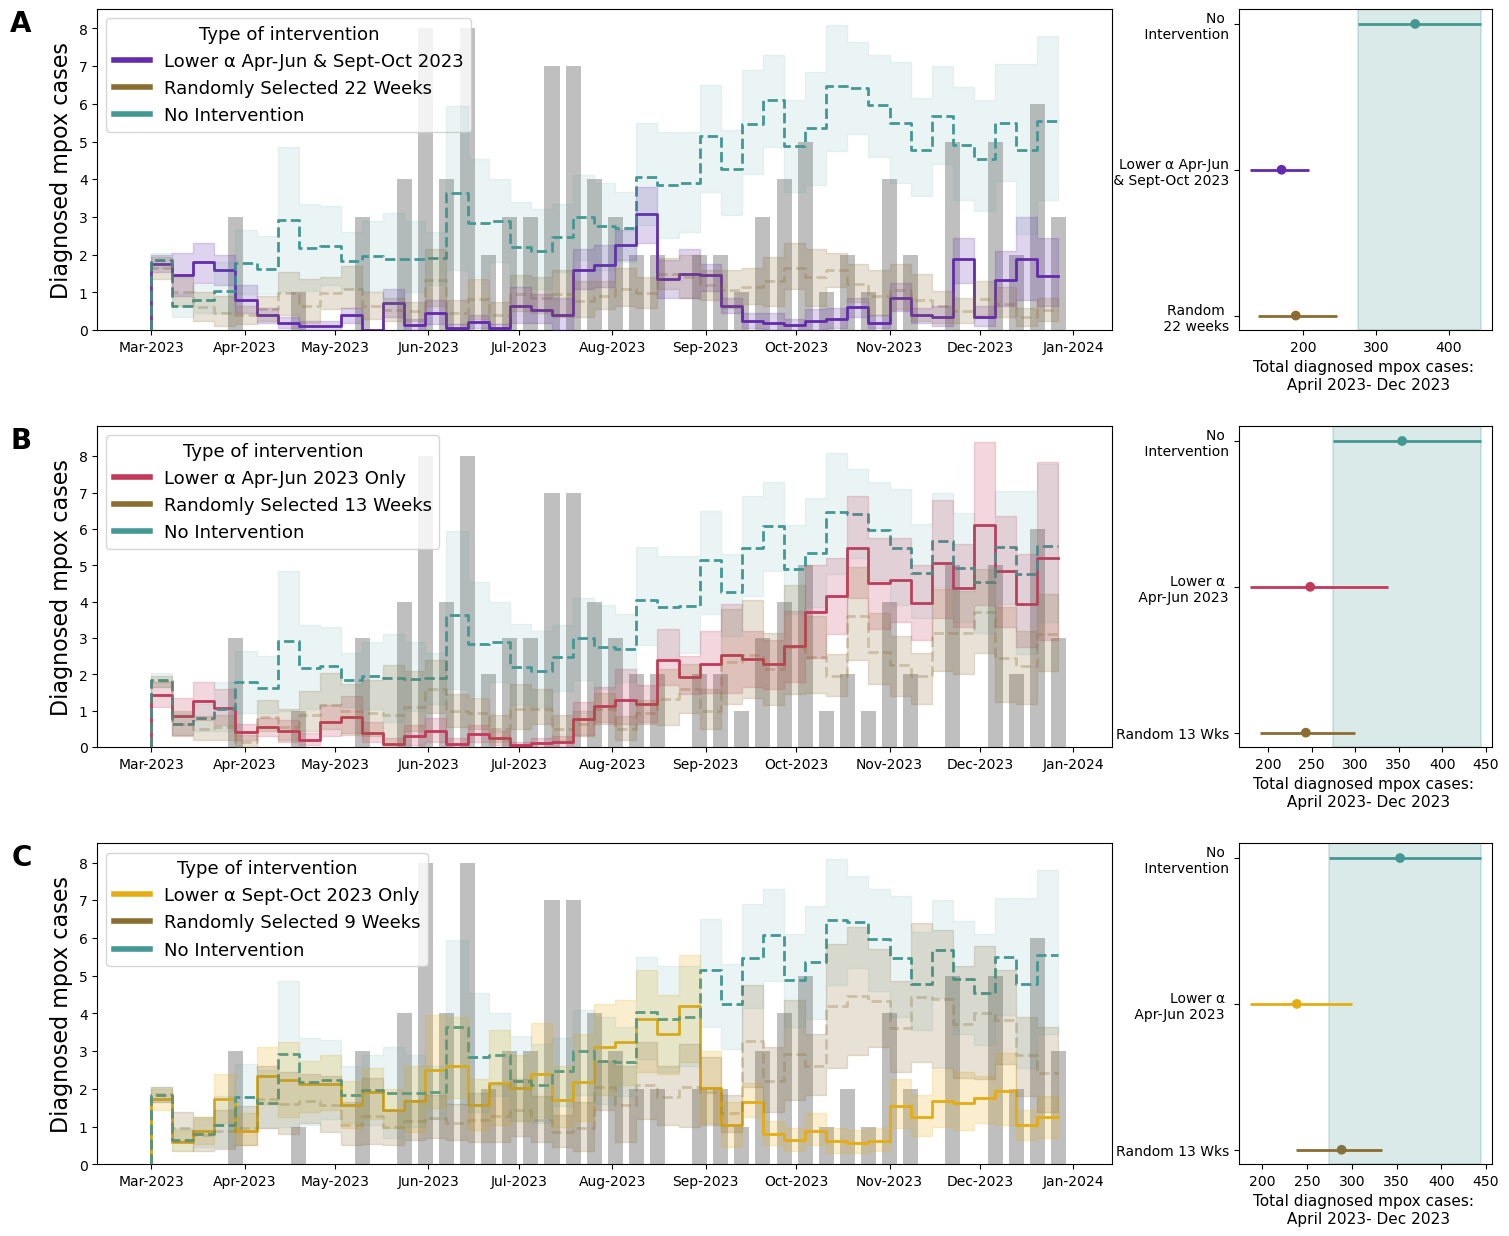

In [48]:
#truncated time frame for easier view of impact
fig = plt.figure(figsize=(18,15),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
#gs = GridSpec(5,1,  hspace=0.1)  # three rows, one column

gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column


# Add the second subplot for the potential public health interventions based on phylo results
ax2 = fig.add_subplot(gs[0,0])

modeling_short_df = modeling_df[modeling_df.week_date < "2024-01-01" ]

colors = sns.color_palette("CMRmap").as_hex()

PH_import_intervention_long = pd.melt(modeling_short_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S11', 'To.Aware_S15', 'To.Aware_S16','To.Aware_S17', 'To.Aware_S18', 'To.Aware_S19', 'To.Aware_S6'])
PH_import_intervention_long.week_date = pd.to_datetime(PH_import_intervention_long.week_date)

PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower FoI Apr-Jun & Sept-Oct 2023"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S15"] = "Lower FoI Apr-Jun 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S16"] = "Lower FoI Sept-Oct 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S17"] = "Randomly Selected 22 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S18"] = "Randomly Selected 13 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S19"] = "Randomly Selected 9 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S6"] = "No Intervention"


#plot empirical cases
ax2.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_short_df.week_date, modeling_short_df["Mean_S11"], color=colors[1],lw=2 )
ax2.fill_between(modeling_short_df.week_date, modeling_short_df["LowerBound_S11"], modeling_short_df["UpperBound_S11"],alpha=0.2, step = "pre", facecolor=colors[1],edgecolor=colors[1],zorder=1000)
# ax2.plot(modeling_short_df.week_date, modeling_short_df["LowerBound_S11"],color=colors[1],lw=1,zorder=1000)
# ax2.plot(modeling_short_df.week_date, modeling_short_df["UpperBound_S11"],color=colors[1],lw=1,zorder=1000)

ax2.step(modeling_short_df.week_date, modeling_short_df["Mean_S23"], color="#8c6d31", alpha = 0.3, ls='--',lw=2 )
ax2.fill_between(modeling_short_df.week_date, modeling_short_df["LowerBound_S23"], modeling_short_df["UpperBound_S23"],alpha=0.2, step = "pre", facecolor="#8c6d31",edgecolor="#8c6d31",zorder=1000)

ax2.step(modeling_short_df.week_date, modeling_short_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax2.fill_between(modeling_short_df.week_date, modeling_short_df["LowerBound_S6"], modeling_short_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)


legend_list = [mlines.Line2D([0], [0], color=colors[1], lw=4, label='Lower α Apr-Jun & Sept-Oct 2023'),
                mlines.Line2D([0], [0], color="#8c6d31", lw=4, label='Randomly Selected 22 Weeks'),
              mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax2.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')

## now add in cumulative charts
ax2_1 = fig.add_subplot(gs[0, 1])


c_ramp = sns.color_palette("CMRmap").as_hex()

infection_scalar_cats = ["No \n Intervention", "Lower α Apr-Jun\n & Sept-Oct 2023", "Random \n 22 weeks"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S11"].iloc[-1], merged_df["Cum_Mean_S23"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S11"].iloc[-1], merged_df["Cum_LowerBound_S23"].iloc[-1] ]
values_ub = [merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S11"].iloc[-1], merged_df["Cum_UpperBound_S23"].iloc[-1] ]
color_list = ["#439894", colors[1], "#8c6d31"]
styles = ["solid", "solid","solid"]
ax2_1.scatter( values, infection_scalar_cats, color = color_list)

ax2_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=color_list,linestyle=styles,  linewidth=2)

#ax2_1.axvline(x=(merged_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

ax2_1.axvspan(merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S6"].iloc[-1], color="#439894", alpha = 0.2, linewidth=1.5)

ax2_1.invert_yaxis()
ax2_1.tick_params(axis='both', which='major', labelsize=10)
ax2_1.tick_params(axis='both', which='minor', labelsize=10)
ax2_1.set_ylabel('')
ax2_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Dec 2023', size = 11)



# Add the third subplot 
ax3 = fig.add_subplot(gs[1,0])

#plot empirical cases
ax3.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

#plot estimates with uncertainty intervals
ax3.step(modeling_short_df.week_date, modeling_short_df["Mean_S15"], color=colors[2],lw=2 )
ax3.fill_between(modeling_short_df.week_date, modeling_short_df["LowerBound_S15"], modeling_short_df["UpperBound_S15"],alpha=0.2, step = "pre", facecolor=colors[2],edgecolor=colors[2],zorder=1000)
# ax2.plot(modeling_short_df.week_date, modeling_short_df["LowerBound_S11"],color=colors[1],lw=1,zorder=1000)
# ax2.plot(modeling_short_df.week_date, modeling_short_df["UpperBound_S11"],color=colors[1],lw=1,zorder=1000)

ax3.step(modeling_short_df.week_date, modeling_short_df["Mean_S24"], color="#8c6d31", alpha = 0.3, ls='--',lw=2 )
ax3.fill_between(modeling_short_df.week_date, modeling_short_df["LowerBound_S24"], modeling_short_df["UpperBound_S24"],alpha=0.2, step = "pre", facecolor="#8c6d31",edgecolor="#8c6d31",zorder=1000)

ax3.step(modeling_short_df.week_date, modeling_short_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax3.fill_between(modeling_short_df.week_date, modeling_short_df["LowerBound_S6"], modeling_short_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)


legend_list = [mlines.Line2D([0], [0], color=colors[2], lw=4, label='Lower α Apr-Jun 2023 Only'),
                mlines.Line2D([0], [0], color="#8c6d31", lw=4, label='Randomly Selected 13 Weeks'),
              mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax3.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')


## now add in cumulative charts
ax3_1 = fig.add_subplot(gs[1, 1])


c_ramp = sns.color_palette("CMRmap").as_hex()

infection_scalar_cats = ["No \n Intervention", "Lower α \n Apr-Jun 2023", "Random 13 Wks"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S15"].iloc[-1], merged_df["Cum_Mean_S24"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S15"].iloc[-1], merged_df["Cum_LowerBound_S24"].iloc[-1] ]
values_ub = [merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S15"].iloc[-1], merged_df["Cum_UpperBound_S24"].iloc[-1] ]
color_list = ["#439894", colors[2], "#8c6d31"]
styles = ["solid", "solid","solid"]
ax3_1.scatter( values, infection_scalar_cats, color = color_list)

ax3_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=color_list,linestyle=styles,  linewidth=2)

#ax3_1.axvline(x=(merged_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

ax3_1.axvspan(merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S6"].iloc[-1], color="#439894", alpha = 0.2, linewidth=1.5)

ax3_1.invert_yaxis()
ax3_1.tick_params(axis='both', which='major', labelsize=10)
ax3_1.tick_params(axis='both', which='minor', labelsize=10)
ax3_1.set_ylabel('')
ax3_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Dec 2023', size = 11)

# Add the fourth subplot 
ax4 = fig.add_subplot(gs[2,0])

#plot empirical cases
ax4.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

#plot estimates with uncertainty intervals
ax4.step(modeling_short_df.week_date, modeling_short_df["Mean_S16"], color=colors[4],lw=2 )
ax4.fill_between(modeling_short_df.week_date, modeling_short_df["LowerBound_S16"], modeling_short_df["UpperBound_S16"],alpha=0.2, step = "pre", facecolor=colors[4],edgecolor=colors[4],zorder=1000)
# ax2.plot(modeling_short_df.week_date, modeling_short_df["LowerBound_S11"],color=colors[1],lw=1,zorder=1000)
# ax2.plot(modeling_short_df.week_date, modeling_short_df["UpperBound_S11"],color=colors[1],lw=1,zorder=1000)

ax4.step(modeling_short_df.week_date, modeling_short_df["Mean_S25"], color="#8c6d31", alpha = 0.3, ls='--',lw=2 )
ax4.fill_between(modeling_short_df.week_date, modeling_short_df["LowerBound_S25"], modeling_short_df["UpperBound_S25"],alpha=0.2, step = "pre", facecolor="#8c6d31",edgecolor="#8c6d31",zorder=1000)

ax4.step(modeling_short_df.week_date, modeling_short_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax4.fill_between(modeling_short_df.week_date, modeling_short_df["LowerBound_S6"], modeling_short_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=colors[4], lw=4, label='Lower α Sept-Oct 2023 Only'),
                mlines.Line2D([0], [0], color="#8c6d31", lw=4, label='Randomly Selected 9 Weeks'),
              mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax4.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')



## now add in cumulative charts
ax4_1 = fig.add_subplot(gs[2, 1])


c_ramp = sns.color_palette("CMRmap").as_hex()

infection_scalar_cats = ["No \n Intervention", "Lower α \n Apr-Jun 2023 ", "Random 13 Wks"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S16"].iloc[-1], merged_df["Cum_Mean_S25"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S16"].iloc[-1], merged_df["Cum_LowerBound_S25"].iloc[-1] ]
values_ub = [merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S16"].iloc[-1], merged_df["Cum_UpperBound_S25"].iloc[-1] ]
color_list = ["#439894", colors[4], "#8c6d31"]
styles = ["solid", "solid","solid"]
ax4_1.scatter( values, infection_scalar_cats, color = color_list)

ax4_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=color_list,linestyle=styles,  linewidth=2)

#ax4_1.axvline(x=(merged_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

ax4_1.axvspan(merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S6"].iloc[-1], color="#439894", alpha = 0.2, linewidth=1.5)

ax4_1.invert_yaxis()
ax4_1.tick_params(axis='both', which='major', labelsize=10)
ax4_1.tick_params(axis='both', which='minor', labelsize=10)
ax4_1.set_ylabel('')
ax4_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Dec 2023', size = 11)


ax1.legend(title = "Infectivity Scalar α", loc = "upper left")



# Format the x-axis for dates
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
#ax1.xticks(rotation=45)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax4.set_ylabel('Diagnosed mpox cases', size = 16)
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "A", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 
ax3.text(-0.065, 1, "B", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax4.text(-0.065, 1, "C", transform=ax4.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 



# Show the plot
plt.tight_layout()
plt.savefig('../figures/microsim_targets_imports_2023_only.png',dpi=300,bbox_inches='tight')
plt.show()

/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_5523/3917043752.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_5523/3917043752.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower FoI Apr-Jun & Sept-Oct 2023"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_5523/3917043752.py:57: SettingWithCopyWarning: 
A value is trying to be set 

NameError: name 'ax5' is not defined

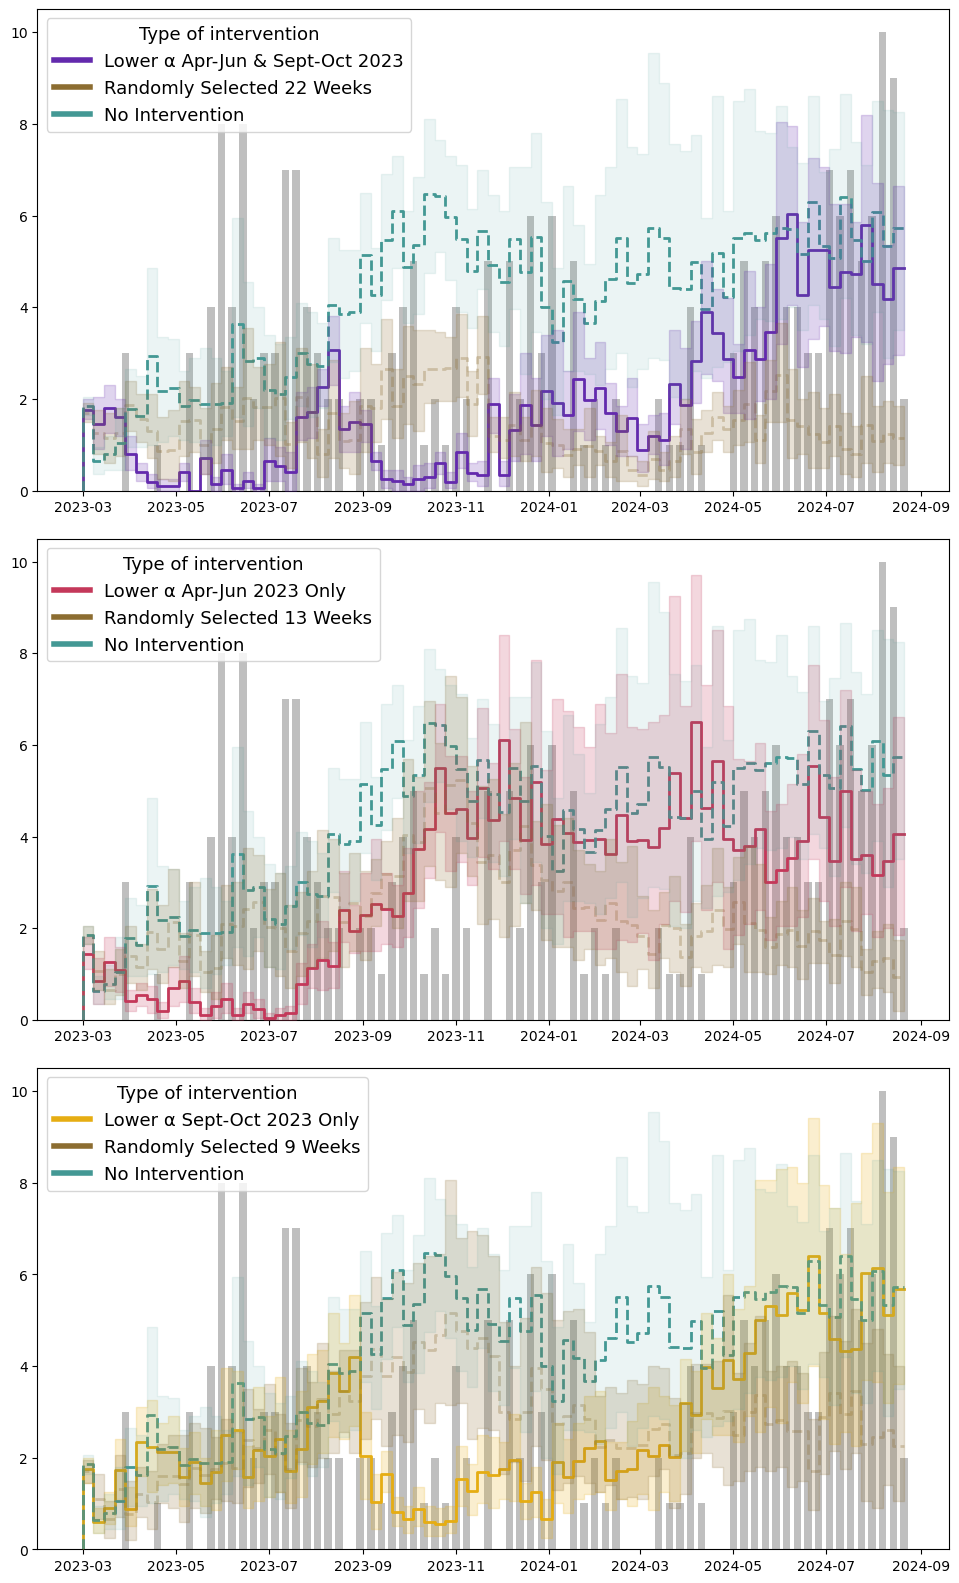

In [16]:
# Below is Figure S9 which highlights the statistical comparison for panel B in the mainfigure 5
fig = plt.figure(figsize=(20,20),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 3, width_ratios = [1, 0.25, 0.25],  hspace=0.1)  # three rows, three column 

# # Add the first subplot 
# ax1 = fig.add_subplot(gs[0])

# sexual_behavior_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S13', 'To.Aware_S12', 'To.Aware_S6'])
# sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)

# sexual_behavior_long.variable[sexual_behavior_long.variable == "Empirical"] = "Empirical"
# sexual_behavior_long.variable[sexual_behavior_long.variable == "To.Aware_S13"] = "0.7"
# sexual_behavior_long.variable[sexual_behavior_long.variable == "To.Aware_S12"] = "1.45"
# sexual_behavior_long.variable[sexual_behavior_long.variable == "To.Aware_S6"] = "2.2"

# #plot empirical cases
# ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

# #plot linegraph of simulated cases
# sns.lineplot(
#     data=sexual_behavior_long[sexual_behavior_long.variable != "Empirical"],
#     x='week_date',
#     y='value',
#     hue='variable',
#     palette='Blues_d',
#     legend= "full", 
#     linewidth = 2,
#     ax = ax1
# )

# #plot scatter points of simulated cases on top of linegraph
# sns.scatterplot(
#     data=sexual_behavior_long[sexual_behavior_long.variable != "Empirical"],
#     x='week_date',
#     y='value',
#     hue = "variable",
#     palette = "Blues_d",
#     s=25,  # Adjust point size
#     marker='o', 
#     legend = None, 
#     ax = ax1
# )

# Add the second subplot for the potential public health interventions based on phylo results
ax2 = fig.add_subplot(gs[0, 0])

colors = sns.color_palette("CMRmap").as_hex()

PH_import_intervention_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S11', 'To.Aware_S15', 'To.Aware_S16','To.Aware_S17', 'To.Aware_S18', 'To.Aware_S19', 'To.Aware_S6'])
PH_import_intervention_long.week_date = pd.to_datetime(PH_import_intervention_long.week_date)

PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower FoI Apr-Jun & Sept-Oct 2023"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S15"] = "Lower FoI Apr-Jun 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S16"] = "Lower FoI Sept-Oct 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S17"] = "Randomly Selected 22 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S18"] = "Randomly Selected 13 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S19"] = "Randomly Selected 9 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S6"] = "No Intervention"


#plot empirical cases
ax2.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_df.week_date, modeling_df["Mean_S11"], color=colors[1],lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S11"], modeling_df["UpperBound_S11"],alpha=0.2, step = "pre", facecolor=colors[1],edgecolor=colors[1],zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["LowerBound_S11"],color=colors[1],lw=1,zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["UpperBound_S11"],color=colors[1],lw=1,zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S17"], color="#8c6d31", alpha = 0.3, ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S17"], modeling_df["UpperBound_S17"],alpha=0.2, step = "pre", facecolor="#8c6d31",edgecolor="#8c6d31",zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)


legend_list = [mlines.Line2D([0], [0], color=colors[1], lw=4, label='Lower α Apr-Jun & Sept-Oct 2023'),
                mlines.Line2D([0], [0], color="#8c6d31", lw=4, label='Randomly Selected 22 Weeks'),
              mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax2.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')


# Add the third subplot 
ax3 = fig.add_subplot(gs[1, 0])

#plot empirical cases
ax3.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

#plot estimates with uncertainty intervals
ax3.step(modeling_df.week_date, modeling_df["Mean_S15"], color=colors[2],lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S15"], modeling_df["UpperBound_S15"],alpha=0.2, step = "pre", facecolor=colors[2],edgecolor=colors[2],zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["LowerBound_S11"],color=colors[1],lw=1,zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["UpperBound_S11"],color=colors[1],lw=1,zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S18"], color="#8c6d31", alpha = 0.3, ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S18"], modeling_df["UpperBound_S18"],alpha=0.2, step = "pre", facecolor="#8c6d31",edgecolor="#8c6d31",zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)


legend_list = [mlines.Line2D([0], [0], color=colors[2], lw=4, label='Lower α Apr-Jun 2023 Only'),
                mlines.Line2D([0], [0], color="#8c6d31", lw=4, label='Randomly Selected 13 Weeks'),
              mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax3.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')


# Add the fourth subplot 
ax4 = fig.add_subplot(gs[2,0])

#plot empirical cases
ax4.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.5, width = 5)

#plot estimates with uncertainty intervals
ax4.step(modeling_df.week_date, modeling_df["Mean_S16"], color=colors[4],lw=2 )
ax4.fill_between(modeling_df.week_date, modeling_df["LowerBound_S16"], modeling_df["UpperBound_S16"],alpha=0.2, step = "pre", facecolor=colors[4],edgecolor=colors[4],zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["LowerBound_S11"],color=colors[1],lw=1,zorder=1000)
# ax2.plot(modeling_df.week_date, modeling_df["UpperBound_S11"],color=colors[1],lw=1,zorder=1000)

ax4.step(modeling_df.week_date, modeling_df["Mean_S19"], color="#8c6d31", alpha = 0.3, ls='--',lw=2 )
ax4.fill_between(modeling_df.week_date, modeling_df["LowerBound_S19"], modeling_df["UpperBound_S19"],alpha=0.2, step = "pre", facecolor="#8c6d31",edgecolor="#8c6d31",zorder=1000)

ax4.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax4.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=colors[4], lw=4, label='Lower α Sept-Oct 2023 Only'),
                mlines.Line2D([0], [0], color="#8c6d31", lw=4, label='Randomly Selected 9 Weeks'),
              mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax4.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')



ax1.legend(title = "Infectivity Scalar α", loc = "upper left")
#ax2.legend(title = "Type of Intervention", loc = "upper left")
ax5.legend(title = "P(Isolation | symptomatic, diagnosed)", loc = "upper left")



# Format the x-axis for dates
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
# ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
#ax1.xticks(rotation=45)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax4.set_ylabel('Diagnosed mpox cases', size = 16)
ax5.set_ylabel('Diagnosed mpox cases', size = 16)
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "B", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 
ax3.text(-0.065, 1, "C", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax4.text(-0.065, 1, "D", transform=ax4.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 
ax5.text(-0.065, 1, "E", transform=ax5.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  

ax5.set_xlabel('')


# Show the plot
plt.tight_layout()
#plt.savefig('../figures/microsim_results_supp.png',dpi=300,bbox_inches='tight')
plt.show()

## now assume that all the introductions are UNdiagnosed when they enter. 

In [49]:
## all the microsimulation results with uncertainty intervals are in seperate folders and files. This function combines all those results
## into a single dataframe. Of note, this specific code snippet was created with help of ChatGPT and 
## edited by Miguel Paredes. The rest of this notebook was written by Miguel. 

# Define the parent folder containing the subfolders
parent_folder = "../data/MonteCarloResults/"

# Initialize an empty list to store the processed DataFrames
dataframes = []

# Loop through each subfolder in the parent folder
for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    # Check if the current path is a folder and matches the pattern "S0" to "S9"
    if os.path.isdir(subfolder_path) and subfolder.startswith("import_undiag"):
        file_path = os.path.join(subfolder_path, "ToAware_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)
            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}",
                "UpperBound": f"UpperBound_{folder_name}",
                "LowerBound": f"LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
    if os.path.isdir(subfolder_path) and subfolder.startswith("import_undiag"):
        file_path = os.path.join(subfolder_path, "ToAwareCum_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Cum_Mean_{folder_name}",
                "UpperBound": f"Cum_UpperBound_{folder_name}",
                "LowerBound": f"Cum_LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)

# Merge all DataFrames on the "Week" column
merged_undx_df = dataframes[0]
for df in dataframes[1:]:
    merged_undx_df = pd.merge(merged_undx_df, df, on="Week")
    
empirical_df = pd.read_csv("../data/microsimulation_results/scenarios_aware.csv")

merged_undx_df = pd.merge(merged_undx_df, empirical_df, left_on = "Week", right_on = "week" )
merged_undx_df.head()

,Week,Mean_S18,LowerBound_S18,UpperBound_S18,Cum_Mean_S18,Cum_LowerBound_S18,Cum_UpperBound_S18,Mean_S20,LowerBound_S20,UpperBound_S20,...,To.Aware_S10,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19
0,0,0.0000,0.0,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,0
1,1,2.6970,2.5,2.90,2.6970,2.50,2.90,2.1928,1.95,2.45,...,2,1,2,2,2,2,2,2,2,2
2,2,1.1884,0.8,1.55,3.8854,3.45,4.35,0.7613,0.40,1.20,...,1,2,0,0,1,1,1,1,1,1
3,3,2.2807,1.6,2.90,6.1661,5.10,7.25,1.6983,1.25,2.15,...,2,1,0,0,1,1,1,0,2,1
4,4,1.0955,0.6,1.55,7.2616,5.80,8.80,0.5470,0.20,1.00,...,3,1,1,0,1,1,1,1,3,1


In [50]:
start_date = datetime(2023, 3, 1)
modeling_undx_df = merged_undx_df.copy()
modeling_undx_df['week_date'] = modeling_undx_df['Week'].apply(lambda x: (start_date + timedelta(weeks=x)).strftime('%Y-%m-%d'))
modeling_undx_df = modeling_undx_df.dropna()
modeling_undx_df.head()

,Week,Mean_S18,LowerBound_S18,UpperBound_S18,Cum_Mean_S18,Cum_LowerBound_S18,Cum_UpperBound_S18,Mean_S20,LowerBound_S20,UpperBound_S20,...,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19,week_date
0,0,0.0000,0.0,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,2023-03-01
1,1,2.6970,2.5,2.90,2.6970,2.50,2.90,2.1928,1.95,2.45,...,1,2,2,2,2,2,2,2,2,2023-03-08
2,2,1.1884,0.8,1.55,3.8854,3.45,4.35,0.7613,0.40,1.20,...,2,0,0,1,1,1,1,1,1,2023-03-15
3,3,2.2807,1.6,2.90,6.1661,5.10,7.25,1.6983,1.25,2.15,...,1,0,0,1,1,1,0,2,1,2023-03-22
4,4,1.0955,0.6,1.55,7.2616,5.80,8.80,0.5470,0.20,1.00,...,1,1,0,1,1,1,1,3,1,2023-03-29


/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/1848608376.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/1848608376.py:257: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


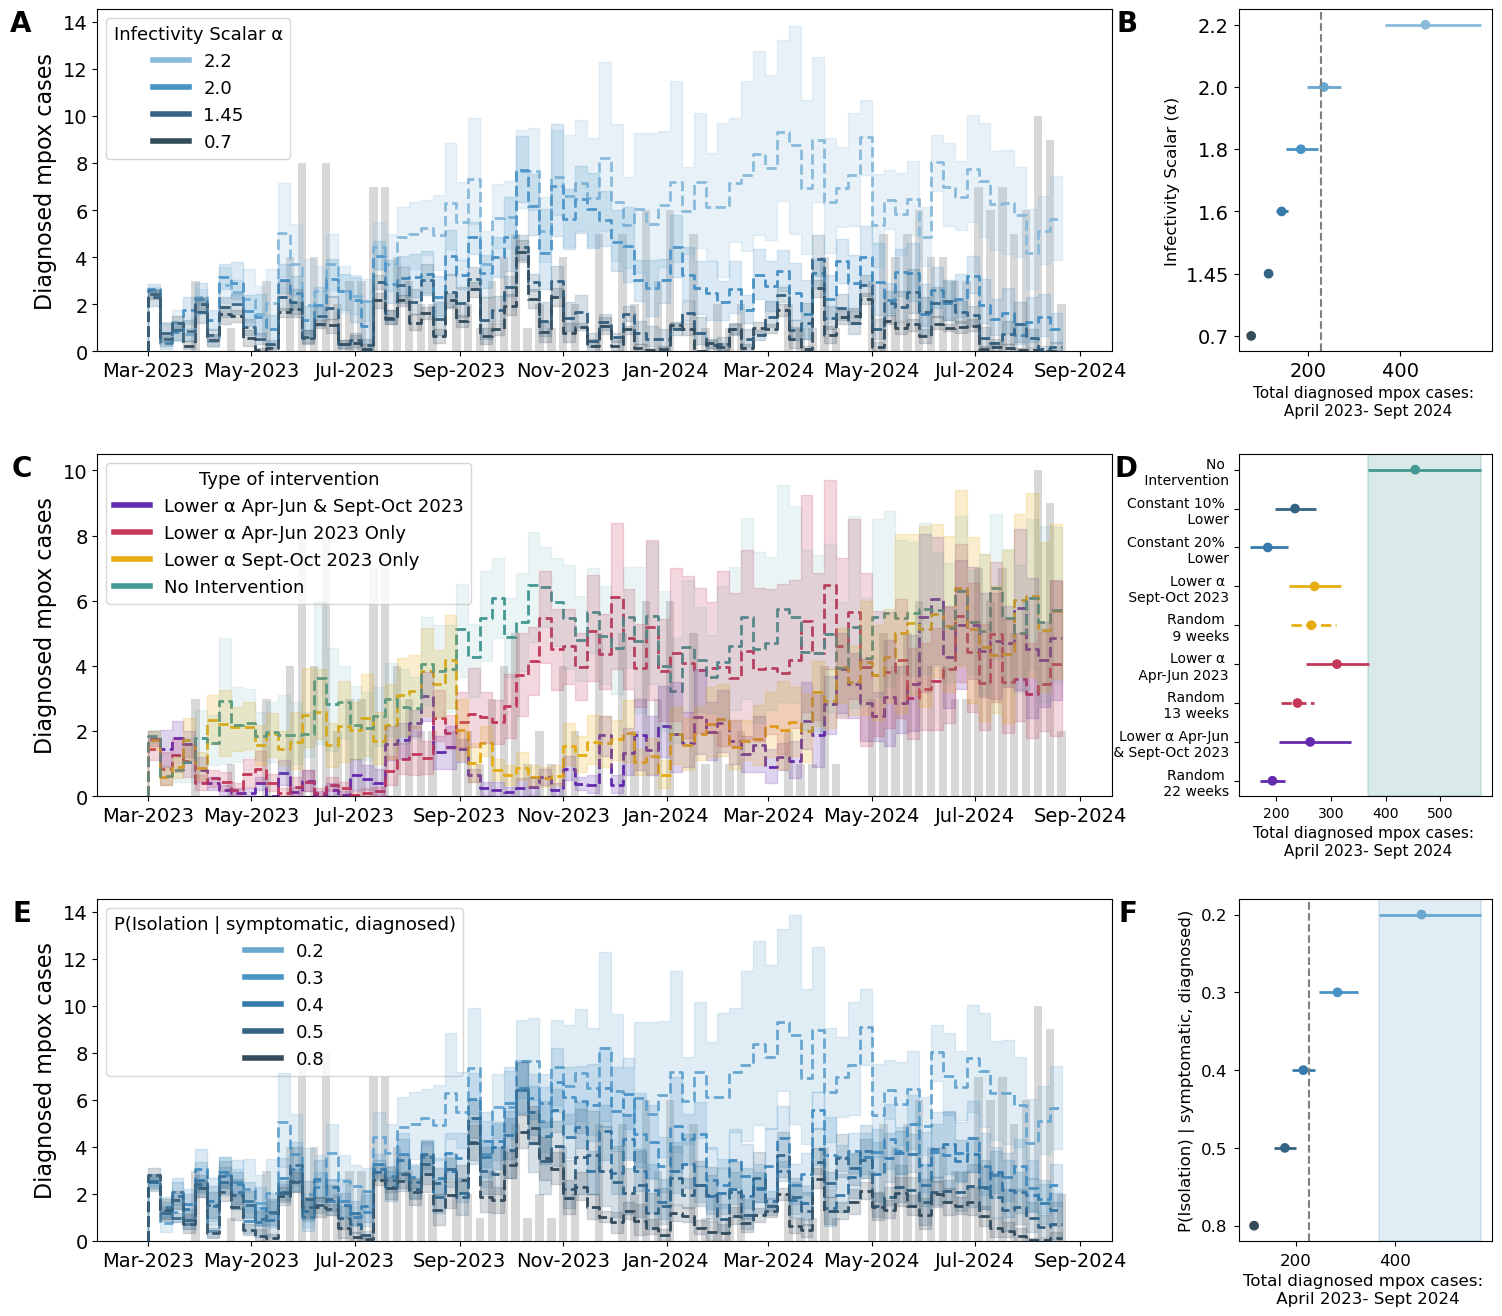

In [51]:
# Plotting α with phylo imports - this is the main figure 5 with the accompanying tornado plots
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()

sexual_behavior_long = pd.melt(modeling_undx_df, id_vars='week_date', value_vars=['Empirical','Mean_S13', 'Mean_S12', 'Mean_S6','LowerBound_S13', 'LowerBound_S12', 'LowerBound_S6','UpperBound_S13', 'UpperBound_S12', 'UpperBound_S6', ])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
modeling_undx_df.week_date = pd.to_datetime(modeling_undx_df.week_date)

#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax1.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S6"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S6"], modeling_undx_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax1.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S22"], color=blues[2],ls='--',lw=2 )
ax1.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S22"], modeling_undx_df["UpperBound_S22"],alpha=0.2, step = "pre",  facecolor=blues[2],edgecolor=blues[2],zorder=1000)


# ax1.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S21"], modeling_undx_df["UpperBound_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


ax1.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S12"], color=blues[4],ls='--',lw=2 )
ax1.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S12"], modeling_undx_df["UpperBound_S12"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)


ax1.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S13"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S13"], modeling_undx_df["UpperBound_S13"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

### add subplot for intervention

ax1_1 = fig.add_subplot(gs[0, 1])

blues = sns.color_palette("Blues_d").as_hex()

infection_scalar_cats = ["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_undx_df["Cum_Mean_S6"].iloc[-1], merged_undx_df["Cum_Mean_S22"].iloc[-1], merged_undx_df["Cum_Mean_S21"].iloc[-1], merged_undx_df["Cum_Mean_S20"].iloc[-1] , merged_undx_df["Cum_Mean_S12"].iloc[-1], merged_undx_df["Cum_Mean_S13"].iloc[-1] ]
values_lb = [ merged_undx_df["Cum_LowerBound_S6"].iloc[-1], merged_undx_df["Cum_LowerBound_S22"].iloc[-1], merged_undx_df["Cum_LowerBound_S21"].iloc[-1], merged_undx_df["Cum_LowerBound_S20"].iloc[-1] , merged_undx_df["Cum_LowerBound_S12"].iloc[-1], merged_undx_df["Cum_LowerBound_S13"].iloc[-1] ]
values_ub = [ merged_undx_df["Cum_UpperBound_S6"].iloc[-1], merged_undx_df["Cum_UpperBound_S22"].iloc[-1], merged_undx_df["Cum_UpperBound_S21"].iloc[-1], merged_undx_df["Cum_UpperBound_S20"].iloc[-1] , merged_undx_df["Cum_UpperBound_S12"].iloc[-1], merged_undx_df["Cum_UpperBound_S13"].iloc[-1] ]
colors = [blues[0], blues[1], blues[2], blues[3],blues[4], blues[5]]

ax1_1.scatter( values, infection_scalar_cats, color = colors)

ax1_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

ax1_1.axvline(x=(merged_undx_df["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax1_1.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

#ax1_1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='lower right')


ax1_1.tick_params(axis='both', which='major', labelsize=14)
ax1_1.tick_params(axis='both', which='minor', labelsize=14)
ax1_1.set_ylabel('Infectivity Scalar (α)', size = 12)
ax1_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)


####
# Add the second subplot for the potential public health interventions based on phylo results
####
####
# Add the second subplot for the potential public health interventions based on phylo results
####
ax2 = fig.add_subplot(gs[1, 0])

colors = sns.color_palette("CMRmap").as_hex()

PH_import_intervention_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S11', 'To.Aware_S15', 'To.Aware_S16','To.Aware_S17', 'To.Aware_S18', 'To.Aware_S19', 'To.Aware_S6'])
PH_import_intervention_long.week_date = pd.to_datetime(PH_import_intervention_long.week_date)
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"

#plot empirical cases
ax2.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_df.week_date, modeling_df["Mean_S11"], color=colors[1],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S11"], modeling_df["UpperBound_S11"],alpha=0.2, step = "pre", facecolor=colors[1],edgecolor=colors[1],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S15"], color=colors[2],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S15"], modeling_df["UpperBound_S15"],alpha=0.2, step = "pre", facecolor=colors[2],edgecolor=colors[2],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S16"], color=colors[4],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S16"], modeling_df["UpperBound_S16"],alpha=0.2, step = "pre", facecolor=colors[4],edgecolor=colors[4],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)

#plot legend
legend_list = [mlines.Line2D([0], [0], color=colors[1], lw=4, label='Lower α Apr-Jun & Sept-Oct 2023'),
               mlines.Line2D([0], [0], color=colors[2], lw=4, label='Lower α Apr-Jun 2023 Only'),
               mlines.Line2D([0], [0], color=colors[4], lw=4, label='Lower α Sept-Oct 2023 Only'),
               mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),
              ]
ax2.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')

###
# add in overall dx cases subplot
###

ax2_1 = fig.add_subplot(gs[1, 1])


c_ramp = sns.color_palette("CMRmap").as_hex()

infection_scalar_cats = ["No \n Intervention", "Constant 10% \n Lower", "Constant 20% \n Lower",  "Lower α \n Sept-Oct 2023", "Random \n 9 weeks", "Lower α \n Apr-Jun 2023", "Random \n 13 weeks", "Lower α Apr-Jun\n & Sept-Oct 2023", "Random \n 22 weeks"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_undx_df["Cum_Mean_S6"].iloc[-1], merged_undx_df["Cum_Mean_S22"].iloc[-1], merged_undx_df["Cum_Mean_S21"].iloc[-1], merged_undx_df["Cum_Mean_S16"].iloc[-1], merged_undx_df["Cum_Mean_S25"].iloc[-1], merged_undx_df["Cum_Mean_S15"].iloc[-1], merged_undx_df["Cum_Mean_S24"].iloc[-1] , merged_undx_df["Cum_Mean_S11"].iloc[-1], merged_undx_df["Cum_Mean_S23"].iloc[-1]]
values_lb = [ merged_undx_df["Cum_LowerBound_S6"].iloc[-1], merged_undx_df["Cum_LowerBound_S22"].iloc[-1], merged_undx_df["Cum_LowerBound_S21"].iloc[-1], merged_undx_df["Cum_LowerBound_S16"].iloc[-1], merged_undx_df["Cum_LowerBound_S25"].iloc[-1], merged_undx_df["Cum_LowerBound_S15"].iloc[-1], merged_undx_df["Cum_LowerBound_S24"].iloc[-1] , merged_undx_df["Cum_LowerBound_S11"].iloc[-1], merged_undx_df["Cum_LowerBound_S23"].iloc[-1] ]
values_ub = [merged_undx_df["Cum_UpperBound_S6"].iloc[-1], merged_undx_df["Cum_UpperBound_S22"].iloc[-1], merged_undx_df["Cum_UpperBound_S21"].iloc[-1], merged_undx_df["Cum_UpperBound_S16"].iloc[-1], merged_undx_df["Cum_UpperBound_S25"].iloc[-1], merged_undx_df["Cum_UpperBound_S15"].iloc[-1], merged_undx_df["Cum_UpperBound_S24"].iloc[-1] , merged_undx_df["Cum_UpperBound_S11"].iloc[-1], merged_undx_df["Cum_UpperBound_S23"].iloc[-1] ]
colors = ["#439894", blues[4], blues[3], c_ramp[4], c_ramp[4], c_ramp[2], c_ramp[2],c_ramp[1], c_ramp[1]]
styles = ["solid", "solid","solid", "solid",  '--', "solid", '--', "solid", '--']
ax2_1.scatter( values, infection_scalar_cats, color = colors)

ax2_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

#ax2_1.axvline(x=(merged_undx_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

ax2_1.axvspan(merged_undx_df["Cum_LowerBound_S6"].iloc[-1], merged_undx_df["Cum_UpperBound_S6"].iloc[-1], color="#439894", alpha = 0.2, linewidth=1.5)

ax2_1.invert_yaxis()
ax2_1.tick_params(axis='both', which='major', labelsize=10)
ax2_1.tick_params(axis='both', which='minor', labelsize=10)
ax2_1.set_ylabel('')
ax2_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)


###
# Add the third main plot regarding P(isolation | symptomatic, diagnosed)
###
ax3 = fig.add_subplot(gs[2, 0])

long_prop_iso_df = pd.melt(modeling_undx_df, id_vars='week_date', value_vars=["Empirical", 'To.Aware_S6', 'To.Aware_S5', "To.Aware_S4", "To.Aware_S3", "To.Aware_S14"])
long_prop_iso_df.week_date = pd.to_datetime(long_prop_iso_df.week_date)

#plot empirical cases
ax3.bar(long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].week_date ,long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax3.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S6"], color=blues[1],ls='--',lw=2 )
ax3.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S6"], modeling_undx_df["UpperBound_S6"],alpha=0.2, step = "pre", facecolor=blues[1],edgecolor=blues[1],zorder=1000)

ax3.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S5"], color=blues[2],ls='--',lw=2 )
ax3.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S5"], modeling_undx_df["UpperBound_S5"],alpha=0.2, step = "pre", facecolor=blues[2],edgecolor=blues[2],zorder=1000)

ax3.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S4"], color=blues[3],ls='--',lw=2 )
ax3.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S4"], modeling_undx_df["UpperBound_S4"],alpha=0.20, step = "pre", facecolor=blues[3],edgecolor=blues[3],zorder=1000)

ax3.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S3"], color=blues[4],ls='--',lw=2 )
ax3.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S3"], modeling_undx_df["UpperBound_S3"],alpha=0.20, step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)

ax3.step(modeling_undx_df.week_date, modeling_undx_df["Mean_S14"], color=blues[5],ls='--',lw=2 )
ax3.fill_between(modeling_undx_df.week_date, modeling_undx_df["LowerBound_S14"], modeling_undx_df["UpperBound_S14"],alpha=0.20, step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

## add legend
legend_list = [mlines.Line2D([0], [0], color=blues[1], lw=4, label='0.2'),
                mlines.Line2D([0], [0], color=blues[2], lw=4, label='0.3'),
                mlines.Line2D([0], [0], color=blues[3], lw=4, label='0.4'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='0.5'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.8'),]
ax3.legend(handles=legend_list, title='P(Isolation | symptomatic, diagnosed)', fontsize=13, title_fontsize=13, loc='upper left')

###
# add third subplot
###

ax3_1 = fig.add_subplot(gs[2, 1])

# define colors
blues = sns.color_palette("Blues_d").as_hex()

# definte data to plot
infection_scalar_cats = ["0.2", "0.3", "0.4", "0.5", "0.8"]

values = [ merged_undx_df["Cum_Mean_S6"].iloc[-1], merged_undx_df["Cum_Mean_S5"].iloc[-1], merged_undx_df["Cum_Mean_S4"].iloc[-1], merged_undx_df["Cum_Mean_S3"].iloc[-1] , merged_undx_df["Cum_Mean_S14"].iloc[-1] ]
values_lb = [ merged_undx_df["Cum_LowerBound_S6"].iloc[-1], merged_undx_df["Cum_LowerBound_S5"].iloc[-1], merged_undx_df["Cum_LowerBound_S4"].iloc[-1], merged_undx_df["Cum_LowerBound_S3"].iloc[-1] , merged_undx_df["Cum_LowerBound_S14"].iloc[-1] ]
values_ub = [ merged_undx_df["Cum_UpperBound_S6"].iloc[-1], merged_undx_df["Cum_UpperBound_S5"].iloc[-1], merged_undx_df["Cum_UpperBound_S4"].iloc[-1], merged_undx_df["Cum_UpperBound_S3"].iloc[-1] , merged_undx_df["Cum_UpperBound_S14"].iloc[-1]]
colors = [blues[1], blues[2], blues[3], blues[4],blues[5]]

# plot!
ax3_1.scatter( values, infection_scalar_cats, color = colors)

ax3_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

ax3_1.axvline(x=(merged_undx_df["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax3_1.axvspan(merged_undx_df["Cum_LowerBound_S6"].iloc[-1], merged_undx_df["Cum_UpperBound_S6"].iloc[-1], color=blues[1], alpha = 0.2, linewidth=1.5)


ax3_1.invert_yaxis()
ax3_1.tick_params(axis='both', which='major', labelsize=12, pad =5)
ax3_1.tick_params(axis='both', which='minor', labelsize=12)
ax3_1.set_ylabel('P(Isolation) | symptomatic, diagnosed)', size = 12)
ax3_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 12)


##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_xlabel('')
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.tick_params(axis='both', which='minor', labelsize=14)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_xlabel('')
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3.text(-0.065, 1, "E", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3_1.text(-0.4, 1, "F", transform=ax3_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 

# Show the plot
plt.tight_layout()
plt.savefig('../figures/microsim_results_import_undiag.png',dpi=300,bbox_inches='tight')
plt.show()

## now assume that all the introductions are asymptomatic when they come in

In [52]:
## all the microsimulation results with uncertainty intervals are in seperate folders and files. This function combines all those results
## into a single dataframe. Of note, this specific code snippet was created with help of ChatGPT and 
## edited by Miguel Paredes. The rest of this notebook was written by Miguel. 

# Define the parent folder containing the subfolders
parent_folder = "../data/MonteCarloResults/"

# Initialize an empty list to store the processed DataFrames
dataframes = []

# Loop through each subfolder in the parent folder
for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    # Check if the current path is a folder and matches the pattern "S0" to "S9"
    if os.path.isdir(subfolder_path) and subfolder.startswith("import_asymp"):
        file_path = os.path.join(subfolder_path, "ToAware_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)
            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}",
                "UpperBound": f"UpperBound_{folder_name}",
                "LowerBound": f"LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
            
    if os.path.isdir(subfolder_path) and subfolder.startswith("import_asymp"):
        file_path = os.path.join(subfolder_path, "ToAwareCum_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Cum_Mean_{folder_name}",
                "UpperBound": f"Cum_UpperBound_{folder_name}",
                "LowerBound": f"Cum_LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)

    

# Merge all DataFrames on the "Week" column
merged_asymp_df = dataframes[0]
for df in dataframes[1:]:
    merged_asymp_df = pd.merge(merged_asymp_df, df, on="Week")
    
empirical_df = pd.read_csv("../data/microsimulation_results/scenarios_aware.csv")

merged_asymp_df = pd.merge(merged_asymp_df, empirical_df, left_on = "Week", right_on = "week" )
merged_asymp_df.head()

,Week,Mean_S2,LowerBound_S2,UpperBound_S2,Cum_Mean_S2,Cum_LowerBound_S2,Cum_UpperBound_S2,Mean_S5,LowerBound_S5,UpperBound_S5,...,To.Aware_S10,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19
0,0,0.0000,0.00,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,0
1,1,1.6601,1.45,1.85,1.6601,1.45,1.85,1.3925,0.95,1.80,...,2,1,2,2,2,2,2,2,2,2
2,2,1.0005,0.60,1.40,2.6606,2.15,3.15,1.4144,1.00,1.90,...,1,2,0,0,1,1,1,1,1,1
3,3,1.1430,0.60,1.70,3.8036,3.25,4.40,0.9384,0.65,1.30,...,2,1,0,0,1,1,1,0,2,1
4,4,1.3084,0.75,1.85,5.1120,4.30,5.90,1.4890,1.25,1.75,...,3,1,1,0,1,1,1,1,3,1


In [53]:
start_date = datetime(2023, 3, 1)
modeling_asymp_df = merged_asymp_df.copy()
modeling_asymp_df['week_date'] = modeling_asymp_df['Week'].apply(lambda x: (start_date + timedelta(weeks=x)).strftime('%Y-%m-%d'))
modeling_asymp_df = modeling_asymp_df.dropna()
modeling_asymp_df.head()

,Week,Mean_S2,LowerBound_S2,UpperBound_S2,Cum_Mean_S2,Cum_LowerBound_S2,Cum_UpperBound_S2,Mean_S5,LowerBound_S5,UpperBound_S5,...,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19,week_date
0,0,0.0000,0.00,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,2023-03-01
1,1,1.6601,1.45,1.85,1.6601,1.45,1.85,1.3925,0.95,1.80,...,1,2,2,2,2,2,2,2,2,2023-03-08
2,2,1.0005,0.60,1.40,2.6606,2.15,3.15,1.4144,1.00,1.90,...,2,0,0,1,1,1,1,1,1,2023-03-15
3,3,1.1430,0.60,1.70,3.8036,3.25,4.40,0.9384,0.65,1.30,...,1,0,0,1,1,1,0,2,1,2023-03-22
4,4,1.3084,0.75,1.85,5.1120,4.30,5.90,1.4890,1.25,1.75,...,1,1,0,1,1,1,1,3,1,2023-03-29


/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/37594858.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/37594858.py:260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


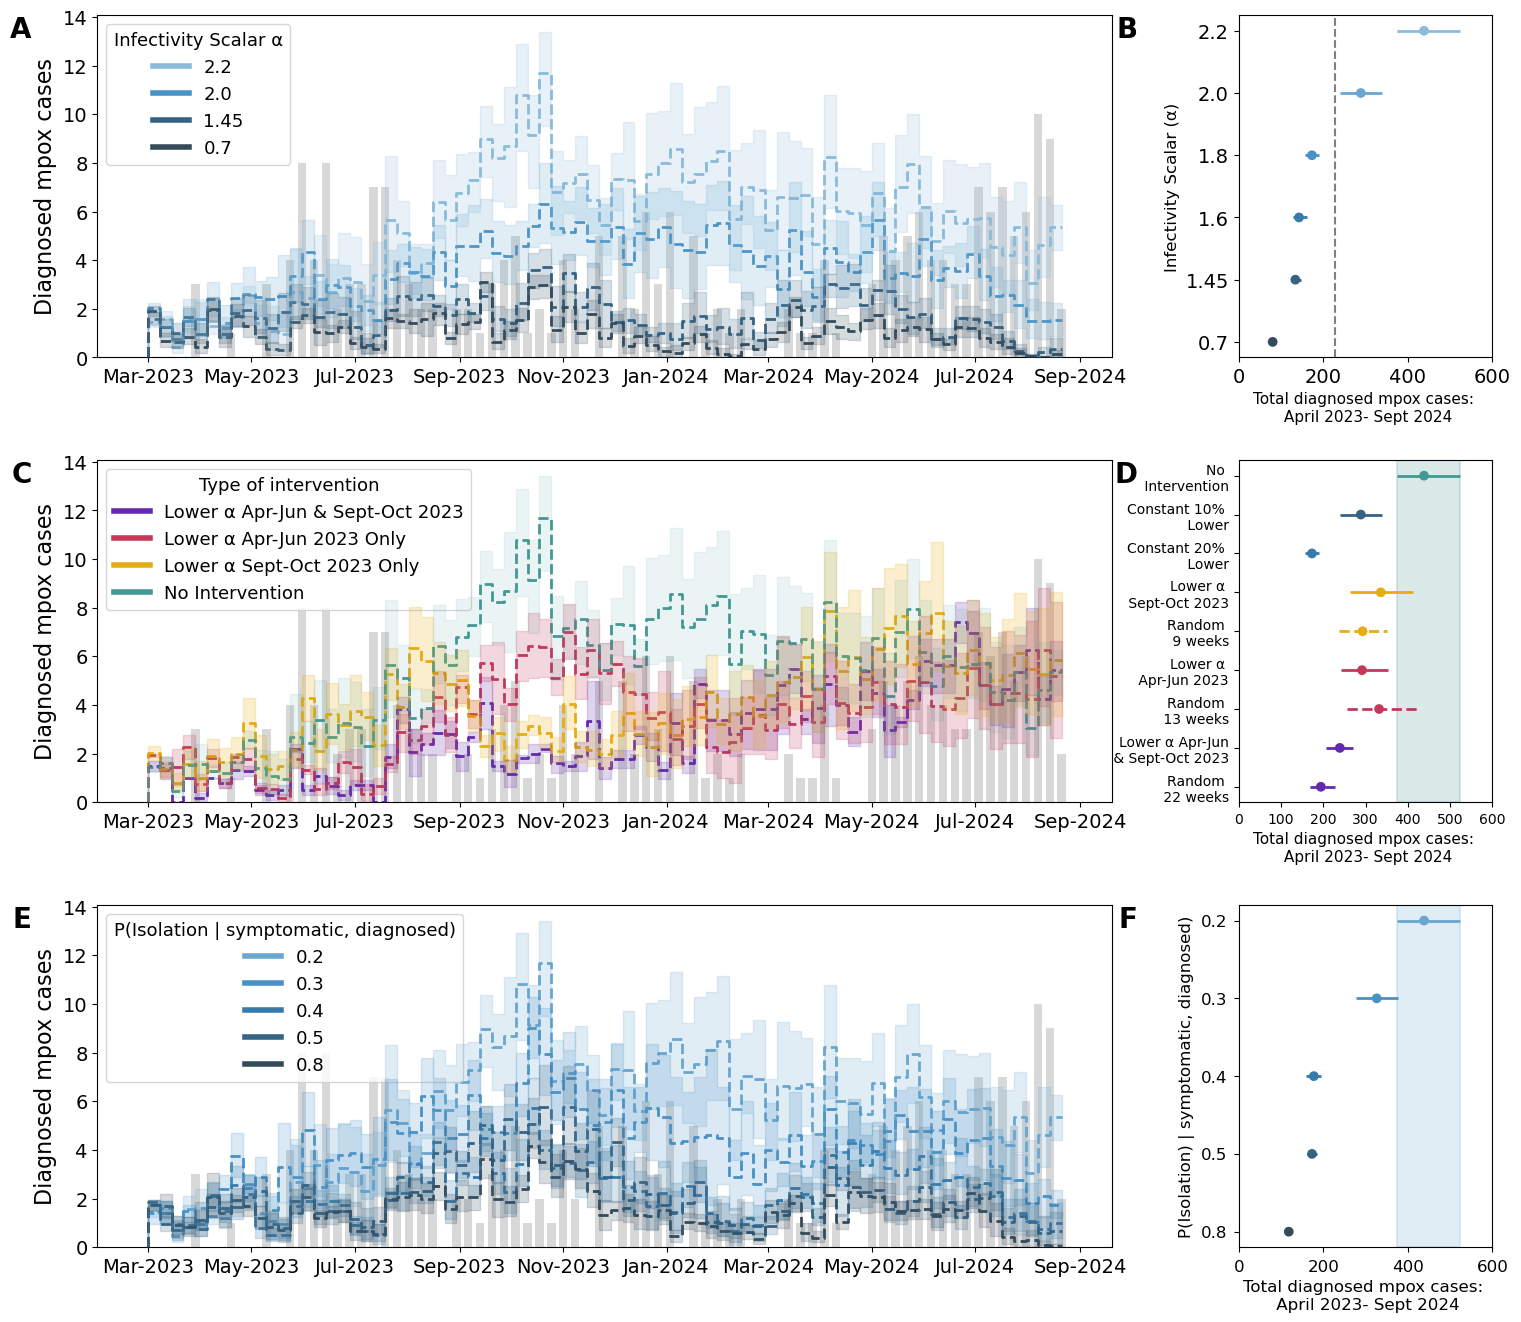

In [56]:
# Plotting α with phylo imports - this is the main figure 5 with the accompanying tornado plots
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()

sexual_behavior_long = pd.melt(modeling_asymp_df, id_vars='week_date', value_vars=['Empirical','Mean_S13', 'Mean_S12', 'Mean_S6','LowerBound_S13', 'LowerBound_S12', 'LowerBound_S6','UpperBound_S13', 'UpperBound_S12', 'UpperBound_S6', ])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
modeling_asymp_df.week_date = pd.to_datetime(modeling_asymp_df.week_date)

#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax1.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S6"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S6"], modeling_asymp_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax1.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S22"], color=blues[2],ls='--',lw=2 )
ax1.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S22"], modeling_asymp_df["UpperBound_S22"],alpha=0.2, step = "pre",  facecolor=blues[1],edgecolor=blues[1],zorder=1000)


# ax1.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S21"], modeling_asymp_df["UpperBound_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


ax1.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S12"], color=blues[4],ls='--',lw=2 )
ax1.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S12"], modeling_asymp_df["UpperBound_S12"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)


ax1.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S13"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S13"], modeling_asymp_df["UpperBound_S13"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

### add subplot for intervention

ax1_1 = fig.add_subplot(gs[0, 1])

blues = sns.color_palette("Blues_d").as_hex()

infection_scalar_cats = ["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_asymp_df["Cum_Mean_S6"].iloc[-1], merged_asymp_df["Cum_Mean_S22"].iloc[-1], merged_asymp_df["Cum_Mean_S21"].iloc[-1], merged_asymp_df["Cum_Mean_S20"].iloc[-1] , merged_asymp_df["Cum_Mean_S12"].iloc[-1], merged_asymp_df["Cum_Mean_S13"].iloc[-1] ]
values_lb = [ merged_asymp_df["Cum_LowerBound_S6"].iloc[-1], merged_asymp_df["Cum_LowerBound_S22"].iloc[-1], merged_asymp_df["Cum_LowerBound_S21"].iloc[-1], merged_asymp_df["Cum_LowerBound_S20"].iloc[-1] , merged_asymp_df["Cum_LowerBound_S12"].iloc[-1], merged_asymp_df["Cum_LowerBound_S13"].iloc[-1] ]
values_ub = [ merged_asymp_df["Cum_UpperBound_S6"].iloc[-1], merged_asymp_df["Cum_UpperBound_S22"].iloc[-1], merged_asymp_df["Cum_UpperBound_S21"].iloc[-1], merged_asymp_df["Cum_UpperBound_S20"].iloc[-1] , merged_asymp_df["Cum_UpperBound_S12"].iloc[-1], merged_asymp_df["Cum_UpperBound_S13"].iloc[-1] ]
colors = [blues[0], blues[1], blues[2], blues[3],blues[4], blues[5]]

ax1_1.scatter( values, infection_scalar_cats, color = colors)

ax1_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

ax1_1.axvline(x=(merged_asymp_df["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax1_1.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

#ax1_1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='lower right')


ax1_1.tick_params(axis='both', which='major', labelsize=14)
ax1_1.tick_params(axis='both', which='minor', labelsize=14)
ax1_1.set_ylabel('Infectivity Scalar (α)', size = 12)
ax1_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)
ax1_1.set_xlim(0, 600)


####
# Add the second subplot for the potential public health interventions based on phylo results
####
####
# Add the second subplot for the potential public health interventions based on phylo results
####
ax2 = fig.add_subplot(gs[1, 0])

colors = sns.color_palette("CMRmap").as_hex()

PH_import_intervention_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S11', 'To.Aware_S15', 'To.Aware_S16','To.Aware_S17', 'To.Aware_S18', 'To.Aware_S19', 'To.Aware_S6'])
PH_import_intervention_long.week_date = pd.to_datetime(PH_import_intervention_long.week_date)
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"

#plot empirical cases
ax2.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S11"], color=colors[1],ls='--',lw=2 )
ax2.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S11"], modeling_asymp_df["UpperBound_S11"],alpha=0.2, step = "pre", facecolor=colors[1],edgecolor=colors[1],zorder=1000)

ax2.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S15"], color=colors[2],ls='--',lw=2 )
ax2.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S15"], modeling_asymp_df["UpperBound_S15"],alpha=0.2, step = "pre", facecolor=colors[2],edgecolor=colors[2],zorder=1000)

ax2.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S16"], color=colors[4],ls='--',lw=2 )
ax2.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S16"], modeling_asymp_df["UpperBound_S16"],alpha=0.2, step = "pre", facecolor=colors[4],edgecolor=colors[4],zorder=1000)

ax2.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax2.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S6"], modeling_asymp_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)

#plot legend
legend_list = [mlines.Line2D([0], [0], color=colors[1], lw=4, label='Lower α Apr-Jun & Sept-Oct 2023'),
               mlines.Line2D([0], [0], color=colors[2], lw=4, label='Lower α Apr-Jun 2023 Only'),
               mlines.Line2D([0], [0], color=colors[4], lw=4, label='Lower α Sept-Oct 2023 Only'),
               mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),
              ]
ax2.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')

###
# add in overall dx cases subplot
###

ax2_1 = fig.add_subplot(gs[1, 1])


c_ramp = sns.color_palette("CMRmap").as_hex()

infection_scalar_cats = ["No \n Intervention", "Constant 10% \n Lower", "Constant 20% \n Lower",  "Lower α \n Sept-Oct 2023", "Random \n 9 weeks", "Lower α \n Apr-Jun 2023", "Random \n 13 weeks", "Lower α Apr-Jun\n & Sept-Oct 2023", "Random \n 22 weeks"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_asymp_df["Cum_Mean_S6"].iloc[-1], merged_asymp_df["Cum_Mean_S22"].iloc[-1], merged_asymp_df["Cum_Mean_S21"].iloc[-1], merged_asymp_df["Cum_Mean_S16"].iloc[-1], merged_asymp_df["Cum_Mean_S25"].iloc[-1], merged_asymp_df["Cum_Mean_S15"].iloc[-1], merged_asymp_df["Cum_Mean_S24"].iloc[-1] , merged_asymp_df["Cum_Mean_S11"].iloc[-1], merged_asymp_df["Cum_Mean_S23"].iloc[-1]]
values_lb = [ merged_asymp_df["Cum_LowerBound_S6"].iloc[-1], merged_asymp_df["Cum_LowerBound_S22"].iloc[-1], merged_asymp_df["Cum_LowerBound_S21"].iloc[-1], merged_asymp_df["Cum_LowerBound_S16"].iloc[-1], merged_asymp_df["Cum_LowerBound_S25"].iloc[-1], merged_asymp_df["Cum_LowerBound_S15"].iloc[-1], merged_asymp_df["Cum_LowerBound_S24"].iloc[-1] , merged_asymp_df["Cum_LowerBound_S11"].iloc[-1], merged_asymp_df["Cum_LowerBound_S23"].iloc[-1] ]
values_ub = [merged_asymp_df["Cum_UpperBound_S6"].iloc[-1], merged_asymp_df["Cum_UpperBound_S22"].iloc[-1], merged_asymp_df["Cum_UpperBound_S21"].iloc[-1], merged_asymp_df["Cum_UpperBound_S16"].iloc[-1], merged_asymp_df["Cum_UpperBound_S25"].iloc[-1], merged_asymp_df["Cum_UpperBound_S15"].iloc[-1], merged_asymp_df["Cum_UpperBound_S24"].iloc[-1] , merged_asymp_df["Cum_UpperBound_S11"].iloc[-1], merged_asymp_df["Cum_UpperBound_S23"].iloc[-1] ]
colors = ["#439894", blues[4], blues[3], c_ramp[4], c_ramp[4], c_ramp[2], c_ramp[2],c_ramp[1], c_ramp[1]]
styles = ["solid", "solid","solid", "solid",  '--', "solid", '--', "solid", '--']
ax2_1.scatter( values, infection_scalar_cats, color = colors)

ax2_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

#ax2_1.axvline(x=(merged_asymp_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

ax2_1.axvspan(merged_asymp_df["Cum_LowerBound_S6"].iloc[-1], merged_asymp_df["Cum_UpperBound_S6"].iloc[-1], color="#439894", alpha = 0.2, linewidth=1.5)

ax2_1.invert_yaxis()
ax2_1.tick_params(axis='both', which='major', labelsize=10)
ax2_1.tick_params(axis='both', which='minor', labelsize=10)
ax2_1.set_ylabel('')
ax2_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)
ax2_1.set_xlim(0, 600)


###
# Add the third main plot regarding P(isolation | symptomatic, diagnosed)
###
ax3 = fig.add_subplot(gs[2, 0])

long_prop_iso_df = pd.melt(modeling_asymp_df, id_vars='week_date', value_vars=["Empirical", 'To.Aware_S6', 'To.Aware_S5', "To.Aware_S4", "To.Aware_S3", "To.Aware_S14"])
long_prop_iso_df.week_date = pd.to_datetime(long_prop_iso_df.week_date)

#plot empirical cases
ax3.bar(long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].week_date ,long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax3.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S6"], color=blues[1],ls='--',lw=2 )
ax3.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S6"], modeling_asymp_df["UpperBound_S6"],alpha=0.2, step = "pre", facecolor=blues[1],edgecolor=blues[1],zorder=1000)

ax3.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S5"], color=blues[2],ls='--',lw=2 )
ax3.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S5"], modeling_asymp_df["UpperBound_S5"],alpha=0.2, step = "pre", facecolor=blues[2],edgecolor=blues[2],zorder=1000)

ax3.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S4"], color=blues[3],ls='--',lw=2 )
ax3.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S4"], modeling_asymp_df["UpperBound_S4"],alpha=0.20, step = "pre", facecolor=blues[3],edgecolor=blues[3],zorder=1000)

ax3.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S3"], color=blues[4],ls='--',lw=2 )
ax3.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S3"], modeling_asymp_df["UpperBound_S3"],alpha=0.20, step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)

ax3.step(modeling_asymp_df.week_date, modeling_asymp_df["Mean_S14"], color=blues[5],ls='--',lw=2 )
ax3.fill_between(modeling_asymp_df.week_date, modeling_asymp_df["LowerBound_S14"], modeling_asymp_df["UpperBound_S14"],alpha=0.20, step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

## add legend
legend_list = [mlines.Line2D([0], [0], color=blues[1], lw=4, label='0.2'),
                mlines.Line2D([0], [0], color=blues[2], lw=4, label='0.3'),
                mlines.Line2D([0], [0], color=blues[3], lw=4, label='0.4'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='0.5'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.8'),]
ax3.legend(handles=legend_list, title='P(Isolation | symptomatic, diagnosed)', fontsize=13, title_fontsize=13, loc='upper left')

###
# add third subplot
###

ax3_1 = fig.add_subplot(gs[2, 1])

# define colors
blues = sns.color_palette("Blues_d").as_hex()

# definte data to plot
infection_scalar_cats = ["0.2", "0.3", "0.4", "0.5", "0.8"]

values = [ merged_asymp_df["Cum_Mean_S6"].iloc[-1], merged_asymp_df["Cum_Mean_S5"].iloc[-1], merged_asymp_df["Cum_Mean_S4"].iloc[-1], merged_asymp_df["Cum_Mean_S3"].iloc[-1] , merged_asymp_df["Cum_Mean_S14"].iloc[-1] ]
values_lb = [ merged_asymp_df["Cum_LowerBound_S6"].iloc[-1], merged_asymp_df["Cum_LowerBound_S5"].iloc[-1], merged_asymp_df["Cum_LowerBound_S4"].iloc[-1], merged_asymp_df["Cum_LowerBound_S3"].iloc[-1] , merged_asymp_df["Cum_LowerBound_S14"].iloc[-1] ]
values_ub = [ merged_asymp_df["Cum_UpperBound_S6"].iloc[-1], merged_asymp_df["Cum_UpperBound_S5"].iloc[-1], merged_asymp_df["Cum_UpperBound_S4"].iloc[-1], merged_asymp_df["Cum_UpperBound_S3"].iloc[-1] , merged_asymp_df["Cum_UpperBound_S14"].iloc[-1]]
colors = [blues[1], blues[2], blues[3], blues[4],blues[5]]

# plot!
ax3_1.scatter( values, infection_scalar_cats, color = colors)

ax3_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

#ax3_1.axvline(x=(merged_asymp_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

ax3_1.axvspan(merged_asymp_df["Cum_LowerBound_S6"].iloc[-1], merged_asymp_df["Cum_UpperBound_S6"].iloc[-1], color=blues[1], alpha = 0.2, linewidth=1.5)


ax3_1.invert_yaxis()
ax3_1.tick_params(axis='both', which='major', labelsize=12, pad =5)
ax3_1.tick_params(axis='both', which='minor', labelsize=12)
ax3_1.set_ylabel('P(Isolation) | symptomatic, diagnosed)', size = 12)
ax3_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 12)
ax3_1.set_xlim(0, 600)


##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_xlabel('')
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.tick_params(axis='both', which='minor', labelsize=14)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_xlabel('')
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3.text(-0.065, 1, "E", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3_1.text(-0.4, 1, "F", transform=ax3_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 

# Show the plot
plt.tight_layout()
plt.savefig('../figures/microsim_results_import_asymp.png',dpi=300,bbox_inches='tight')
plt.show()

### Supp Fig 13 now plotting sensitivity analysis assuming 2X importations

In [58]:
## all the microsimulation results with uncertainty intervals are in seperate folders and files. This function combines all those results
## into a single dataframe. Of note, this specific code snippet was created with help of ChatGPT and 
## edited by Miguel Paredes. The rest of this notebook was written by Miguel. 

# Define the parent folder containing the subfolders
parent_folder = "../data/MonteCarloResults/"

# Initialize an empty list to store the processed DataFrames
dataframes = []

# Loop through each subfolder in the parent folder
for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    # Check if the current path is a folder and matches the pattern "S0" to "S9"
    if os.path.isdir(subfolder_path) and subfolder.startswith("2Xnew"):
        file_path = os.path.join(subfolder_path, "ToAware_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)
            # Rename columns to include the folder name
            folder_name =   subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}",
                "UpperBound": f"UpperBound_{folder_name}",
                "LowerBound": f"LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
            
    if os.path.isdir(subfolder_path) and subfolder.startswith("2Xnew"):
        file_path = os.path.join(subfolder_path, "ToAwareCum_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Cum_Mean_{folder_name}",
                "UpperBound": f"Cum_UpperBound_{folder_name}",
                "LowerBound": f"Cum_LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)

    

# Merge all DataFrames on the "Week" column
combined_df = dataframes[0]
for df in dataframes[1:]:
    combined_df = pd.merge(combined_df, df, on="Week")
    
empirical_df = pd.read_csv("../data/microsimulation_results/scenarios_aware.csv")

merged_df_2x = pd.merge(combined_df, empirical_df, left_on = "Week", right_on = "week" )
merged_df_2x.head()

,Week,Mean_S1,LowerBound_S1,UpperBound_S1,Cum_Mean_S1,Cum_LowerBound_S1,Cum_UpperBound_S1,Mean_S6,LowerBound_S6,UpperBound_S6,...,To.Aware_S10,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19
0,0,0.0000,0.00,0.00,0.0000,0.00,0.0,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,0
1,1,1.6506,1.45,1.90,1.6506,1.45,1.9,1.9029,1.65,2.15,...,2,1,2,2,2,2,2,2,2,2
2,2,0.5085,0.15,0.90,2.1591,1.65,2.7,0.9835,0.55,1.50,...,1,2,0,0,1,1,1,1,1,1
3,3,0.2489,0.05,0.45,2.4080,1.85,3.0,1.8879,1.20,2.55,...,2,1,0,0,1,1,1,0,2,1
4,4,0.0994,0.00,0.25,2.5074,1.95,3.1,1.7444,1.10,2.45,...,3,1,1,0,1,1,1,1,3,1


In [59]:
# format dates from the sims
start_date = datetime(2023, 3, 1)
merged_df_2x['week_date'] = merged_df_2x['week'].apply(lambda x: (start_date + timedelta(weeks=x)).strftime('%Y-%m-%d'))
merged_df_2x = merged_df_2x.dropna()
merged_df_2x.head()

,Week,Mean_S1,LowerBound_S1,UpperBound_S1,Cum_Mean_S1,Cum_LowerBound_S1,Cum_UpperBound_S1,Mean_S6,LowerBound_S6,UpperBound_S6,...,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19,week_date
0,0,0.0000,0.00,0.00,0.0000,0.00,0.0,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,2023-03-01
1,1,1.6506,1.45,1.90,1.6506,1.45,1.9,1.9029,1.65,2.15,...,1,2,2,2,2,2,2,2,2,2023-03-08
2,2,0.5085,0.15,0.90,2.1591,1.65,2.7,0.9835,0.55,1.50,...,2,0,0,1,1,1,1,1,1,2023-03-15
3,3,0.2489,0.05,0.45,2.4080,1.85,3.0,1.8879,1.20,2.55,...,1,0,0,1,1,1,0,2,1,2023-03-22
4,4,0.0994,0.00,0.25,2.5074,1.95,3.1,1.7444,1.10,2.45,...,1,1,0,1,1,1,1,3,1,2023-03-29


/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/3925630424.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


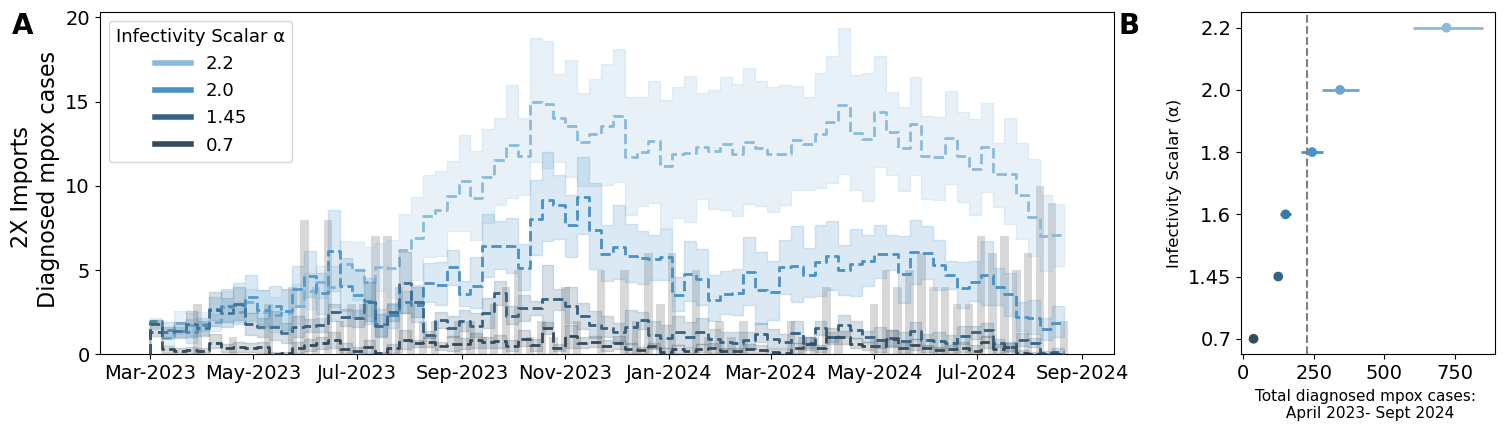

In [60]:
# Plotting α with phylo imports - this is the main figure 5 with the accompanying tornado plots
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()


modeling_2x_df = merged_df_2x.copy()
modeling_2x_df.week_date = pd.to_datetime(modeling_2x_df.week_date)
sexual_behavior_long = pd.melt(modeling_2x_df, id_vars='week_date', value_vars=['Empirical'])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)


#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax1.step(modeling_2x_df.week_date, modeling_2x_df["Mean_S6"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_2x_df.week_date, modeling_2x_df["LowerBound_S6"], modeling_2x_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax1.step(modeling_2x_df.week_date, modeling_2x_df["Mean_S22"], color=blues[2],ls='--',lw=2 )
ax1.fill_between(modeling_2x_df.week_date, modeling_2x_df["LowerBound_S22"], modeling_2x_df["UpperBound_S22"],alpha=0.2, step = "pre",  facecolor=blues[2],edgecolor=blues[2],zorder=1000)


# ax1.step(modeling_2x_df.week_date, modeling_2x_df["Mean_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_2x_df.week_date, modeling_2x_df["LowerBound_S21"], modeling_2x_df["UpperBound_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


ax1.step(modeling_2x_df.week_date, modeling_2x_df["Mean_S12"], color=blues[4],ls='--',lw=2 )
ax1.fill_between(modeling_2x_df.week_date, modeling_2x_df["LowerBound_S12"], modeling_2x_df["UpperBound_S12"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)


ax1.step(modeling_2x_df.week_date, modeling_2x_df["Mean_S13"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_2x_df.week_date, modeling_2x_df["LowerBound_S13"], modeling_2x_df["UpperBound_S13"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

### add subplot for intervention

ax1_1 = fig.add_subplot(gs[0, 1])

blues = sns.color_palette("Blues_d").as_hex()

infection_scalar_cats = ["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df_2x["Cum_Mean_S6"].iloc[-1], merged_df_2x["Cum_Mean_S22"].iloc[-1], merged_df_2x["Cum_Mean_S21"].iloc[-1], merged_df_2x["Cum_Mean_S20"].iloc[-1] , merged_df_2x["Cum_Mean_S12"].iloc[-1], merged_df_2x["Cum_Mean_S13"].iloc[-1] ]
values_lb = [ merged_df_2x["Cum_LowerBound_S6"].iloc[-1], merged_df_2x["Cum_LowerBound_S22"].iloc[-1], merged_df_2x["Cum_LowerBound_S21"].iloc[-1], merged_df_2x["Cum_LowerBound_S20"].iloc[-1] , merged_df_2x["Cum_LowerBound_S12"].iloc[-1], merged_df_2x["Cum_LowerBound_S13"].iloc[-1] ]
values_ub = [ merged_df_2x["Cum_UpperBound_S6"].iloc[-1], merged_df_2x["Cum_UpperBound_S22"].iloc[-1], merged_df_2x["Cum_UpperBound_S21"].iloc[-1], merged_df_2x["Cum_UpperBound_S20"].iloc[-1] , merged_df_2x["Cum_UpperBound_S12"].iloc[-1], merged_df_2x["Cum_UpperBound_S13"].iloc[-1] ]
colors = [blues[0], blues[1], blues[2], blues[3],blues[4], blues[5]]

ax1_1.scatter( values, infection_scalar_cats, color = colors)

ax1_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

ax1_1.axvline(x=(merged_df_2x["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax1_1.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

#ax1_1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='lower right')


ax1_1.tick_params(axis='both', which='major', labelsize=14)
ax1_1.tick_params(axis='both', which='minor', labelsize=14)
ax1_1.set_ylabel('Infectivity Scalar (α)', size = 12)
ax1_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)





##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
#ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('2X Imports \n Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')


#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  

# Show the plot
plt.tight_layout()
plt.savefig('../figures/microsim_2x_imports.png',dpi=300,bbox_inches='tight')
plt.show()

## now assume 0.5x importations!

In [61]:
## all the microsimulation results with uncertainty intervals are in seperate folders and files. This function combines all those results
## into a single dataframe. Of note, this specific code snippet was created with help of ChatGPT and 
## edited by Miguel Paredes. The rest of this notebook was written by Miguel. 

# Define the parent folder containing the subfolders
parent_folder = "../data/MonteCarloResults/"

# Initialize an empty list to store the processed DataFrames
dataframes = []

# Loop through each subfolder in the parent folder
for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    # Check if the current path is a folder and matches the pattern "S0" to "S9"
    if os.path.isdir(subfolder_path) and subfolder.startswith("0.5X"):
        file_path = os.path.join(subfolder_path, "ToAware_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)
            # Rename columns to include the folder name
            folder_name =   subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}",
                "UpperBound": f"UpperBound_{folder_name}",
                "LowerBound": f"LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
            
    if os.path.isdir(subfolder_path) and subfolder.startswith("0.5X"):
        file_path = os.path.join(subfolder_path, "ToAwareCum_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Cum_Mean_{folder_name}",
                "UpperBound": f"Cum_UpperBound_{folder_name}",
                "LowerBound": f"Cum_LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)

    

# Merge all DataFrames on the "Week" column
combined_df = dataframes[0]
for df in dataframes[1:]:
    combined_df = pd.merge(combined_df, df, on="Week")
    
empirical_df = pd.read_csv("../data/microsimulation_results/scenarios_aware.csv")

merged_df_half = pd.merge(combined_df, empirical_df, left_on = "Week", right_on = "week" )
merged_df_half.head()

,Week,Mean_S7,LowerBound_S7,UpperBound_S7,Cum_Mean_S7,Cum_LowerBound_S7,Cum_UpperBound_S7,Mean_S11,LowerBound_S11,UpperBound_S11,...,To.Aware_S10,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19
0,0,0.0000,0.00,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,0
1,1,1.7967,1.50,2.05,1.7967,1.50,2.05,1.7487,1.45,2.00,...,2,1,2,2,2,2,2,2,2,2
2,2,1.1043,0.60,1.65,2.9010,2.40,3.45,0.9958,0.65,1.45,...,1,2,0,0,1,1,1,1,1,1
3,3,1.3960,0.75,2.15,4.2970,3.45,5.30,0.5490,0.20,0.95,...,2,1,0,0,1,1,1,0,2,1
4,4,0.8349,0.35,1.45,5.1319,3.95,6.55,1.1043,0.65,1.65,...,3,1,1,0,1,1,1,1,3,1


In [62]:
# format dates from the sims
start_date = datetime(2023, 3, 1)
merged_df_half['week_date'] = merged_df_half['week'].apply(lambda x: (start_date + timedelta(weeks=x)).strftime('%Y-%m-%d'))
merged_df_half = merged_df_half.dropna()
merged_df_half.head()

,Week,Mean_S7,LowerBound_S7,UpperBound_S7,Cum_Mean_S7,Cum_LowerBound_S7,Cum_UpperBound_S7,Mean_S11,LowerBound_S11,UpperBound_S11,...,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19,week_date
0,0,0.0000,0.00,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,2023-03-01
1,1,1.7967,1.50,2.05,1.7967,1.50,2.05,1.7487,1.45,2.00,...,1,2,2,2,2,2,2,2,2,2023-03-08
2,2,1.1043,0.60,1.65,2.9010,2.40,3.45,0.9958,0.65,1.45,...,2,0,0,1,1,1,1,1,1,2023-03-15
3,3,1.3960,0.75,2.15,4.2970,3.45,5.30,0.5490,0.20,0.95,...,1,0,0,1,1,1,0,2,1,2023-03-22
4,4,0.8349,0.35,1.45,5.1319,3.95,6.55,1.1043,0.65,1.65,...,1,1,0,1,1,1,1,3,1,2023-03-29


/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/1372426764.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


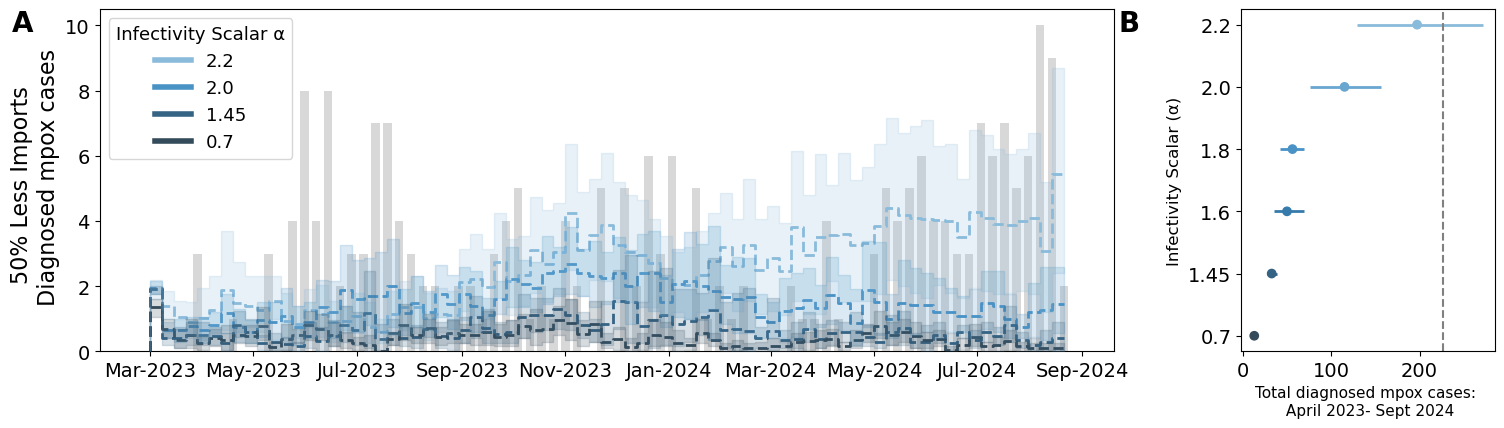

In [63]:
# Plotting α with phylo imports - this is the main figure 5 with the accompanying tornado plots
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()


modeling_half_df = merged_df_half.copy()
sexual_behavior_long = pd.melt(modeling_half_df, id_vars='week_date', value_vars=['Empirical'])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
modeling_half_df.week_date = pd.to_datetime(modeling_half_df.week_date)


#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax1.step(modeling_half_df.week_date, modeling_half_df["Mean_S6"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_half_df.week_date, modeling_half_df["LowerBound_S6"], modeling_half_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax1.step(modeling_half_df.week_date, modeling_half_df["Mean_S22"], color=blues[2],ls='--',lw=2 )
ax1.fill_between(modeling_half_df.week_date, modeling_half_df["LowerBound_S22"], modeling_half_df["UpperBound_S22"],alpha=0.2, step = "pre",  facecolor=blues[2],edgecolor=blues[2],zorder=1000)


# ax1.step(modeling_half_df.week_date, modeling_half_df["Mean_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_half_df.week_date, modeling_half_df["LowerBound_S21"], modeling_half_df["UpperBound_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


ax1.step(modeling_half_df.week_date, modeling_half_df["Mean_S20"], color=blues[4],ls='--',lw=2 )
ax1.fill_between(modeling_half_df.week_date, modeling_half_df["LowerBound_S20"], modeling_half_df["UpperBound_S20"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)


ax1.step(modeling_half_df.week_date, modeling_half_df["Mean_S12"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_half_df.week_date, modeling_half_df["LowerBound_S12"], modeling_half_df["UpperBound_S12"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

### add subplot for intervention

ax1_1 = fig.add_subplot(gs[0, 1])

blues = sns.color_palette("Blues_d").as_hex()

infection_scalar_cats = ["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df_half["Cum_Mean_S6"].iloc[-1], merged_df_half["Cum_Mean_S22"].iloc[-1], merged_df_half["Cum_Mean_S21"].iloc[-1], merged_df_half["Cum_Mean_S20"].iloc[-1] , merged_df_half["Cum_Mean_S12"].iloc[-1], merged_df_half["Cum_Mean_S13"].iloc[-1] ]
values_lb = [ merged_df_half["Cum_LowerBound_S6"].iloc[-1], merged_df_half["Cum_LowerBound_S22"].iloc[-1], merged_df_half["Cum_LowerBound_S21"].iloc[-1], merged_df_half["Cum_LowerBound_S20"].iloc[-1] , merged_df_half["Cum_LowerBound_S12"].iloc[-1], merged_df_half["Cum_LowerBound_S13"].iloc[-1] ]
values_ub = [ merged_df_half["Cum_UpperBound_S6"].iloc[-1], merged_df_half["Cum_UpperBound_S22"].iloc[-1], merged_df_half["Cum_UpperBound_S21"].iloc[-1], merged_df_half["Cum_UpperBound_S20"].iloc[-1] , merged_df_half["Cum_UpperBound_S12"].iloc[-1], merged_df_half["Cum_UpperBound_S13"].iloc[-1] ]
colors = [blues[0], blues[1], blues[2], blues[3],blues[4], blues[5]]

ax1_1.scatter( values, infection_scalar_cats, color = colors)

ax1_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

ax1_1.axvline(x=(merged_df_half["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax1_1.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

#ax1_1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='lower right')


ax1_1.tick_params(axis='both', which='major', labelsize=14)
ax1_1.tick_params(axis='both', which='minor', labelsize=14)
ax1_1.set_ylabel('Infectivity Scalar (α)', size = 12)
ax1_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)





##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
#ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('50% Less Imports \n Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')


#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  

# Show the plot
plt.tight_layout()
plt.savefig('../figures/microsim_half_imports.png',dpi=300,bbox_inches='tight')
plt.show()

## now let's explore what happens when we modify the number of vaccinated individuals

In [64]:
## all the microsimulation results with uncertainty intervals are in seperate folders and files. This function combines all those results
## into a single dataframe. Of note, this specific code snippet was created with help of ChatGPT and 
## edited by Miguel Paredes. The rest of this notebook was written by Miguel. 

# Define the parent folder containing the subfolders
parent_folder = "../data/MonteCarloResults/"

# Initialize an empty list to store the processed DataFrames
dataframes = []

# Loop through each subfolder in the parent folder
for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    # Check if the current path is a folder and matches the pattern "S0" to "S9"
    if (os.path.isdir(subfolder_path)) and (subfolder.find("Xvax") != -1):
        file_path = os.path.join(subfolder_path, "ToAware_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)
            # Rename columns to include the folder name
            folder_name =   subfolder.split("_")[-1]
            vax_name = subfolder.split("vax")[0]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}_{vax_name}",
                "UpperBound": f"UpperBound_{folder_name}_{vax_name}",
                "LowerBound": f"LowerBound_{folder_name}_{vax_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
            
    if os.path.isdir(subfolder_path) and (subfolder.find("Xvax") != -1):
        file_path = os.path.join(subfolder_path, "ToAwareCum_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[-1]
            vax_name = subfolder.split("vax")[0]

            df.rename(columns={
                "Mean": f"Cum_Mean_{folder_name}_{vax_name}",
                "UpperBound": f"Cum_UpperBound_{folder_name}_{vax_name}",
                "LowerBound": f"Cum_LowerBound_{folder_name}_{vax_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)

    

# Merge all DataFrames on the "Week" column
combined_df = dataframes[0]
for df in dataframes[1:]:
    combined_df = pd.merge(combined_df, df, on="Week")
    
empirical_df = pd.read_csv("../data/microsimulation_results/scenarios_aware.csv")

merged_df_vax = pd.merge(combined_df, empirical_df, left_on = "Week", right_on = "week" )
merged_df_vax.head()

,Week,Mean_S6_10X,LowerBound_S6_10X,UpperBound_S6_10X,Cum_Mean_S6_10X,Cum_LowerBound_S6_10X,Cum_UpperBound_S6_10X,Mean_S22_2X,LowerBound_S22_2X,UpperBound_S22_2X,...,To.Aware_S10,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19
0,0,0.0000,0.00,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,0
1,1,1.7518,1.50,2.00,1.7518,1.50,2.00,1.8433,1.65,2.00,...,2,1,2,2,2,2,2,2,2,2
2,2,1.6696,1.05,2.35,3.4214,2.95,3.90,0.8287,0.40,1.35,...,1,2,0,0,1,1,1,1,1,1
3,3,0.9660,0.50,1.40,4.3874,3.75,5.10,0.6465,0.20,1.05,...,2,1,0,0,1,1,1,0,2,1
4,4,1.5750,1.00,2.25,5.9624,4.95,7.05,0.8594,0.40,1.35,...,3,1,1,0,1,1,1,1,3,1


In [65]:
# format dates from the sims
start_date = datetime(2023, 3, 1)
merged_df_vax['week_date'] = merged_df_vax['week'].apply(lambda x: (start_date + timedelta(weeks=x)).strftime('%Y-%m-%d'))
merged_df_vax = merged_df_vax.dropna()
merged_df_vax.head()

,Week,Mean_S6_10X,LowerBound_S6_10X,UpperBound_S6_10X,Cum_Mean_S6_10X,Cum_LowerBound_S6_10X,Cum_UpperBound_S6_10X,Mean_S22_2X,LowerBound_S22_2X,UpperBound_S22_2X,...,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19,week_date
0,0,0.0000,0.00,0.00,0.0000,0.00,0.00,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,2023-03-01
1,1,1.7518,1.50,2.00,1.7518,1.50,2.00,1.8433,1.65,2.00,...,1,2,2,2,2,2,2,2,2,2023-03-08
2,2,1.6696,1.05,2.35,3.4214,2.95,3.90,0.8287,0.40,1.35,...,2,0,0,1,1,1,1,1,1,2023-03-15
3,3,0.9660,0.50,1.40,4.3874,3.75,5.10,0.6465,0.20,1.05,...,1,0,0,1,1,1,0,2,1,2023-03-22
4,4,1.5750,1.00,2.25,5.9624,4.95,7.05,0.8594,0.40,1.35,...,1,1,0,1,1,1,1,3,1,2023-03-29


/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/2037909771.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


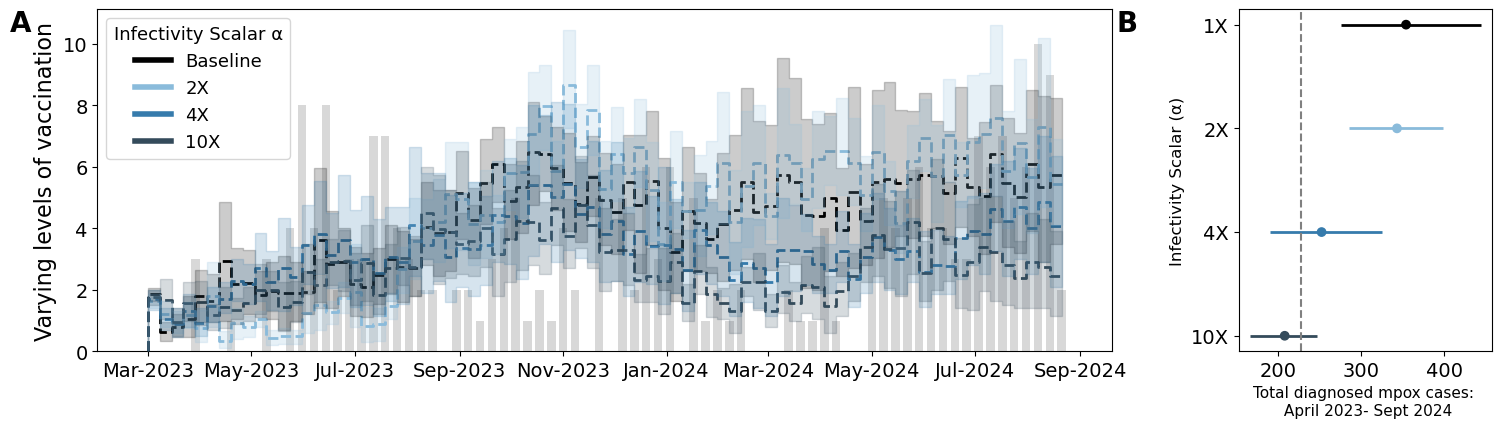

In [66]:
# Plotting α with phylo imports - this is the main figure 5 with the accompanying tornado plots
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()


modeling_vax_df = merged_df_vax.copy()
sexual_behavior_long = pd.melt(modeling_vax_df, id_vars='week_date', value_vars=['Empirical'])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
modeling_vax_df.week_date = pd.to_datetime(modeling_vax_df.week_date)


#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals

ax1.step(modeling_df.week_date, modeling_df["Mean_S6"], color="black",ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor="black",edgecolor="black",zorder=1000)


ax1.step(modeling_vax_df.week_date, modeling_vax_df["Mean_S6_2X"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_vax_df.week_date, modeling_vax_df["LowerBound_S6_2X"], modeling_vax_df["UpperBound_S6_2X"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax1.step(modeling_vax_df.week_date, modeling_vax_df["Mean_S6_4X"], color=blues[3],ls='--',lw=2 )
ax1.fill_between(modeling_vax_df.week_date, modeling_vax_df["LowerBound_S6_4X"], modeling_vax_df["UpperBound_S6_4X"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)

ax1.step(modeling_vax_df.week_date, modeling_vax_df["Mean_S6_10X"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_vax_df.week_date, modeling_vax_df["LowerBound_S6_10X"], modeling_vax_df["UpperBound_S6_10X"],alpha=0.2, step = "pre",  facecolor=blues[5],edgecolor=blues[5],zorder=1000)


legend_list = [mlines.Line2D([0], [0], color="black", lw=4, label='Baseline'),
               mlines.Line2D([0], [0], color=blues[0], lw=4, label='2X'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='4X'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='10X'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

### add subplot for intervention

ax1_1 = fig.add_subplot(gs[0, 1])

blues = sns.color_palette("Blues_d").as_hex()

infection_scalar_cats = ["1X", "2X", "4X", "10X"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df_vax["Cum_Mean_S6_2X"].iloc[-1], merged_df_vax["Cum_Mean_S6_4X"].iloc[-1], merged_df_vax["Cum_Mean_S6_10X"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df_vax["Cum_LowerBound_S6_2X"].iloc[-1], merged_df_vax["Cum_LowerBound_S6_4X"].iloc[-1], merged_df_vax["Cum_LowerBound_S6_10X"].iloc[-1] ]
values_ub = [ merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df_vax["Cum_UpperBound_S6_2X"].iloc[-1], merged_df_vax["Cum_UpperBound_S6_4X"].iloc[-1], merged_df_vax["Cum_UpperBound_S6_10X"].iloc[-1]  ]
colors = ["black", blues[0], blues[3], blues[5]]

ax1_1.scatter( values, infection_scalar_cats, color = colors)

ax1_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

ax1_1.axvline(x=(merged_df_vax["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax1_1.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

#ax1_1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='lower right')


ax1_1.tick_params(axis='both', which='major', labelsize=14)
ax1_1.tick_params(axis='both', which='minor', labelsize=14)
ax1_1.set_ylabel('Infectivity Scalar (α)', size = 12)
ax1_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)





##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
#ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('Varying levels of vaccination', size = 16)
ax1.set_xlabel('')


#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  

# Show the plot
plt.tight_layout()
#plt.savefig('../figures/microsim_half_imports.png',dpi=300,bbox_inches='tight')
plt.show()

## merging main figure 5 with 50% importation reductions

/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/1638683581.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/1638683581.py:267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


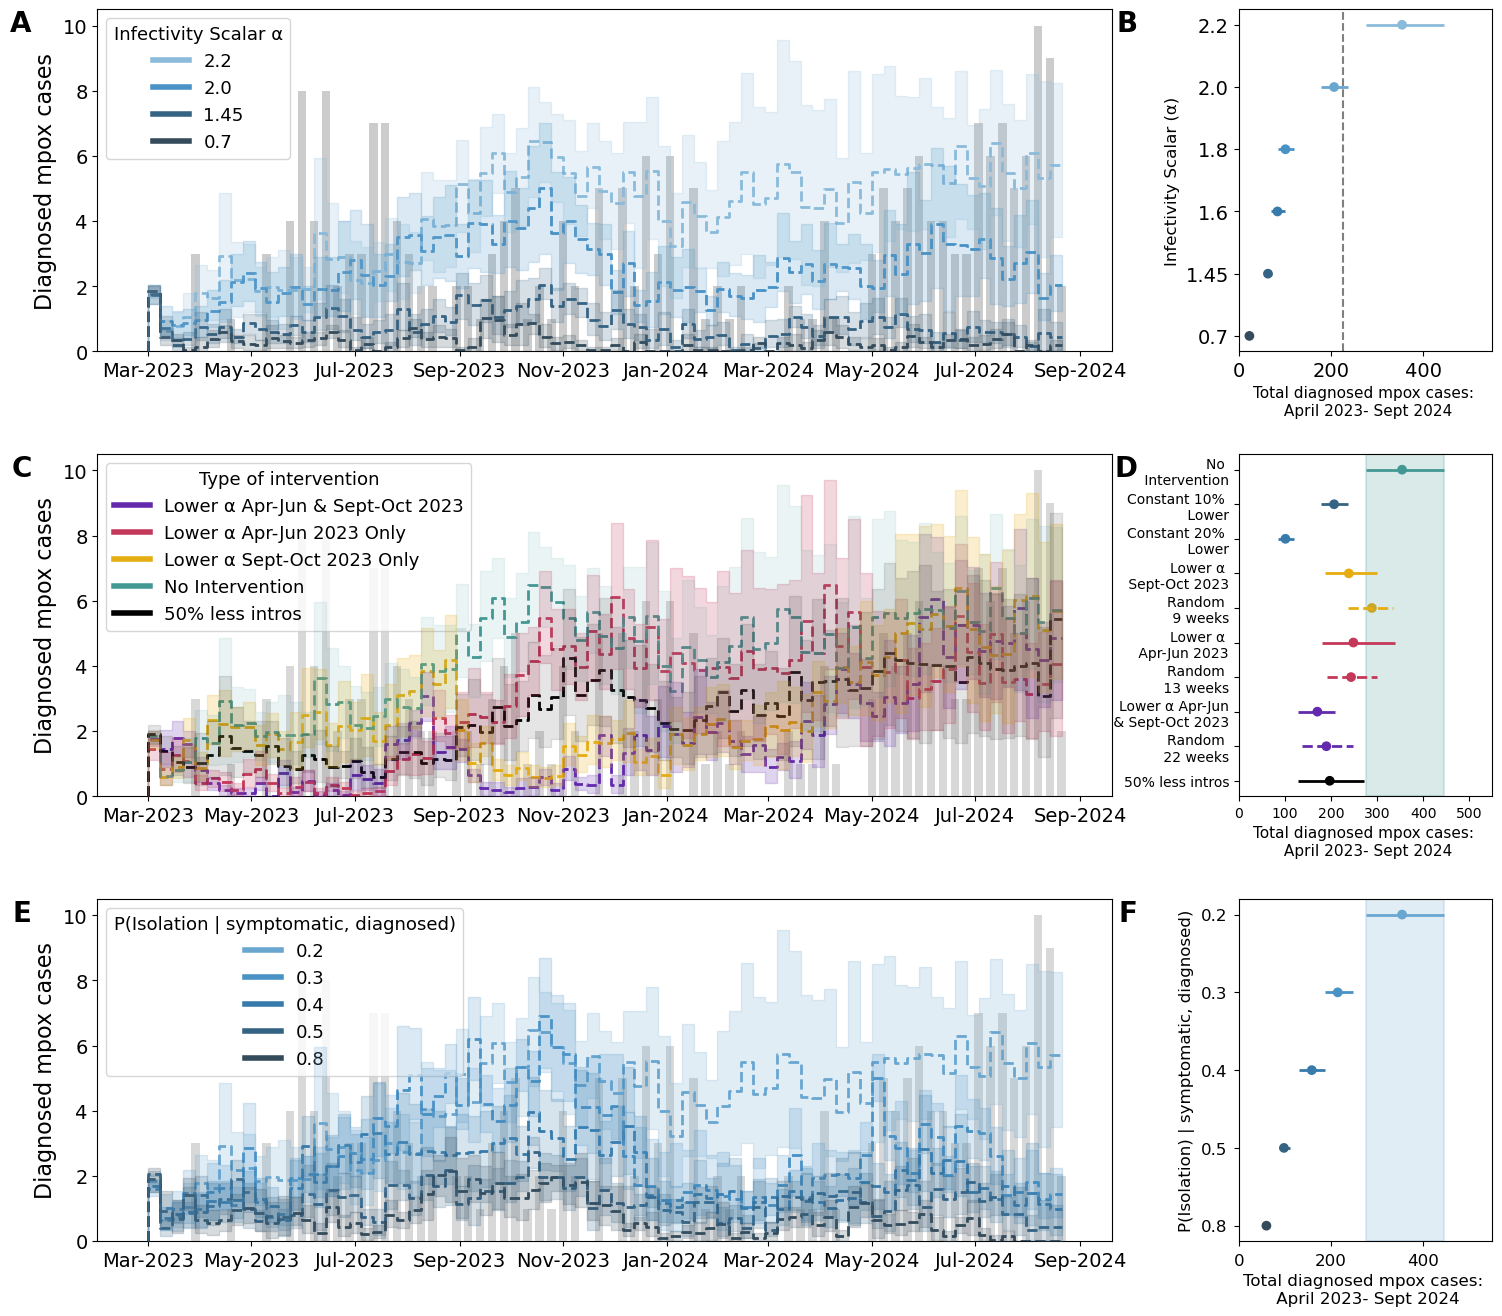

In [67]:
# Plotting α with phylo imports - this is the main figure 5 with the accompanying tornado plots
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()

sexual_behavior_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','Mean_S13', 'Mean_S12', 'Mean_S6','LowerBound_S13', 'LowerBound_S12', 'LowerBound_S6','UpperBound_S13', 'UpperBound_S12', 'UpperBound_S6', ])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
#modeling_df = merged_df.copy()
modeling_df.week_date = pd.to_datetime(modeling_df.week_date)
modeling_half_df = merged_df_half.copy()
modeling_half_df.week_date = pd.to_datetime(modeling_half_df.week_date)

#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.4, width = 5)

#plot estimates with uncertainty intervals
ax1.step(modeling_df.week_date, modeling_df["Mean_S6"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_S22"], color=blues[2],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S22"], modeling_df["UpperBound_S22"],alpha=0.2, step = "pre",  facecolor=blues[2],edgecolor=blues[2],zorder=1000)


# ax1.step(modeling_df.week_date, modeling_df["Mean_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S21"], modeling_df["UpperBound_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_S12"], color=blues[4],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S12"], modeling_df["UpperBound_S12"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_S13"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S13"], modeling_df["UpperBound_S13"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

### add subplot for intervention

ax1_1 = fig.add_subplot(gs[0, 1])

blues = sns.color_palette("Blues_d").as_hex()

infection_scalar_cats = ["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S22"].iloc[-1], merged_df["Cum_Mean_S21"].iloc[-1], merged_df["Cum_Mean_S20"].iloc[-1] , merged_df["Cum_Mean_S12"].iloc[-1], merged_df["Cum_Mean_S13"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S22"].iloc[-1], merged_df["Cum_LowerBound_S21"].iloc[-1], merged_df["Cum_LowerBound_S20"].iloc[-1] , merged_df["Cum_LowerBound_S12"].iloc[-1], merged_df["Cum_LowerBound_S13"].iloc[-1] ]
values_ub = [ merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S22"].iloc[-1], merged_df["Cum_UpperBound_S21"].iloc[-1], merged_df["Cum_UpperBound_S20"].iloc[-1] , merged_df["Cum_UpperBound_S12"].iloc[-1], merged_df["Cum_UpperBound_S13"].iloc[-1] ]
colors = [blues[0], blues[1], blues[2], blues[3],blues[4], blues[5]]

ax1_1.scatter( values, infection_scalar_cats, color = colors)

ax1_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

ax1_1.axvline(x=(merged_df["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax1_1.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

#ax1_1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='lower right')


ax1_1.tick_params(axis='both', which='major', labelsize=14)
ax1_1.tick_params(axis='both', which='minor', labelsize=14)
ax1_1.set_ylabel('Infectivity Scalar (α)', size = 12)
ax1_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)


####
# Add the second subplot for the potential public health interventions based on phylo results
####
ax2 = fig.add_subplot(gs[1, 0])

colors = sns.color_palette("CMRmap").as_hex()

PH_import_intervention_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S11', 'To.Aware_S15', 'To.Aware_S16','To.Aware_S17', 'To.Aware_S18', 'To.Aware_S19', 'To.Aware_S6'])
PH_import_intervention_long.week_date = pd.to_datetime(PH_import_intervention_long.week_date)
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"

#plot empirical cases
ax2.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_df.week_date, modeling_df["Mean_S11"], color=colors[1],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S11"], modeling_df["UpperBound_S11"],alpha=0.2, step = "pre", facecolor=colors[1],edgecolor=colors[1],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S15"], color=colors[2],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S15"], modeling_df["UpperBound_S15"],alpha=0.2, step = "pre", facecolor=colors[2],edgecolor=colors[2],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S16"], color=colors[4],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S16"], modeling_df["UpperBound_S16"],alpha=0.2, step = "pre", facecolor=colors[4],edgecolor=colors[4],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)

ax2.step(modeling_half_df.week_date, modeling_half_df["Mean_S6"], color="black",ls='--',lw=2 )
ax2.fill_between(modeling_half_df.week_date, modeling_half_df["LowerBound_S6"], modeling_half_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="black",edgecolor="black",zorder=1000)


#plot legend
legend_list = [mlines.Line2D([0], [0], color=colors[1], lw=4, label='Lower α Apr-Jun & Sept-Oct 2023'),
               mlines.Line2D([0], [0], color=colors[2], lw=4, label='Lower α Apr-Jun 2023 Only'),
               mlines.Line2D([0], [0], color=colors[4], lw=4, label='Lower α Sept-Oct 2023 Only'),
               mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),
               mlines.Line2D([0], [0], color="black", lw=4, label='50% less intros'),
              ]
ax2.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')

###
# add in overall dx cases subplot
###

ax2_1 = fig.add_subplot(gs[1, 1])


c_ramp = sns.color_palette("CMRmap").as_hex()

infection_scalar_cats = ["No \n Intervention", "Constant 10% \n Lower", "Constant 20% \n Lower",  "Lower α \n Sept-Oct 2023", "Random \n 9 weeks", "Lower α \n Apr-Jun 2023", "Random \n 13 weeks", "Lower α Apr-Jun\n & Sept-Oct 2023", "Random \n 22 weeks", "50% less intros"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S22"].iloc[-1], merged_df["Cum_Mean_S21"].iloc[-1], merged_df["Cum_Mean_S16"].iloc[-1], merged_df["Cum_Mean_S25"].iloc[-1], merged_df["Cum_Mean_S15"].iloc[-1], merged_df["Cum_Mean_S24"].iloc[-1] , merged_df["Cum_Mean_S11"].iloc[-1], merged_df["Cum_Mean_S23"].iloc[-1], merged_df_half["Cum_Mean_S6"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S22"].iloc[-1], merged_df["Cum_LowerBound_S21"].iloc[-1], merged_df["Cum_LowerBound_S16"].iloc[-1], merged_df["Cum_LowerBound_S25"].iloc[-1], merged_df["Cum_LowerBound_S15"].iloc[-1], merged_df["Cum_LowerBound_S24"].iloc[-1] , merged_df["Cum_LowerBound_S11"].iloc[-1], merged_df["Cum_LowerBound_S23"].iloc[-1], merged_df_half["Cum_LowerBound_S6"].iloc[-1] ]
values_ub = [merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S22"].iloc[-1], merged_df["Cum_UpperBound_S21"].iloc[-1], merged_df["Cum_UpperBound_S16"].iloc[-1], merged_df["Cum_UpperBound_S25"].iloc[-1], merged_df["Cum_UpperBound_S15"].iloc[-1], merged_df["Cum_UpperBound_S24"].iloc[-1] , merged_df["Cum_UpperBound_S11"].iloc[-1], merged_df["Cum_UpperBound_S23"].iloc[-1], merged_df_half["Cum_UpperBound_S6"].iloc[-1] ]
colors = ["#439894", blues[4], blues[3], c_ramp[4], c_ramp[4], c_ramp[2], c_ramp[2],c_ramp[1], c_ramp[1], "black"]
styles = ["solid", "solid","solid", "solid",  '--', "solid", '--', "solid", '--', "solid"]
ax2_1.scatter( values, infection_scalar_cats, color = colors)

ax2_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

#ax2_1.axvline(x=(merged_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

ax2_1.axvspan(merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S6"].iloc[-1], color="#439894", alpha = 0.2, linewidth=1.5)

ax2_1.invert_yaxis()
ax2_1.tick_params(axis='both', which='major', labelsize=10)
ax2_1.tick_params(axis='both', which='minor', labelsize=10)
ax2_1.set_ylabel('')
ax2_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)


###
# Add the third main plot regarding P(isolation | symptomatic, diagnosed)
###
ax3 = fig.add_subplot(gs[2, 0])

long_prop_iso_df = pd.melt(modeling_df, id_vars='week_date', value_vars=["Empirical", 'To.Aware_S6', 'To.Aware_S5', "To.Aware_S4", "To.Aware_S3", "To.Aware_S14"])
long_prop_iso_df.week_date = pd.to_datetime(long_prop_iso_df.week_date)

#plot empirical cases
ax3.bar(long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].week_date ,long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax3.step(modeling_df.week_date, modeling_df["Mean_S6"], color=blues[1],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre", facecolor=blues[1],edgecolor=blues[1],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S5"], color=blues[2],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S5"], modeling_df["UpperBound_S5"],alpha=0.2, step = "pre", facecolor=blues[2],edgecolor=blues[2],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S4"], color=blues[3],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S4"], modeling_df["UpperBound_S4"],alpha=0.20, step = "pre", facecolor=blues[3],edgecolor=blues[3],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S3"], color=blues[4],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S3"], modeling_df["UpperBound_S3"],alpha=0.20, step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)

ax3.step(modeling_df.week_date, modeling_df["Mean_S14"], color=blues[5],ls='--',lw=2 )
ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S14"], modeling_df["UpperBound_S14"],alpha=0.20, step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

## add legend
legend_list = [mlines.Line2D([0], [0], color=blues[1], lw=4, label='0.2'),
                mlines.Line2D([0], [0], color=blues[2], lw=4, label='0.3'),
                mlines.Line2D([0], [0], color=blues[3], lw=4, label='0.4'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='0.5'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.8'),]
ax3.legend(handles=legend_list, title='P(Isolation | symptomatic, diagnosed)', fontsize=13, title_fontsize=13, loc='upper left')

###
# add third subplot
###

ax3_1 = fig.add_subplot(gs[2, 1])

# define colors
blues = sns.color_palette("Blues_d").as_hex()

# definte data to plot
infection_scalar_cats = ["0.2", "0.3", "0.4", "0.5", "0.8"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S5"].iloc[-1], merged_df["Cum_Mean_S4"].iloc[-1], merged_df["Cum_Mean_S3"].iloc[-1] , merged_df["Cum_Mean_S14"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S5"].iloc[-1], merged_df["Cum_LowerBound_S4"].iloc[-1], merged_df["Cum_LowerBound_S3"].iloc[-1] , merged_df["Cum_LowerBound_S14"].iloc[-1] ]
values_ub = [ merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S5"].iloc[-1], merged_df["Cum_UpperBound_S4"].iloc[-1], merged_df["Cum_UpperBound_S3"].iloc[-1] , merged_df["Cum_UpperBound_S14"].iloc[-1]]
colors = [blues[1], blues[2], blues[3], blues[4],blues[5]]

# plot!
ax3_1.scatter( values, infection_scalar_cats, color = colors)

ax3_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

#ax3_1.axvline(x=(merged_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

ax3_1.axvspan(merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S6"].iloc[-1], color=blues[1], alpha = 0.2, linewidth=1.5)


ax3_1.invert_yaxis()
ax3_1.tick_params(axis='both', which='major', labelsize=12, pad =5)
ax3_1.tick_params(axis='both', which='minor', labelsize=12)
ax3_1.set_ylabel('P(Isolation) | symptomatic, diagnosed)', size = 12)
ax3_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 12)


##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_xlabel('')
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.tick_params(axis='both', which='minor', labelsize=14)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_xlabel('')
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3.text(-0.065, 1, "E", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3_1.text(-0.4, 1, "F", transform=ax3_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 

ax1_1.set_xlim(0, 550)
ax2_1.set_xlim(0, 550)
ax3_1.set_xlim(0, 550)


# Show the plot
plt.tight_layout()
plt.savefig('../figures/microsim_results_with_uncertainty_combined.png',dpi=300,bbox_inches='tight')
plt.show()

/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/3300084467.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/3300084467.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower α Apr-Jun & Sept-Oct 2023"
/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/3300084467.py:104: SettingWithCopyWarning: 
A value is trying to be 

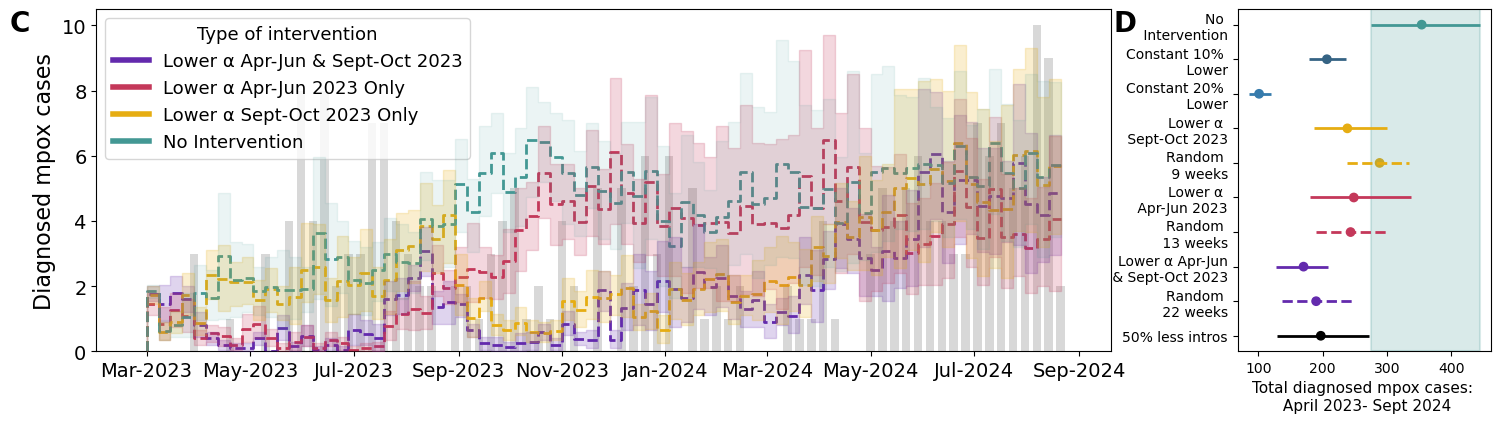

In [69]:
# Plotting α with phylo imports - this is the main figure 5 with the accompanying tornado plots
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# # Add the first subplot 
# ax1 = fig.add_subplot(gs[0, 0])

# blues = sns.color_palette("Blues_d").as_hex()

# sexual_behavior_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','Mean_S13', 'Mean_S12', 'Mean_S6','LowerBound_S13', 'LowerBound_S12', 'LowerBound_S6','UpperBound_S13', 'UpperBound_S12', 'UpperBound_S6', ])
# sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
# modeling_df.week_date = pd.to_datetime(modeling_df.week_date)

# #plot empirical cases
# ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

# #plot estimates with uncertainty intervals
# ax1.step(modeling_df.week_date, modeling_df["Mean_S6"], color=blues[5],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre",  facecolor=blues[5],edgecolor=blues[5],zorder=1000)


# ax1.step(modeling_df.week_date, modeling_df["Mean_S22"], color=blues[4],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S22"], modeling_df["UpperBound_S22"],alpha=0.2, step = "pre",  facecolor=blues[4],edgecolor=blues[4],zorder=1000)


# ax1.step(modeling_df.week_date, modeling_df["Mean_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S21"], modeling_df["UpperBound_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


# ax1.step(modeling_df.week_date, modeling_df["Mean_S20"], color=blues[1],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S20"], modeling_df["UpperBound_S20"],alpha=0.2,step = "pre", facecolor=blues[1],edgecolor=blues[1],zorder=1000)


# ax1.step(modeling_df.week_date, modeling_df["Mean_S12"], color=blues[2],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S12"], modeling_df["UpperBound_S12"],alpha=0.2,step = "pre", facecolor=blues[2],edgecolor=blues[2],zorder=1000)

# legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
#                mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
#                 mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.45'),
#                 mlines.Line2D([0], [0], color=blues[1], lw=4, label='0.7'),]

# ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

# ### add subplot for intervention

# ax1_1 = fig.add_subplot(gs[0, 1])

# blues = sns.color_palette("Blues_d").as_hex()

# infection_scalar_cats = ["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"]
# #infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

# values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S22"].iloc[-1], merged_df["Cum_Mean_S21"].iloc[-1], merged_df["Cum_Mean_S20"].iloc[-1] , merged_df["Cum_Mean_S12"].iloc[-1], merged_df["Cum_Mean_S13"].iloc[-1] ]
# values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S22"].iloc[-1], merged_df["Cum_LowerBound_S21"].iloc[-1], merged_df["Cum_LowerBound_S20"].iloc[-1] , merged_df["Cum_LowerBound_S12"].iloc[-1], merged_df["Cum_LowerBound_S13"].iloc[-1] ]
# values_ub = [ merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S22"].iloc[-1], merged_df["Cum_UpperBound_S21"].iloc[-1], merged_df["Cum_UpperBound_S20"].iloc[-1] , merged_df["Cum_UpperBound_S12"].iloc[-1], merged_df["Cum_UpperBound_S13"].iloc[-1] ]
# colors = [blues[5], blues[4], blues[3], blues[2],blues[1], blues[0]]

# ax1_1.scatter( values, infection_scalar_cats, color = colors)

# ax1_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

# ax1_1.axvline(x=(merged_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

# ax1_1.invert_yaxis()


# legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
#                mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
#                mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
#                 mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
#                 mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

# #ax1_1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='lower right')


# ax1_1.tick_params(axis='both', which='major', labelsize=14)
# ax1_1.tick_params(axis='both', which='minor', labelsize=14)
# ax1_1.set_ylabel('Infectivity Scalar (α)', size = 12)
# ax1_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)


####
# Add the second subplot for the potential public health interventions based on phylo results
####
ax2 = fig.add_subplot(gs[1, 0])

# modeling_df = modeling_df[modeling_df.week_date <"2024-01-01"]
# merged_df = merged_df[merged_df.week <44]
# merged_df_half = merged_df_half[merged_df_half.week <44]


colors = sns.color_palette("CMRmap").as_hex()

PH_import_intervention_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','To.Aware_S11', 'To.Aware_S15', 'To.Aware_S16','To.Aware_S17', 'To.Aware_S18', 'To.Aware_S19', 'To.Aware_S6'])
PH_import_intervention_long.week_date = pd.to_datetime(PH_import_intervention_long.week_date)

PH_import_intervention_long.variable[PH_import_intervention_long.variable == "Empirical"] = "Empirical"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S11"] = "Lower α Apr-Jun & Sept-Oct 2023"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S15"] = "Lower α Apr-Jun 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S16"] = "Lower α Sept-Oct 2023 Only"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S17"] = "Randomly Selected 22 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S18"] = "Randomly Selected 13 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S19"] = "Randomly Selected 9 weeks"
PH_import_intervention_long.variable[PH_import_intervention_long.variable == "To.Aware_S6"] = "No Intervention"


#plot empirical cases
ax2.bar(PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].week_date ,PH_import_intervention_long[PH_import_intervention_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_df.week_date, modeling_df["Mean_S11"], color=colors[1],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S11"], modeling_df["UpperBound_S11"],alpha=0.2, step = "pre", facecolor=colors[1],edgecolor=colors[1],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S15"], color=colors[2],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S15"], modeling_df["UpperBound_S15"],alpha=0.2, step = "pre", facecolor=colors[2],edgecolor=colors[2],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S16"], color=colors[4],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S16"], modeling_df["UpperBound_S16"],alpha=0.2, step = "pre", facecolor=colors[4],edgecolor=colors[4],zorder=1000)

ax2.step(modeling_df.week_date, modeling_df["Mean_S6"], color="#439894",ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.1, step = "pre", facecolor="#439894",edgecolor="#439894",zorder=1000)

#plot legend
legend_list = [mlines.Line2D([0], [0], color=colors[1], lw=4, label='Lower α Apr-Jun & Sept-Oct 2023'),
               mlines.Line2D([0], [0], color=colors[2], lw=4, label='Lower α Apr-Jun 2023 Only'),
               mlines.Line2D([0], [0], color=colors[4], lw=4, label='Lower α Sept-Oct 2023 Only'),
               mlines.Line2D([0], [0], color="#439894", lw=4, label='No Intervention'),]
ax2.legend(handles=legend_list, title='Type of intervention', fontsize=13, title_fontsize=13, loc='upper left')

###
# add in overall dx cases subplot
###

ax2_1 = fig.add_subplot(gs[1, 1])


c_ramp = sns.color_palette("CMRmap").as_hex()

infection_scalar_cats = ["No \n Intervention", "Constant 10% \n Lower", "Constant 20% \n Lower",  "Lower α \n Sept-Oct 2023", "Random \n 9 weeks", "Lower α \n Apr-Jun 2023", "Random \n 13 weeks", "Lower α Apr-Jun\n & Sept-Oct 2023", "Random \n 22 weeks", "50% less intros"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S22"].iloc[-1], merged_df["Cum_Mean_S21"].iloc[-1], merged_df["Cum_Mean_S16"].iloc[-1], merged_df["Cum_Mean_S25"].iloc[-1], merged_df["Cum_Mean_S15"].iloc[-1], merged_df["Cum_Mean_S24"].iloc[-1] , merged_df["Cum_Mean_S11"].iloc[-1], merged_df["Cum_Mean_S23"].iloc[-1], merged_df_half["Cum_Mean_S6"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S22"].iloc[-1], merged_df["Cum_LowerBound_S21"].iloc[-1], merged_df["Cum_LowerBound_S16"].iloc[-1], merged_df["Cum_LowerBound_S25"].iloc[-1], merged_df["Cum_LowerBound_S15"].iloc[-1], merged_df["Cum_LowerBound_S24"].iloc[-1] , merged_df["Cum_LowerBound_S11"].iloc[-1], merged_df["Cum_LowerBound_S23"].iloc[-1], merged_df_half["Cum_LowerBound_S6"].iloc[-1] ]
values_ub = [merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S22"].iloc[-1], merged_df["Cum_UpperBound_S21"].iloc[-1], merged_df["Cum_UpperBound_S16"].iloc[-1], merged_df["Cum_UpperBound_S25"].iloc[-1], merged_df["Cum_UpperBound_S15"].iloc[-1], merged_df["Cum_UpperBound_S24"].iloc[-1] , merged_df["Cum_UpperBound_S11"].iloc[-1], merged_df["Cum_UpperBound_S23"].iloc[-1], merged_df_half["Cum_UpperBound_S6"].iloc[-1] ]
colors = ["#439894", blues[4], blues[3], c_ramp[4], c_ramp[4], c_ramp[2], c_ramp[2],c_ramp[1], c_ramp[1], "black"]
styles = ["solid", "solid","solid", "solid",  '--', "solid", '--', "solid", '--', "solid"]
ax2_1.scatter( values, infection_scalar_cats, color = colors)

ax2_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

#ax2_1.axvline(x=(merged_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

ax2_1.axvspan(merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S6"].iloc[-1], color="#439894", alpha = 0.2, linewidth=1.5)

ax2_1.invert_yaxis()
ax2_1.tick_params(axis='both', which='major', labelsize=10)
ax2_1.tick_params(axis='both', which='minor', labelsize=10)
ax2_1.set_ylabel('')
ax2_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)


# ###
# # Add the third main plot regarding P(isolation | symptomatic, diagnosed)
# ###
# ax3 = fig.add_subplot(gs[2, 0])

# long_prop_iso_df = pd.melt(modeling_df, id_vars='week_date', value_vars=["Empirical", 'To.Aware_S6', 'To.Aware_S5', "To.Aware_S4", "To.Aware_S3", "To.Aware_S14"])
# long_prop_iso_df.week_date = pd.to_datetime(long_prop_iso_df.week_date)

# #plot empirical cases
# ax3.bar(long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].week_date ,long_prop_iso_df[long_prop_iso_df.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

# #plot estimates with uncertainty intervals
# ax3.step(modeling_df.week_date, modeling_df["Mean_S6"], color=blues[1],ls='--',lw=2 )
# ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S6"], modeling_df["UpperBound_S6"],alpha=0.2, step = "pre", facecolor=blues[1],edgecolor=blues[1],zorder=1000)

# ax3.step(modeling_df.week_date, modeling_df["Mean_S5"], color=blues[2],ls='--',lw=2 )
# ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S5"], modeling_df["UpperBound_S5"],alpha=0.2, step = "pre", facecolor=blues[2],edgecolor=blues[2],zorder=1000)

# ax3.step(modeling_df.week_date, modeling_df["Mean_S4"], color=blues[3],ls='--',lw=2 )
# ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S4"], modeling_df["UpperBound_S4"],alpha=0.20, step = "pre", facecolor=blues[3],edgecolor=blues[3],zorder=1000)

# ax3.step(modeling_df.week_date, modeling_df["Mean_S3"], color=blues[4],ls='--',lw=2 )
# ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S3"], modeling_df["UpperBound_S3"],alpha=0.20, step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)

# ax3.step(modeling_df.week_date, modeling_df["Mean_S14"], color=blues[5],ls='--',lw=2 )
# ax3.fill_between(modeling_df.week_date, modeling_df["LowerBound_S14"], modeling_df["UpperBound_S14"],alpha=0.20, step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

# ## add legend
# legend_list = [mlines.Line2D([0], [0], color=blues[1], lw=4, label='0.2'),
#                 mlines.Line2D([0], [0], color=blues[2], lw=4, label='0.3'),
#                 mlines.Line2D([0], [0], color=blues[3], lw=4, label='0.4'),
#                 mlines.Line2D([0], [0], color=blues[4], lw=4, label='0.5'),
#                 mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.8'),]
# ax3.legend(handles=legend_list, title='P(Isolation | symptomatic, diagnosed)', fontsize=13, title_fontsize=13, loc='upper left')

# ###
# # add third subplot
# ###

# ax3_1 = fig.add_subplot(gs[2, 1])

# # define colors
# blues = sns.color_palette("Blues_d").as_hex()

# # definte data to plot
# infection_scalar_cats = ["0.2", "0.3", "0.4", "0.5", "0.8"]

# values = [ merged_df["Cum_Mean_S6"].iloc[-1], merged_df["Cum_Mean_S5"].iloc[-1], merged_df["Cum_Mean_S4"].iloc[-1], merged_df["Cum_Mean_S3"].iloc[-1] , merged_df["Cum_Mean_S14"].iloc[-1] ]
# values_lb = [ merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_LowerBound_S5"].iloc[-1], merged_df["Cum_LowerBound_S4"].iloc[-1], merged_df["Cum_LowerBound_S3"].iloc[-1] , merged_df["Cum_LowerBound_S14"].iloc[-1] ]
# values_ub = [ merged_df["Cum_UpperBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S5"].iloc[-1], merged_df["Cum_UpperBound_S4"].iloc[-1], merged_df["Cum_UpperBound_S3"].iloc[-1] , merged_df["Cum_UpperBound_S14"].iloc[-1]]
# colors = [blues[1], blues[2], blues[3], blues[4],blues[5]]

# # plot!
# ax3_1.scatter( values, infection_scalar_cats, color = colors)

# ax3_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors,linestyle=styles,  linewidth=2)

# ax3_1.axvline(x=(merged_df["Empirical"].iloc[-1]), color='gray', linestyle='--', linewidth=1.5)

# ax3_1.axvspan(merged_df["Cum_LowerBound_S6"].iloc[-1], merged_df["Cum_UpperBound_S6"].iloc[-1], color=blues[1], alpha = 0.2, linewidth=1.5)


# ax3_1.invert_yaxis()
# ax3_1.tick_params(axis='both', which='major', labelsize=12, pad =5)
# ax3_1.tick_params(axis='both', which='minor', labelsize=12)
# ax3_1.set_ylabel('P(Isolation) | symptomatic, diagnosed)', size = 12)
# ax3_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 12)


##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
ax2.set_ylabel('Diagnosed mpox cases', size = 16)
ax2.set_xlabel('')
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.tick_params(axis='both', which='minor', labelsize=14)
ax3.set_ylabel('Diagnosed mpox cases', size = 16)
ax3.set_xlabel('')
#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3.text(-0.065, 1, "E", transform=ax3.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax3_1.text(-0.4, 1, "F", transform=ax3_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right') 

# Show the plot
plt.tight_layout()
#plt.savefig('../figures/microsim_results_with_uncertainty_combined.png',dpi=300,bbox_inches='tight')
plt.show()

## what happens if we assume complete return of sexual activity but no importations?

/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/2828049573.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


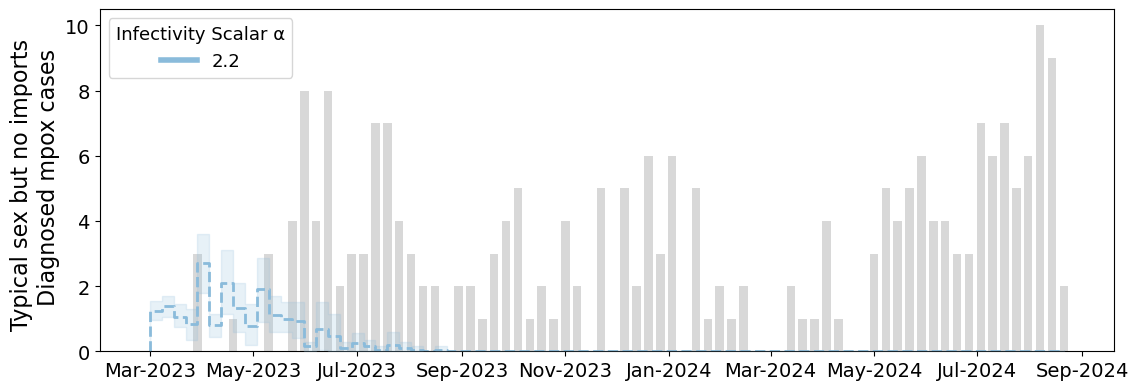

In [70]:
fig = plt.figure(figsize=(18,16),facecolor='w')

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()

sexual_behavior_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical','Mean_S13', 'Mean_S12', 'Mean_S6','LowerBound_S13', 'LowerBound_S12', 'LowerBound_S6','UpperBound_S13', 'UpperBound_S12', 'UpperBound_S6', ])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
modeling_df.week_date = pd.to_datetime(modeling_df.week_date)

#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax1.step(modeling_df.week_date, modeling_df["Mean_S26"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_S26"], modeling_df["UpperBound_S26"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('Typical sex but no imports \n Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../figures/typical_sex_no_imports.png',dpi=300,bbox_inches='tight')
plt.show()


### Supplementary figure for sensitivity analysis for Vaccine effectiveness. 

In [71]:
## all the microsimulation results with uncertainty intervals are in seperate folders and files. This function combines all those results
## into a single dataframe. Of note, this specific code snippet was created with help of ChatGPT and 
## edited by Miguel Paredes. The rest of this notebook was written by Miguel. 

# Define the parent folder containing the subfolders
parent_folder = "../data/MonteCarloResults/"

# Initialize an empty list to store the processed DataFrames
dataframes = []

# Loop through each subfolder in the parent folder
for subfolder in os.listdir(parent_folder):
    subfolder_path = os.path.join(parent_folder, subfolder)

    # Check if the current path is a folder and matches the pattern "S0" to "S9"
    if os.path.isdir(subfolder_path) and subfolder.startswith("ve0.25"):
        file_path = os.path.join(subfolder_path, "ToAware_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)
            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[0] + "_" +  subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}",
                "UpperBound": f"UpperBound_{folder_name}",
                "LowerBound": f"LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
    
    elif os.path.isdir(subfolder_path) and subfolder.startswith("ve0.75"):
        file_path = os.path.join(subfolder_path, "ToAware_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[0] + "_" +  subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Mean_{folder_name}",
                "UpperBound": f"UpperBound_{folder_name}",
                "LowerBound": f"LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
    if os.path.isdir(subfolder_path) and subfolder.startswith("ve0.25"):
        file_path = os.path.join(subfolder_path, "ToAwareCum_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[0] + "_" +  subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Cum_Mean_{folder_name}",
                "UpperBound": f"Cum_UpperBound_{folder_name}",
                "LowerBound": f"Cum_LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)
    if os.path.isdir(subfolder_path) and subfolder.startswith("ve0.75"):
        file_path = os.path.join(subfolder_path, "ToAwareCum_bs_results.csv")

        # Check if the target file exists in the subfolder
        if os.path.exists(file_path):
            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Rename columns to include the folder name
            folder_name = subfolder.split("_")[0]+ "_" +  subfolder.split("_")[-1]
            df.rename(columns={
                "Mean": f"Cum_Mean_{folder_name}",
                "UpperBound": f"Cum_UpperBound_{folder_name}",
                "LowerBound": f"Cum_LowerBound_{folder_name}"
            }, inplace=True)

            # Add the modified DataFrame to the list
            dataframes.append(df)

# Merge all DataFrames on the "Week" column
merged_df = dataframes[0]
for df in dataframes[1:]:
    merged_df = pd.merge(merged_df, df, on="Week")
    
empirical_df = pd.read_csv("../data/microsimulation_results/scenarios_aware.csv")

merged_df = pd.merge(merged_df, empirical_df, left_on = "Week", right_on = "week" )
merged_df.head()

,Week,Mean_ve0.25_S19,LowerBound_ve0.25_S19,UpperBound_ve0.25_S19,Cum_Mean_ve0.25_S19,Cum_LowerBound_ve0.25_S19,Cum_UpperBound_ve0.25_S19,Mean_ve0.25_S5,LowerBound_ve0.25_S5,UpperBound_ve0.25_S5,...,To.Aware_S10,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19
0,0,0.0000,0.00,0.00,0.0000,0.00,0.0,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,0
1,1,1.7443,1.55,1.90,1.7443,1.55,1.9,1.5966,1.35,1.80,...,2,1,2,2,2,2,2,2,2,2
2,2,0.5114,0.25,0.85,2.2557,2.00,2.5,1.1449,0.75,1.55,...,1,2,0,0,1,1,1,1,1,1
3,3,0.7592,0.40,1.20,3.0149,2.55,3.5,1.0032,0.65,1.35,...,2,1,0,0,1,1,1,0,2,1
4,4,0.5452,0.30,0.90,3.5601,2.95,4.1,1.6007,0.85,2.45,...,3,1,1,0,1,1,1,1,3,1


In [72]:
start_date = datetime(2023, 3, 1)
modeling_df = merged_df.copy()
modeling_df['week_date'] = modeling_df['Week'].apply(lambda x: (start_date + timedelta(weeks=x)).strftime('%Y-%m-%d'))
modeling_df = modeling_df.dropna()
modeling_df.head()

,Week,Mean_ve0.25_S19,LowerBound_ve0.25_S19,UpperBound_ve0.25_S19,Cum_Mean_ve0.25_S19,Cum_LowerBound_ve0.25_S19,Cum_UpperBound_ve0.25_S19,Mean_ve0.25_S5,LowerBound_ve0.25_S5,UpperBound_ve0.25_S5,...,To.Aware_S11,To.Aware_S12,To.Aware_S13,To.Aware_S14,To.Aware_S15,To.Aware_S16,To.Aware_S17,To.Aware_S18,To.Aware_S19,week_date
0,0,0.0000,0.00,0.00,0.0000,0.00,0.0,0.0000,0.00,0.00,...,0,0,0,0,0,0,0,0,0,2023-03-01
1,1,1.7443,1.55,1.90,1.7443,1.55,1.9,1.5966,1.35,1.80,...,1,2,2,2,2,2,2,2,2,2023-03-08
2,2,0.5114,0.25,0.85,2.2557,2.00,2.5,1.1449,0.75,1.55,...,2,0,0,1,1,1,1,1,1,2023-03-15
3,3,0.7592,0.40,1.20,3.0149,2.55,3.5,1.0032,0.65,1.35,...,1,0,0,1,1,1,0,2,1,2023-03-22
4,4,0.5452,0.30,0.90,3.5601,2.95,4.1,1.6007,0.85,2.45,...,1,1,0,1,1,1,1,3,1,2023-03-29


/var/folders/h9/0347drb57tsgxzbddmvmlvf80000gp/T/ipykernel_50301/2002546392.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


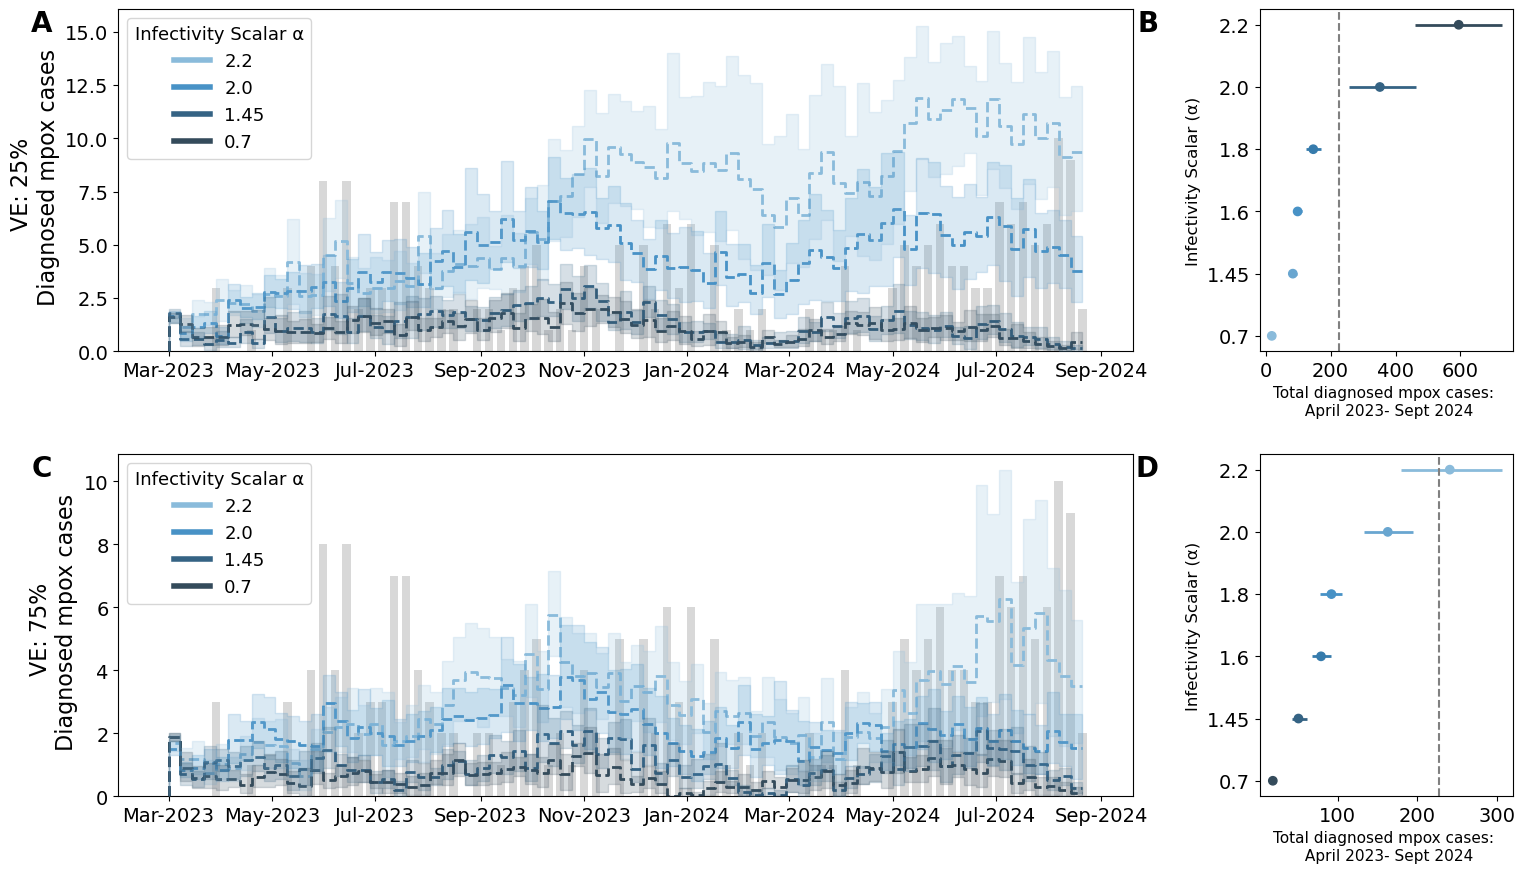

In [77]:
# Plotting α with phylo imports - this is the main figure 5 with the accompanying tornado plots
fig = plt.figure(figsize=(18,16),facecolor='w')


#gs = GridSpec(2, 2, height_ratios=[6, 1], width_ratios=[0.25, 1], hspace=0.1)  
gs = GridSpec(3, 2, width_ratios = [1, 0.25],  hspace=0.3)  # three rows, one column

# Add the first subplot 
ax1 = fig.add_subplot(gs[0, 0])

blues = sns.color_palette("Blues_d").as_hex()

sexual_behavior_long = pd.melt(modeling_df, id_vars='week_date', value_vars=['Empirical'])
sexual_behavior_long.week_date = pd.to_datetime(sexual_behavior_long.week_date)
modeling_df.week_date = pd.to_datetime(modeling_df.week_date)

#plot empirical cases
ax1.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax1.step(modeling_df.week_date, modeling_df["Mean_ve0.25_S6"], color=blues[0],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.25_S6"], modeling_df["UpperBound_ve0.25_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_ve0.25_S22"], color=blues[2],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.25_S22"], modeling_df["UpperBound_ve0.25_S22"],alpha=0.2, step = "pre",  facecolor=blues[2],edgecolor=blues[2],zorder=1000)


# ax1.step(modeling_df.week_date, modeling_df["Mean_ve0.25_S21"], color=blues[3],ls='--',lw=2 )
# ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.25_S21"], modeling_df["UpperBound_ve0.25_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_ve0.25_S20"], color=blues[4],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.25_S20"], modeling_df["UpperBound_ve0.25_S20"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)


ax1.step(modeling_df.week_date, modeling_df["Mean_ve0.25_S12"], color=blues[5],ls='--',lw=2 )
ax1.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.25_S12"], modeling_df["UpperBound_ve0.25_S12"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax1.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

### add subplot for intervention

ax1_1 = fig.add_subplot(gs[0, 1])

blues = sns.color_palette("Blues_d").as_hex()

infection_scalar_cats = ["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_ve0.25_S6"].iloc[-1], merged_df["Cum_Mean_ve0.25_S22"].iloc[-1], merged_df["Cum_Mean_ve0.25_S21"].iloc[-1], merged_df["Cum_Mean_ve0.25_S20"].iloc[-1] , merged_df["Cum_Mean_ve0.25_S12"].iloc[-1], merged_df["Cum_Mean_ve0.25_S13"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_ve0.25_S6"].iloc[-1], merged_df["Cum_LowerBound_ve0.25_S22"].iloc[-1], merged_df["Cum_LowerBound_ve0.25_S21"].iloc[-1], merged_df["Cum_LowerBound_ve0.25_S20"].iloc[-1] , merged_df["Cum_LowerBound_ve0.25_S12"].iloc[-1], merged_df["Cum_LowerBound_ve0.25_S13"].iloc[-1] ]
values_ub = [ merged_df["Cum_UpperBound_ve0.25_S6"].iloc[-1], merged_df["Cum_UpperBound_ve0.25_S22"].iloc[-1], merged_df["Cum_UpperBound_ve0.25_S21"].iloc[-1], merged_df["Cum_UpperBound_ve0.25_S20"].iloc[-1] , merged_df["Cum_UpperBound_ve0.25_S12"].iloc[-1], merged_df["Cum_UpperBound_ve0.25_S13"].iloc[-1] ]
colors = [blues[5], blues[4], blues[3], blues[2],blues[1], blues[0]]

ax1_1.scatter( values, infection_scalar_cats, color = colors)

ax1_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

ax1_1.axvline(x=(merged_df["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax1_1.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

#ax1_1.legend(handles=legend_list, title='Infectivity Scalar', fontsize=13, title_fontsize=13, loc='lower right')


ax1_1.tick_params(axis='both', which='major', labelsize=14)
ax1_1.tick_params(axis='both', which='minor', labelsize=14)
ax1_1.set_ylabel('Infectivity Scalar (α)', size = 12)
ax1_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)


####
# Add the second subplot for the potential public health interventions based on phylo results
####
ax2 = fig.add_subplot(gs[1, 0])

#plot empirical cases
ax2.bar(sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].week_date ,sexual_behavior_long[sexual_behavior_long.variable == "Empirical"].value, color = "gray", alpha = 0.3, width = 5)

#plot estimates with uncertainty intervals
ax2.step(modeling_df.week_date, modeling_df["Mean_ve0.75_S6"], color=blues[0],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.75_S6"], modeling_df["UpperBound_ve0.75_S6"],alpha=0.2, step = "pre",  facecolor=blues[0],edgecolor=blues[0],zorder=1000)


ax2.step(modeling_df.week_date, modeling_df["Mean_ve0.75_S22"], color=blues[2],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.75_S22"], modeling_df["UpperBound_ve0.75_S22"],alpha=0.2, step = "pre",  facecolor=blues[2],edgecolor=blues[2],zorder=1000)


# ax2.step(modeling_df.week_date, modeling_df["Mean_ve0.75_S21"], color=blues[3],ls='--',lw=2 )
# ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.75_S21"], modeling_df["UpperBound_ve0.75_S21"],alpha=0.2, step = "pre",  facecolor=blues[3],edgecolor=blues[3],zorder=1000)


ax2.step(modeling_df.week_date, modeling_df["Mean_ve0.75_S20"], color=blues[4],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.75_S20"], modeling_df["UpperBound_ve0.75_S20"],alpha=0.2,step = "pre", facecolor=blues[4],edgecolor=blues[4],zorder=1000)


ax2.step(modeling_df.week_date, modeling_df["Mean_ve0.75_S12"], color=blues[5],ls='--',lw=2 )
ax2.fill_between(modeling_df.week_date, modeling_df["LowerBound_ve0.75_S12"], modeling_df["UpperBound_ve0.75_S12"],alpha=0.2,step = "pre", facecolor=blues[5],edgecolor=blues[5],zorder=1000)

legend_list = [mlines.Line2D([0], [0], color=blues[0], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='2.0'),
#                mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
                mlines.Line2D([0], [0], color=blues[4], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[5], lw=4, label='0.7'),]

ax2.legend(handles=legend_list, title='Infectivity Scalar α', fontsize=13, title_fontsize=13, loc='upper left')

### add subplot for intervention

ax2_1 = fig.add_subplot(gs[1, 1])


blues = sns.color_palette("Blues_d").as_hex()

infection_scalar_cats = ["2.2", "2.0", "1.8", "1.6", "1.45", "0.7"]
#infection_scalar_cats = ["0.7", "1.45", "1.6", "1.8", "2.0", "2.2"]

values = [ merged_df["Cum_Mean_ve0.75_S6"].iloc[-1], merged_df["Cum_Mean_ve0.75_S22"].iloc[-1], merged_df["Cum_Mean_ve0.75_S21"].iloc[-1], merged_df["Cum_Mean_ve0.75_S20"].iloc[-1] , merged_df["Cum_Mean_ve0.75_S12"].iloc[-1], merged_df["Cum_Mean_ve0.75_S13"].iloc[-1] ]
values_lb = [ merged_df["Cum_LowerBound_ve0.75_S6"].iloc[-1], merged_df["Cum_LowerBound_ve0.75_S22"].iloc[-1], merged_df["Cum_LowerBound_ve0.75_S21"].iloc[-1], merged_df["Cum_LowerBound_ve0.75_S20"].iloc[-1] , merged_df["Cum_LowerBound_ve0.75_S12"].iloc[-1], merged_df["Cum_LowerBound_ve0.75_S13"].iloc[-1] ]
values_ub = [ merged_df["Cum_UpperBound_ve0.75_S6"].iloc[-1], merged_df["Cum_UpperBound_ve0.75_S22"].iloc[-1], merged_df["Cum_UpperBound_ve0.75_S21"].iloc[-1], merged_df["Cum_UpperBound_ve0.75_S20"].iloc[-1] , merged_df["Cum_UpperBound_ve0.75_S12"].iloc[-1], merged_df["Cum_UpperBound_ve0.75_S13"].iloc[-1] ]
colors = [blues[0], blues[1], blues[2], blues[3],blues[4], blues[5]]

ax2_1.scatter( values, infection_scalar_cats, color = colors)

ax2_1.hlines(infection_scalar_cats, xmin=values_lb, xmax=values_ub, color=colors, linewidth=2)

ax2_1.axvline(x=(merged_df["Empirical"].sum()), color='gray', linestyle='--', linewidth=1.5)

ax2_1.invert_yaxis()


legend_list = [mlines.Line2D([0], [0], color=blues[5], lw=4, label='2.2'),
               mlines.Line2D([0], [0], color=blues[4], lw=4, label='2.0'),
               mlines.Line2D([0], [0], color=blues[3], lw=4, label='1.8'),
               mlines.Line2D([0], [0], color=blues[2], lw=4, label='1.6'),
                mlines.Line2D([0], [0], color=blues[1], lw=4, label='1.45'),
                mlines.Line2D([0], [0], color=blues[0], lw=4, label='0.7'),]

ax2_1.tick_params(axis='both', which='major', labelsize=14)
ax2_1.tick_params(axis='both', which='minor', labelsize=14)
ax2_1.set_ylabel('Infectivity Scalar (α)', size = 12)
ax2_1.set_xlabel('Total diagnosed mpox cases: \n April 2023- Sept 2024', size = 11)



##### below is general formatting 

#format dates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
#ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# Set axis labels
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.tick_params(axis='both', which='minor', labelsize=14)
ax1.set_ylabel('VE: 25% \n Diagnosed mpox cases', size = 16)
ax1.set_xlabel('')
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.tick_params(axis='both', which='minor', labelsize=14)
ax2.set_ylabel('VE: 75% \n Diagnosed mpox cases', size = 16)
ax2.set_xlabel('')

#ax.set_ylim(0, 0.10)  # Y-axis limits

## add in letters for pub
ax1.text(-0.065, 1, "A", transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax1_1.text(-0.4, 1, "B", transform=ax1_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2.text(-0.065, 1, "C", transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  
ax2_1.text(-0.4, 1, "D", transform=ax2_1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')  

# Show the plot
plt.tight_layout()
plt.savefig('../figures/microsim_ve_sensitivity_analysis.png',dpi=300,bbox_inches='tight')
plt.show()